# ============================================================================
# RED DE FOTÓGRAFOS CON NIVELES TRÓFICOS - PLOTLY
# ============================================================================
## Agregados en fechas

/var/folders/q5/x7crwjdj4dn7r73t91hrny6w0000gn/T/ipykernel_10842/3995644143.py:13: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd



RED DE FOTÓGRAFOS CON NIVELES TRÓFICOS - PLOTLY

✓ Datos cargados:
  - Fotógrafos: 300
  - Relaciones: 484

✓ Niveles tróficos calculados:
  - Fotógrafos pioneros (nivel 1): 37
  - Rango de niveles: 1.0 - 29.0
  - Distribución:
    Nivel 1.0: 37 fotógrafos
    Nivel 2.0: 33 fotógrafos
    Nivel 3.0: 68 fotógrafos
    Nivel 4.0: 65 fotógrafos
    Nivel 5.0: 22 fotógrafos
    Nivel 6.0: 28 fotógrafos
    Nivel 7.0: 12 fotógrafos
    Nivel 8.0: 4 fotógrafos
    Nivel 9.0: 2 fotógrafos
    Nivel 10.0: 3 fotógrafos
    Nivel 11.0: 2 fotógrafos
    Nivel 12.0: 2 fotógrafos
    Nivel 13.0: 2 fotógrafos
    Nivel 14.0: 2 fotógrafos
    Nivel 15.0: 2 fotógrafos
    Nivel 16.0: 1 fotógrafos
    Nivel 17.0: 1 fotógrafos
    Nivel 18.0: 1 fotógrafos
    Nivel 19.0: 1 fotógrafos
    Nivel 20.0: 1 fotógrafos
    Nivel 21.0: 1 fotógrafos
    Nivel 22.0: 1 fotógrafos
    Nivel 23.0: 1 fotógrafos
    Nivel 24.0: 1 fotógrafos
    Nivel 25.0: 1 fotógrafos
    Nivel 26.0: 2 fotógrafos
    Nivel 27.0: 2 f

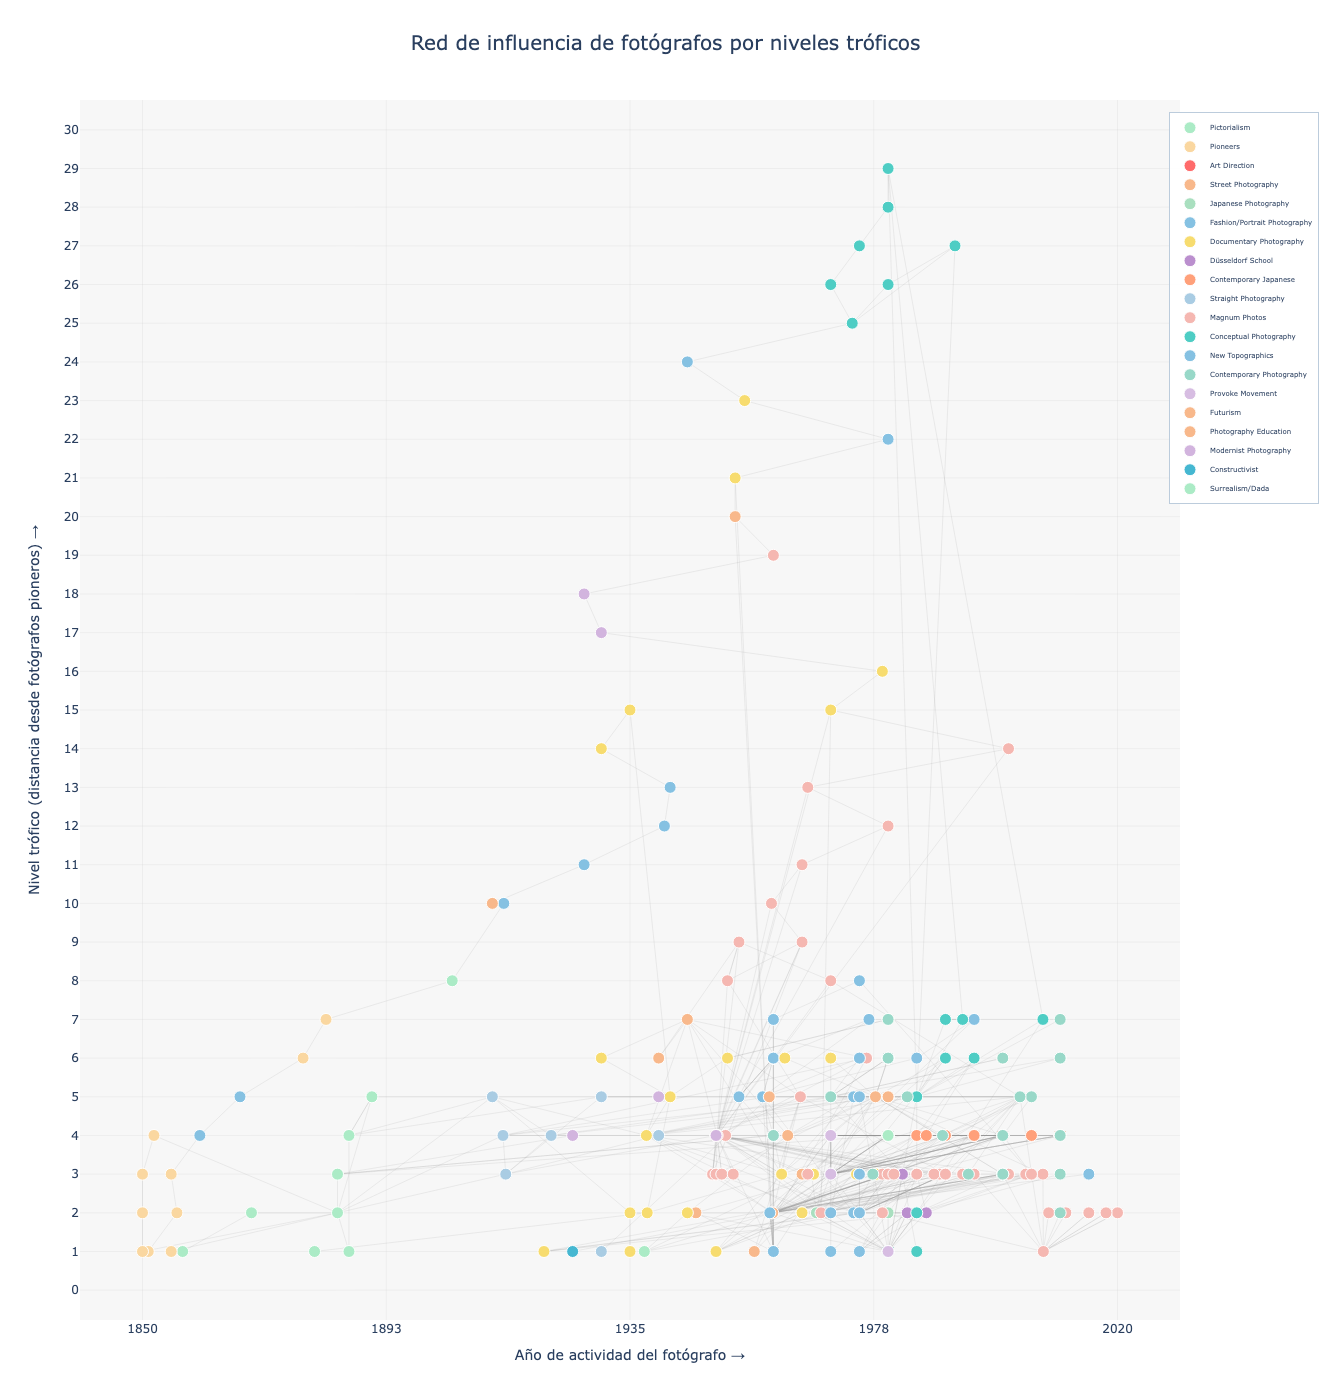

In [1]:
# ============================================================================
# RED DE FOTÓGRAFOS CON NIVELES TRÓFICOS - PLOTLY
# ============================================================================
# Script para generar una gráfica interactiva Plotly mostrando niveles tróficos
# 
# Características:
# - X: Año de actividad del fotógrafo
# - Y: Nivel trófico (distancia desde pioneros)
# - Color: Movimiento fotográfico
# - Interactivo: Zoom, pan, hover, leyenda clickeable
# ============================================================================

import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import numpy as np
from collections import defaultdict

# ============================================================================
# CONFIGURACIÓN
# ============================================================================

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
TAMAÑO_NODO = 12
ANCHO_LINEA = 0.5
OPACIDAD_LINEA = 0.3

COLORES_BASE = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
    '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A9DFBF',
    '#F5B7B1', '#D2B4DE', '#85C1E2', '#F8B88B', '#ABEBC6',
    '#FAD7A0', '#D7BDE2', '#A9CCE3', '#F8B88B', '#ABEBC6',
    '#FADBD8', '#EBDEF0', '#D6EAF8', '#FCF3CF', '#EAFAF1',
    '#FDEBD0', '#EDBB99', '#D4EFDF', '#A3E4D7', '#F9E79F',
    '#F4D03F', '#D5DBDB', '#BDC3C7', '#95A5A6', '#7F8C8D',
]


# ============================================================================
# FUNCIÓN: Cargar datos y crear grafo
# ============================================================================

def cargar_y_crear_grafo(archivo_csv):
    """Carga el CSV y crea un grafo dirigido."""
    df = pd.read_csv(archivo_csv)
    
    G = nx.DiGraph()
    
    fotógrafos = set(df['Influenciador'].unique()) | set(df['Influenciado'].unique())
    for fotógrafo in fotógrafos:
        G.add_node(fotógrafo)
    
    for idx, row in df.iterrows():
        G.add_edge(row['Influenciador'], row['Influenciado'])
    
    print(f"✓ Datos cargados:")
    print(f"  - Fotógrafos: {G.number_of_nodes()}")
    print(f"  - Relaciones: {G.number_of_edges()}")
    
    return df, G


# ============================================================================
# FUNCIÓN: Calcular niveles tróficos
# ============================================================================

def calcular_niveles_troficos(G):
    """
    Calcula el nivel trófico de cada nodo basándose en la distancia
    desde nodos fuente (fotógrafos pioneros sin influenciadores).
    
    Nivel trófico 1: Fotógrafos pioneros
    Nivel trófico n: Fotógrafos influenciados por nivel trófico n-1
    """
    
    # Encontrar nodos fuente (sin aristas entrantes)
    nodos_fuente = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    nivel_trofico = {}
    
    # Inicializar fuentes
    for fuente in nodos_fuente:
        nivel_trofico[fuente] = 1.0
    
    # BFS desde cada fuente
    for fuente in nodos_fuente:
        visited = {fuente: 1.0}
        queue = [(fuente, 1.0)]
        
        while queue:
            nodo, nivel = queue.pop(0)
            
            for sucesor in G.successors(nodo):
                nuevo_nivel = nivel + 1.0
                
                if sucesor in visited:
                    nivel_trofico[sucesor] = max(nivel_trofico[sucesor], nuevo_nivel)
                    visited[sucesor] = max(visited[sucesor], nuevo_nivel)
                else:
                    nivel_trofico[sucesor] = nuevo_nivel
                    visited[sucesor] = nuevo_nivel
                    queue.append((sucesor, nuevo_nivel))
    
    # Para nodos no visitados (componentes aisladas)
    for nodo in G.nodes():
        if nodo not in nivel_trofico:
            influenciadores = list(G.predecessors(nodo))
            if influenciadores:
                nivel_trofico[nodo] = 1 + np.mean([nivel_trofico.get(inf, 1) for inf in influenciadores])
            else:
                nivel_trofico[nodo] = 1.0
    
    print(f"\n✓ Niveles tróficos calculados:")
    print(f"  - Fotógrafos pioneros (nivel 1): {len(nodos_fuente)}")
    print(f"  - Rango de niveles: {min(nivel_trofico.values()):.1f} - {max(nivel_trofico.values()):.1f}")
    
    # Mostrar distribución
    conteo_por_nivel = defaultdict(int)
    for nivel in nivel_trofico.values():
        nivel_redondeado = round(nivel, 1)
        conteo_por_nivel[nivel_redondeado] += 1
    
    print(f"  - Distribución:")
    for nivel in sorted(conteo_por_nivel.keys()):
        print(f"    Nivel {nivel}: {conteo_por_nivel[nivel]} fotógrafos")
    
    return nivel_trofico, nodos_fuente


# ============================================================================
# FUNCIÓN: Calcular posiciones 2D
# ============================================================================

def calcular_posiciones(G, df, nivel_trofico):
    """
    Calcula posiciones X,Y para cada nodo:
    - X: Año de actividad normalizado
    - Y: Nivel trófico
    """
    
    posiciones = {}
    
    for fotógrafo in G.nodes():
        # Obtener año promedio
        años = []
        if (df['Influenciador'] == fotógrafo).any():
            años.extend(df[df['Influenciador'] == fotógrafo]['Año_Influenciador'].values)
        if (df['Influenciado'] == fotógrafo).any():
            años.extend(df[df['Influenciado'] == fotógrafo]['Año_Influenciado'].values)
        
        año_promedio = np.mean(años) if años else 1950
        
        # Normalizar año a [0, 1]
        año_norm = (año_promedio - 1850) / (2020 - 1850)
        año_norm = np.clip(año_norm, 0, 1)
        
        # Y es el nivel trófico
        y = nivel_trofico[fotógrafo]
        
        posiciones[fotógrafo] = (año_norm, y)
    
    print(f"\n✓ Posiciones calculadas para {len(posiciones)} nodos")
    
    return posiciones


# ============================================================================
# FUNCIÓN: Preparar datos para Plotly
# ============================================================================

def preparar_datos_plotly(G, df, posiciones, nivel_trofico):
    """Prepara aristas y nodos para visualización en Plotly."""
    
    # Aristas
    edge_x = []
    edge_y = []
    
    for origen, destino in G.edges():
        x0, y0 = posiciones[origen]
        x1, y1 = posiciones[destino]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
    
    # Nodos agrupados por movimiento
    nodos_por_movimiento = defaultdict(list)
    
    for fotógrafo in G.nodes():
        movimientos = set()
        
        if (df['Influenciador'] == fotógrafo).any():
            movimientos.update(df[df['Influenciador'] == fotógrafo]['Movimiento_Influenciador'].unique())
        if (df['Influenciado'] == fotógrafo).any():
            movimientos.update(df[df['Influenciado'] == fotógrafo]['Movimiento_Influenciado'].unique())
        
        movimiento_principal = sorted(list(movimientos))[0] if movimientos else 'Sin clasificar'
        nodos_por_movimiento[movimiento_principal].append(fotógrafo)
    
    # Colores
    color_map = {}
    for i, movimiento in enumerate(sorted(nodos_por_movimiento.keys())):
        color_map[movimiento] = COLORES_BASE[i % len(COLORES_BASE)]
    
    print(f"\n✓ Datos preparados:")
    print(f"  - Aristas (líneas): {len(G.edges())}")
    print(f"  - Nodos (puntos): {len(G.nodes())}")
    print(f"  - Movimientos (grupos): {len(color_map)}")
    
    return edge_x, edge_y, nodos_por_movimiento, color_map


# ============================================================================
# FUNCIÓN: Crear figura Plotly
# ============================================================================

def crear_figura(G, df, edge_x, edge_y, nodos_por_movimiento, posiciones, 
                 nivel_trofico, color_map):
    """Crea la figura interactiva con Plotly."""
    
    fig = go.Figure()
    
    # Agregar aristas
    fig.add_trace(go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        name='Influencias',
        line=dict(width=ANCHO_LINEA, color=f'rgba(150,150,150,{OPACIDAD_LINEA})'),
        hoverinfo='skip',
        showlegend=False,
    ))
    
    # Agregar nodos
    for movimiento, fotógrafos_list in nodos_por_movimiento.items():
        x_coords = [posiciones[f][0] for f in fotógrafos_list]
        y_coords = [posiciones[f][1] for f in fotógrafos_list]
        
        hover_texts = []
        for fotógrafo in fotógrafos_list:
            nivel = nivel_trofico[fotógrafo]
            out_edges = G.out_degree(fotógrafo)
            in_edges = G.in_degree(fotógrafo)
            
            hover_text = (f"<b>{fotógrafo}</b><br>"
                         f"Movimiento: {movimiento}<br>"
                         f"Nivel trófico: {nivel:.1f}<br>"
                         f"Influenciados: {out_edges}<br>"
                         f"Influenciadores: {in_edges}")
            hover_texts.append(hover_text)
        
        fig.add_trace(go.Scatter(
            x=x_coords, y=y_coords,
            mode='markers',
            name=movimiento,
            marker=dict(
                size=TAMAÑO_NODO,
                color=color_map[movimiento],
                line=dict(width=1, color='white'),
            ),
            text=hover_texts,
            hoverinfo='text',
            showlegend=True,
        ))
    
    return fig


# ============================================================================
# FUNCIÓN: Configurar layout
# ============================================================================

def configurar_layout(fig):
    """Configura el layout y ejes de la figura."""
    
    fig.update_layout(
        title={
            'text': 'Red de influencia de fotógrafos por niveles tróficos',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        xaxis=dict(
            title='Año de actividad del fotógrafo →',
            showgrid=True,
            zeroline=False,
            tickvals=[0, 0.25, 0.5, 0.75, 1],
            ticktext=['1850', '1893', '1935', '1978', '2020'],
            gridwidth=1,
            gridcolor='rgba(200,200,200,0.2)'
        ),
        yaxis=dict(
            title='Nivel trófico (distancia desde fotógrafos pioneros) →',
            showgrid=True,
            zeroline=False,
            dtick=1,
            gridwidth=1,
            gridcolor='rgba(200,200,200,0.2)'
        ),
        hovermode='closest',
        margin=dict(b=80, l=80, r=20, t=100),
        plot_bgcolor='rgba(240,240,240,0.5)',
        height=1400,   # ← AUMENTAR de 900 a 1400
        width=2000,    # ← AUMENTAR de 1400 a 2000

        legend=dict(
            orientation='v',
            yanchor='top',
            y=0.99,
            xanchor='left',
            x=0.99,
            bgcolor='rgba(255,255,255,0.95)',
            bordercolor='#BCCCDC',
            borderwidth=1,
            font=dict(size=7)
        )
    )


# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def main():
    """Ejecuta el proceso completo."""
    
    print("\n" + "="*70)
    print("RED DE FOTÓGRAFOS CON NIVELES TRÓFICOS - PLOTLY")
    print("="*70 + "\n")
    
    # Paso 1: Cargar datos
    df, G = cargar_y_crear_grafo(ARCHIVO_CSV)
    
    # Paso 2: Calcular niveles tróficos
    nivel_trofico, nodos_fuente = calcular_niveles_troficos(G)
    
    # Paso 3: Calcular posiciones
    posiciones = calcular_posiciones(G, df, nivel_trofico)
    
    # Paso 4: Preparar datos
    edge_x, edge_y, nodos_por_movimiento, color_map = preparar_datos_plotly(
        G, df, posiciones, nivel_trofico
    )
    
    # Paso 5: Crear figura
    fig = crear_figura(G, df, edge_x, edge_y, nodos_por_movimiento, 
                       posiciones, nivel_trofico, color_map)
    
    # Paso 6: Configurar layout
    configurar_layout(fig)
    
    print(f"\n" + "="*70)
    print("✓ GRÁFICA LISTA PARA MOSTRAR")
    print("="*70 + "\n")
    print("Mostrando figura interactiva...\n")
    
    # Mostrar
    fig.show()
    
    # Retornar figura para uso posterior
    fig.write_html('red_fotografos_niveles_troficos.html')
    return fig
    


# ============================================================================
# PUNTO DE ENTRADA
# ============================================================================

if __name__ == '__main__':
    fig = main()

## Algoritmo de Javi


RED DE FOTÓGRAFOS CON NIVELES TRÓFICOS - PLOTLY

✓ Datos cargados:
  - Fotógrafos: 300
  - Relaciones: 484

✓ Niveles tróficos calculados iterativamente:
  - Fotógrafos pioneros (nivel 1): 37
  - Rango de niveles: 1.0 - 16.0
  - Distribución:
    Nivel 1.0: 37 fotógrafos
    Nivel 2.0: 25 fotógrafos
    Nivel 2.2: 1 fotógrafos
    Nivel 2.3: 2 fotógrafos
    Nivel 2.4: 1 fotógrafos
    Nivel 2.5: 2 fotógrafos
    Nivel 2.8: 1 fotógrafos
    Nivel 3.0: 26 fotógrafos
    Nivel 3.1: 2 fotógrafos
    Nivel 3.2: 3 fotógrafos
    Nivel 3.3: 5 fotógrafos
    Nivel 3.4: 5 fotógrafos
    Nivel 3.5: 4 fotógrafos
    Nivel 3.6: 4 fotógrafos
    Nivel 3.7: 3 fotógrafos
    Nivel 3.8: 8 fotógrafos
    Nivel 3.9: 3 fotógrafos
    Nivel 4.0: 20 fotógrafos
    Nivel 4.1: 3 fotógrafos
    Nivel 4.2: 7 fotógrafos
    Nivel 4.3: 26 fotógrafos
    Nivel 4.4: 2 fotógrafos
    Nivel 4.5: 6 fotógrafos
    Nivel 4.6: 4 fotógrafos
    Nivel 4.7: 8 fotógrafos
    Nivel 4.8: 5 fotógrafos
    Nivel 4.9: 5 fotógr

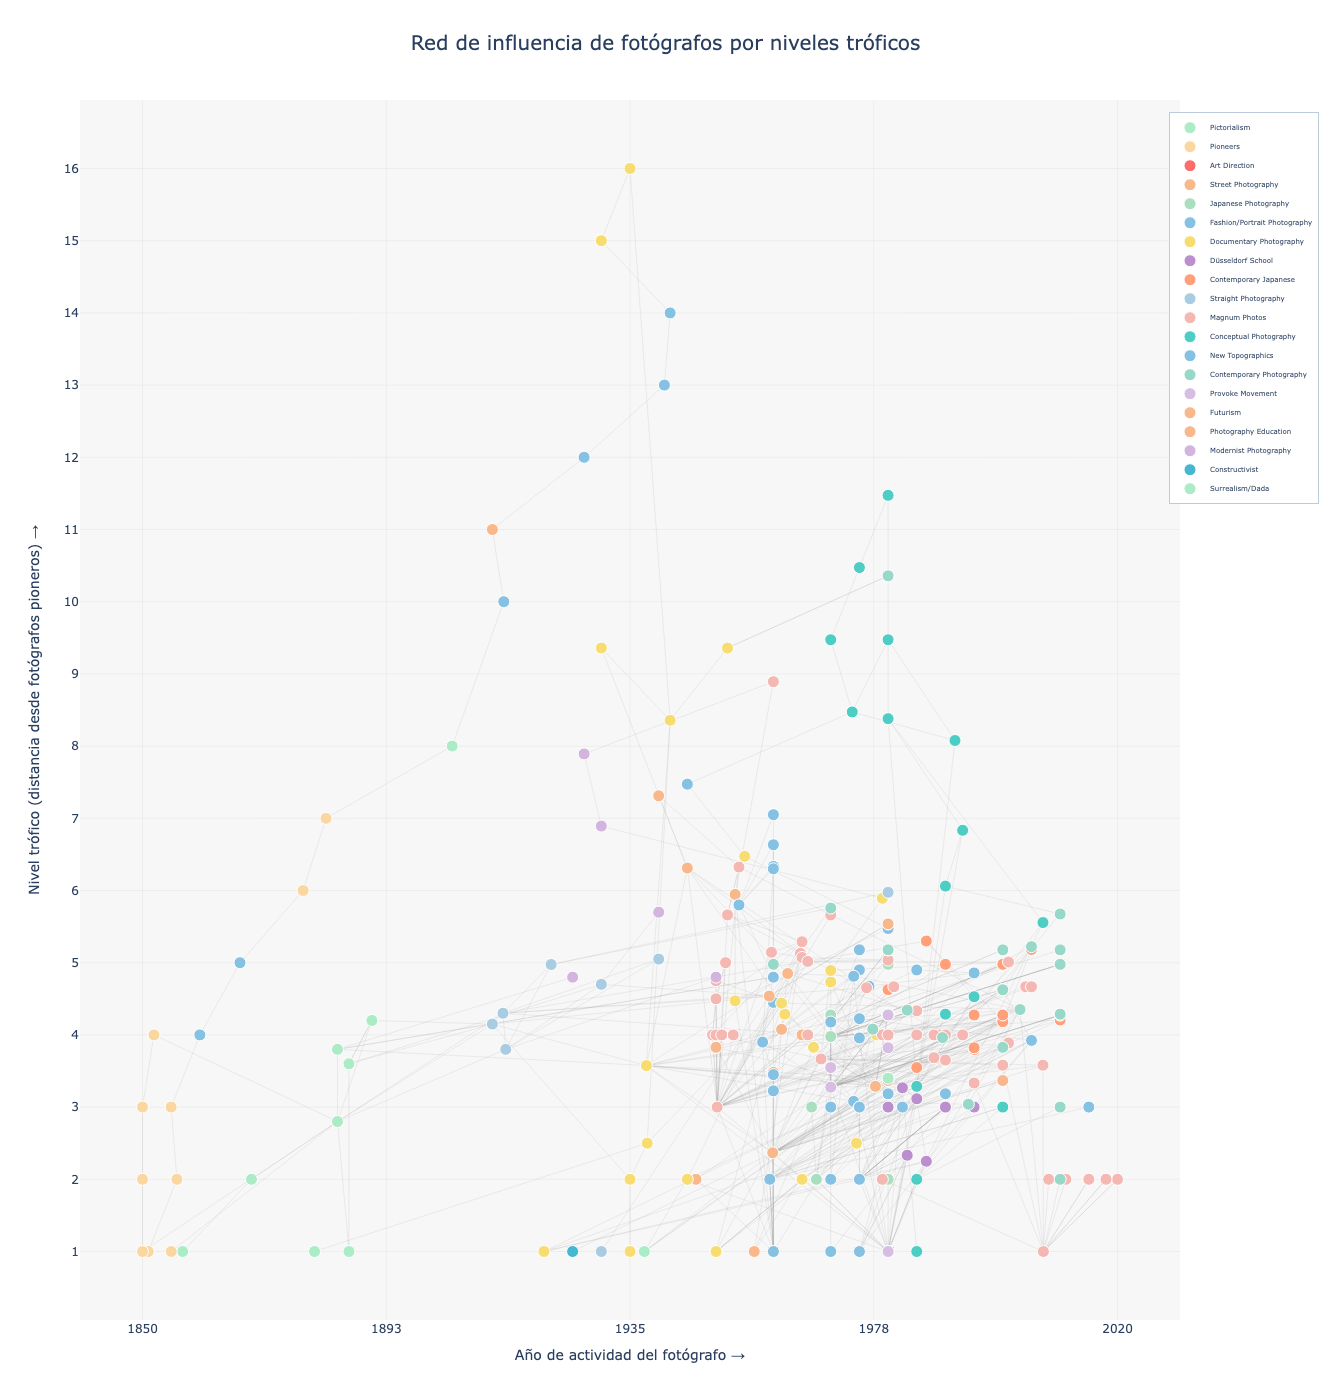

In [2]:
import pandas as pd
import networkx as nx
import plotly.graph_objects as go
import numpy as np
from collections import defaultdict

# ============================================================================
# CONFIGURACIÓN
# ============================================================================

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
TAMAÑO_NODO = 12
ANCHO_LINEA = 0.5
OPACIDAD_LINEA = 0.3

COLORES_BASE = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
    '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A9DFBF',
    '#F5B7B1', '#D2B4DE', '#85C1E2', '#F8B88B', '#ABEBC6',
    '#FAD7A0', '#D7BDE2', '#A9CCE3', '#F8B88B', '#ABEBC6',
    '#FADBD8', '#EBDEF0', '#D6EAF8', '#FCF3CF', '#EAFAF1',
    '#FDEBD0', '#EDBB99', '#D4EFDF', '#A3E4D7', '#F9E79F',
    '#F4D03F', '#D5DBDB', '#BDC3C7', '#95A5A6', '#7F8C8D',
]

# ============================================================================
# FUNCIÓN: Cargar datos y crear grafo
# ============================================================================

def cargar_y_crear_grafo(archivo_csv):
    """Carga el CSV y crea un grafo dirigido."""
    df = pd.read_csv(archivo_csv)
    
    G = nx.DiGraph()
    
    fotógrafos = set(df['Influenciador'].unique()) | set(df['Influenciado'].unique())
    for fotógrafo in fotógrafos:
        G.add_node(fotógrafo)
    
    for idx, row in df.iterrows():
        G.add_edge(row['Influenciador'], row['Influenciado'])
    
    print(f"✓ Datos cargados:")
    print(f"  - Fotógrafos: {G.number_of_nodes()}")
    print(f"  - Relaciones: {G.number_of_edges()}")
    
    return df, G

# ============================================================================
# FUNCIÓN: Calcular niveles tróficos (adaptada iterativa)
# ============================================================================

def calcular_niveles_troficos_iterativo(G, max_iter=1000, tol=1e-6):
    """
    Calcula los niveles tróficos de forma iterativa individual,
    donde el nivel trófico de un nodo es 1 + promedio de niveles de sus predecesores.
    Se repite hasta convergencia o máximo de iteraciones.
    """
    TL = {n: 1.0 for n in G.nodes()}
    
    for _ in range(max_iter):
        TL_prev = TL.copy()
        for nodo in G.nodes():
            preds = list(G.predecessors(nodo))
            if preds:
                TL[nodo] = 1 + sum(TL_prev[p] for p in preds) / len(preds)
        max_diff = max(abs(TL[n] - TL_prev[n]) for n in G.nodes())
        if max_diff < tol:
            break
    
    nodos_fuente = [n for n in G.nodes() if G.in_degree(n) == 0]
    print(f"\n✓ Niveles tróficos calculados iterativamente:")
    print(f"  - Fotógrafos pioneros (nivel 1): {len(nodos_fuente)}")
    print(f"  - Rango de niveles: {min(TL.values()):.1f} - {max(TL.values()):.1f}")
    
    conteo_por_nivel = defaultdict(int)
    for nivel in TL.values():
        nivel_redondeado = round(nivel, 1)
        conteo_por_nivel[nivel_redondeado] += 1
    
    print(f"  - Distribución:")
    for nivel in sorted(conteo_por_nivel.keys()):
        print(f"    Nivel {nivel}: {conteo_por_nivel[nivel]} fotógrafos")
    
    return TL, nodos_fuente

# ============================================================================
# FUNCIÓN: Calcular posiciones 2D
# ============================================================================

def calcular_posiciones(G, df, nivel_trofico):
    """
    Calcula posiciones X,Y para cada nodo:
    - X: Año de actividad normalizado
    - Y: Nivel trófico
    """
    
    posiciones = {}
    
    for fotógrafo in G.nodes():
        años = []
        if (df['Influenciador'] == fotógrafo).any():
            años.extend(df[df['Influenciador'] == fotógrafo]['Año_Influenciador'].values)
        if (df['Influenciado'] == fotógrafo).any():
            años.extend(df[df['Influenciado'] == fotógrafo]['Año_Influenciado'].values)
        
        año_promedio = np.mean(años) if años else 1950
        
        año_norm = (año_promedio - 1850) / (2020 - 1850)
        año_norm = np.clip(año_norm, 0, 1)
        
        y = nivel_trofico[fotógrafo]
        
        posiciones[fotógrafo] = (año_norm, y)
    
    print(f"\n✓ Posiciones calculadas para {len(posiciones)} nodos")
    
    return posiciones

# ============================================================================
# FUNCIÓN: Preparar datos para Plotly
# ============================================================================

def preparar_datos_plotly(G, df, posiciones, nivel_trofico):
    """Prepara aristas y nodos para visualización en Plotly."""
    
    edge_x = []
    edge_y = []
    
    for origen, destino in G.edges():
        x0, y0 = posiciones[origen]
        x1, y1 = posiciones[destino]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
    
    nodos_por_movimiento = defaultdict(list)
    
    for fotógrafo in G.nodes():
        movimientos = set()
        
        if (df['Influenciador'] == fotógrafo).any():
            movimientos.update(df[df['Influenciador'] == fotógrafo]['Movimiento_Influenciador'].unique())
        if (df['Influenciado'] == fotógrafo).any():
            movimientos.update(df[df['Influenciado'] == fotógrafo]['Movimiento_Influenciado'].unique())
        
        movimiento_principal = sorted(list(movimientos))[0] if movimientos else 'Sin clasificar'
        nodos_por_movimiento[movimiento_principal].append(fotógrafo)
    
    color_map = {}
    for i, movimiento in enumerate(sorted(nodos_por_movimiento.keys())):
        color_map[movimiento] = COLORES_BASE[i % len(COLORES_BASE)]
    
    print(f"\n✓ Datos preparados:")
    print(f"  - Aristas (líneas): {len(G.edges())}")
    print(f"  - Nodos (puntos): {len(G.nodes())}")
    print(f"  - Movimientos (grupos): {len(color_map)}")
    
    return edge_x, edge_y, nodos_por_movimiento, color_map

# ============================================================================
# FUNCIÓN: Crear figura Plotly
# ============================================================================

def crear_figura(G, df, edge_x, edge_y, nodos_por_movimiento, posiciones, 
                 nivel_trofico, color_map):
    """Crea la figura interactiva con Plotly."""
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        name='Influencias',
        line=dict(width=ANCHO_LINEA, color=f'rgba(150,150,150,{OPACIDAD_LINEA})'),
        hoverinfo='skip',
        showlegend=False,
    ))
    
    for movimiento, fotógrafos_list in nodos_por_movimiento.items():
        x_coords = [posiciones[f][0] for f in fotógrafos_list]
        y_coords = [posiciones[f][1] for f in fotógrafos_list]
        
        hover_texts = []
        for fotógrafo in fotógrafos_list:
            nivel = nivel_trofico[fotógrafo]
            out_edges = G.out_degree(fotógrafo)
            in_edges = G.in_degree(fotógrafo)
            
            hover_text = (f"<b>{fotógrafo}</b><br>"
                         f"Movimiento: {movimiento}<br>"
                         f"Nivel trófico: {nivel:.1f}<br>"
                         f"Influenciados: {out_edges}<br>"
                         f"Influenciadores: {in_edges}")
            hover_texts.append(hover_text)
        
        fig.add_trace(go.Scatter(
            x=x_coords, y=y_coords,
            mode='markers',
            name=movimiento,
            marker=dict(
                size=TAMAÑO_NODO,
                color=color_map[movimiento],
                line=dict(width=1, color='white'),
            ),
            text=hover_texts,
            hoverinfo='text',
            showlegend=True,
        ))
    
    return fig

# ============================================================================
# FUNCIÓN: Configurar layout
# ============================================================================

def configurar_layout(fig):
    """Configura el layout y ejes de la figura."""
    
    fig.update_layout(
        title={
            'text': 'Red de influencia de fotógrafos por niveles tróficos',
            'x': 0.5,
            'xanchor': 'center',
            'font': {'size': 20}
        },
        xaxis=dict(
            title='Año de actividad del fotógrafo →',
            showgrid=True,
            zeroline=False,
            tickvals=[0, 0.25, 0.5, 0.75, 1],
            ticktext=['1850', '1893', '1935', '1978', '2020'],
            gridwidth=1,
            gridcolor='rgba(200,200,200,0.2)'
        ),
        yaxis=dict(
            title='Nivel trófico (distancia desde fotógrafos pioneros) →',
            showgrid=True,
            zeroline=False,
            dtick=1,
            gridwidth=1,
            gridcolor='rgba(200,200,200,0.2)'
        ),
        hovermode='closest',
        margin=dict(b=80, l=80, r=20, t=100),
        plot_bgcolor='rgba(240,240,240,0.5)',
        height=1400,
        width=2000,

        legend=dict(
            orientation='v',
            yanchor='top',
            y=0.99,
            xanchor='left',
            x=0.99,
            bgcolor='rgba(255,255,255,0.95)',
            bordercolor='#BCCCDC',
            borderwidth=1,
            font=dict(size=7)
        )
    )


# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def main():
    print("\n" + "="*70)
    print("RED DE FOTÓGRAFOS CON NIVELES TRÓFICOS - PLOTLY")
    print("="*70 + "\n")
    
    df, G = cargar_y_crear_grafo(ARCHIVO_CSV)
    
    nivel_trofico, nodos_fuente = calcular_niveles_troficos_iterativo(G)
    
    posiciones = calcular_posiciones(G, df, nivel_trofico)
    
    edge_x, edge_y, nodos_por_movimiento, color_map = preparar_datos_plotly(
        G, df, posiciones, nivel_trofico
    )
    
    fig = crear_figura(G, df, edge_x, edge_y, nodos_por_movimiento, 
                       posiciones, nivel_trofico, color_map)
    
    configurar_layout(fig)
    
    print(f"\n" + "="*70)
    print("✓ GRÁFICA LISTA PARA MOSTRAR")
    print("="*70 + "\n")
    print("Mostrando figura interactiva...\n")
    
    fig.show()
    
    fig.write_html('red_fotografos_niveles_troficos.html')
    return fig

# ============================================================================
# PUNTO DE ENTRADA
# ============================================================================

if __name__ == '__main__':
    fig = main()


# Métricas de la red:
| Métrica                              | Descripción                                          | Explicación                         |
| ------------------------------------ | ---------------------------------------------------- | -------------------------------------------------- |
| Distancia media                      | Promedio de caminos más cortos entre pares de nodos  | Mide qué tan "pequeño mundo" es tu red             |
| Distribución de grados P(k)          | Distribución cumulativa de conexiones por nodo       | Identifica si sigue ley de potencias o exponencial |
| Coeficiente de clustering Ck         | Fracción de vecinos conectados entre sí, por grado k | Mide agrupamiento local                            |
| Grado promedio de vecinos knn(k)     | Promedio de grados de vecinos de nodos con grado k   | Detecta "assortative mixing"                       |
| Estructura de comunidades            | Algoritmo Girvan-Newman basado en edge betweenness   | Identifica grupos cohesivos                        |
| Distribución tamaño comunidades P(s) | Distribución cumulativa de tamaños de comunidad      | Caracteriza estructura jerárquica                  |


ANÁLISIS DE RED DE FOTÓGRAFOS 

✓ Datos cargados:
  - Fotógrafos: 300
  - Relaciones: 484
  (Calculado en componente gigante: 298 nodos)

✓ Distancia media: 5.27

✓ Distribución de grados:
  - Grado mínimo: 1
  - Grado máximo: 40
  - Grado promedio: 3.23

  Top 10 fotógrafos más conectados:
    1. Henri Cartier-Bresson: k=40
    2. Daidō Moriyama: k=36
    3. William Klein: k=34
    4. Masahisa Fukase: k=22
    5. Robert Frank: k=20
    6. Bernd Becher: k=16
    7. Irving Penn: k=16
    8. Stephen Shore: k=15
    9. Alec Soth: k=14
    10. Walker Evans: k=14

✓ Coeficiente de clustering:
  - Clustering promedio global: 0.1631

✓ Análisis de correlación de grados (knn):
  - Coeficiente de asortatividad: -0.2891
  - Red DISORTATIVA: nodos de alto grado se conectan con nodos de bajo grado

✓ Niveles tróficos:
  - Fotógrafos pioneros (nivel 1): 37
  - Rango de niveles: 1.00 - 16.00

✓ Estructura de comunidades (Louvain):
  - Número de comunidades: 13
  - Modularidad: 0.7225
  - Tamaños de

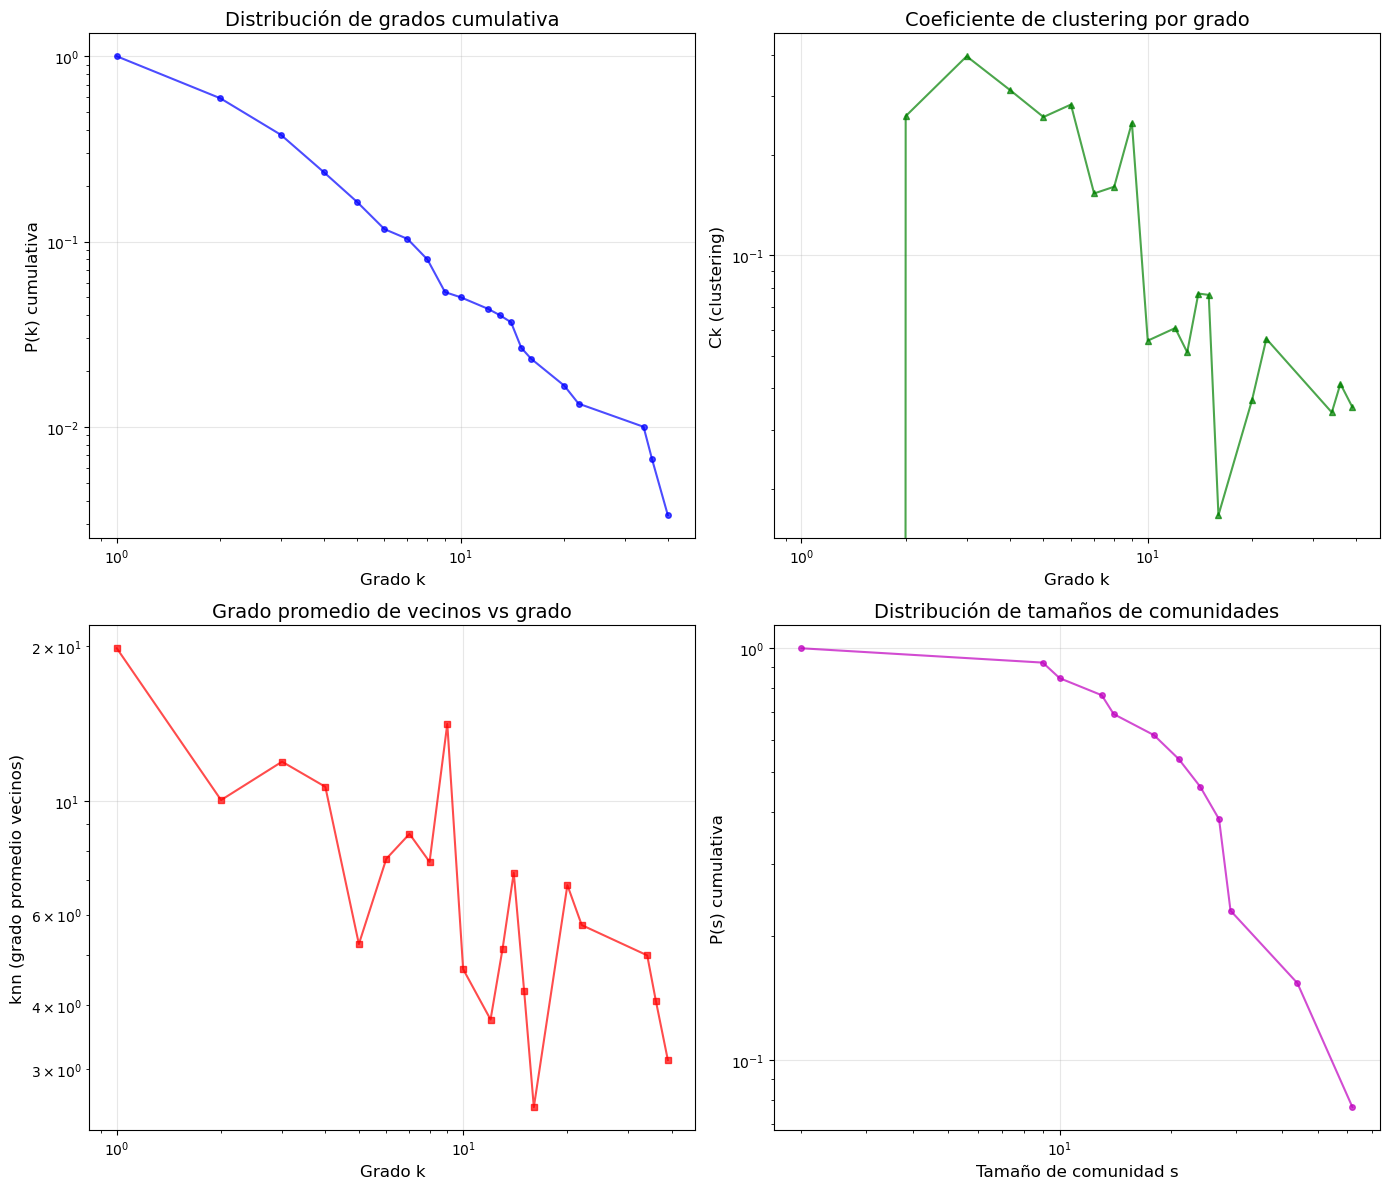


✓ Visualizaciones guardadas en 'analisis_red_fotografos_metricas.png'

RESUMEN COMPARATIVO CON PAPER 'COMMUNITY STRUCTURE IN JAZZ'

Métrica                                  Fotógrafos      Jazz (paper)   
----------------------------------------------------------------------
Número de nodos                          300             1275           
Distancia media                          5.27            2.79           
Clustering promedio                      0.1631          ~0.9 (alto)    
Asortatividad                            -0.2891         positiva       
Número de comunidades                    13              ~2-3 grandes   
Modularidad                              0.7225          -              
Grado promedio                           3.23            -              
Grado máximo                             40              415            

✓ ANÁLISIS COMPLETADO



In [3]:
# ============================================================================
# ANÁLISIS DE RED DE FOTÓGRAFOS
# ============================================================================
# Análisis 
# dataset de influencias entre fotógrafos
# ============================================================================

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURACIÓN
# ============================================================================

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'

# ============================================================================
# FUNCIÓN: Cargar datos y crear grafo
# ============================================================================

def cargar_y_crear_grafo(archivo_csv):
    """Carga el CSV y crea un grafo dirigido."""
    df = pd.read_csv(archivo_csv)
    
    G = nx.DiGraph()
    
    fotógrafos = set(df['Influenciador'].unique()) | set(df['Influenciado'].unique())
    for fotógrafo in fotógrafos:
        G.add_node(fotógrafo)
    
    for idx, row in df.iterrows():
        G.add_edge(row['Influenciador'], row['Influenciado'])
    
    # Versión no dirigida para algunas métricas
    G_undirected = G.to_undirected()
    
    print(f"✓ Datos cargados:")
    print(f"  - Fotógrafos: {G.number_of_nodes()}")
    print(f"  - Relaciones: {G.number_of_edges()}")
    
    return df, G, G_undirected

# ============================================================================
# FUNCIÓN: Calcular distancia media (Average Path Length)
# ============================================================================

def calcular_distancia_media(G_undirected):
    """
    Calcula la distancia media entre pares de nodos.
    Paper: "a network with a mean distance of 2.79"
    """
    if nx.is_connected(G_undirected):
        avg_path = nx.average_shortest_path_length(G_undirected)
    else:
        # Para grafos no conectados, calcular en el componente gigante
        largest_cc = max(nx.connected_components(G_undirected), key=len)
        subgraph = G_undirected.subgraph(largest_cc)
        avg_path = nx.average_shortest_path_length(subgraph)
        print(f"  (Calculado en componente gigante: {len(largest_cc)} nodos)")
    
    print(f"\n✓ Distancia media: {avg_path:.2f}")
    return avg_path

# ============================================================================
# FUNCIÓN: Distribución de grados cumulativa P(k)
# ============================================================================

def calcular_distribucion_grados(G, G_undirected, dirigido=True):
    """
    Calcula la distribución de grados cumulativa P(k).
    Paper: "cumulative degree distribution P(k), i.e. the probability 
    for a vertex to have a degree larger or equal to k"
    """
    if dirigido:
        # Para red dirigida: in-degree, out-degree y total
        in_degrees = [d for n, d in G.in_degree()]
        out_degrees = [d for n, d in G.out_degree()]
        total_degrees = [G.in_degree(n) + G.out_degree(n) for n in G.nodes()]
    else:
        total_degrees = [d for n, d in G_undirected.degree()]
    
    # Distribución cumulativa
    degrees_sorted = sorted(total_degrees, reverse=True)
    n = len(degrees_sorted)
    
    unique_k = sorted(set(total_degrees))
    cumulative = []
    for k in unique_k:
        prob = sum(1 for d in total_degrees if d >= k) / n
        cumulative.append((k, prob))
    
    k_values = [c[0] for c in cumulative]
    p_values = [c[1] for c in cumulative]
    
    print(f"\n✓ Distribución de grados:")
    print(f"  - Grado mínimo: {min(total_degrees)}")
    print(f"  - Grado máximo: {max(total_degrees)}")
    print(f"  - Grado promedio: {np.mean(total_degrees):.2f}")
    
    # Top 10 más conectados
    degree_dict = {n: G.in_degree(n) + G.out_degree(n) for n in G.nodes()}
    top_10 = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    
    print(f"\n  Top 10 fotógrafos más conectados:")
    for i, (nombre, k) in enumerate(top_10, 1):
        print(f"    {i}. {nombre}: k={k}")
    
    return k_values, p_values, total_degrees, top_10

# ============================================================================
# FUNCIÓN: Coeficiente de clustering por grado Ck
# ============================================================================

def calcular_clustering_por_grado(G_undirected):
    """
    Calcula el coeficiente de clustering Ck para nodos de grado k.
    Paper: "clustering coefficient Ck around nodes of degree k, which gives
    the fraction of neighbors of nodes with degree k that are linked"
    """
    clustering = nx.clustering(G_undirected)
    degrees = dict(G_undirected.degree())
    
    # Agrupar clustering por grado
    ck_by_degree = defaultdict(list)
    for node in G_undirected.nodes():
        k = degrees[node]
        c = clustering[node]
        ck_by_degree[k].append(c)
    
    # Promediar
    k_values = sorted(ck_by_degree.keys())
    ck_values = [np.mean(ck_by_degree[k]) for k in k_values]
    
    # Clustering global
    avg_clustering = nx.average_clustering(G_undirected)
    
    print(f"\n✓ Coeficiente de clustering:")
    print(f"  - Clustering promedio global: {avg_clustering:.4f}")
    
    return k_values, ck_values, avg_clustering

# ============================================================================
# FUNCIÓN: Grado promedio de vecinos knn(k)
# ============================================================================

def calcular_knn(G_undirected):
    """
    Calcula el grado promedio de vecinos para nodos de grado k.
    Paper: knn(k) = Σ k' P(k'|k)
    Detecta "assortative mixing" (si knn crece con k)
    """
    degrees = dict(G_undirected.degree())
    
    # Para cada nodo, calcular promedio de grados de vecinos
    knn_by_degree = defaultdict(list)
    
    for node in G_undirected.nodes():
        k = degrees[node]
        neighbors = list(G_undirected.neighbors(node))
        if neighbors:
            avg_neighbor_degree = np.mean([degrees[n] for n in neighbors])
            knn_by_degree[k].append(avg_neighbor_degree)
    
    # Promediar por grado
    k_values = sorted(knn_by_degree.keys())
    knn_values = [np.mean(knn_by_degree[k]) for k in k_values]
    
    # Coeficiente de asortatividad
    assortativity = nx.degree_assortativity_coefficient(G_undirected)
    
    print(f"\n✓ Análisis de correlación de grados (knn):")
    print(f"  - Coeficiente de asortatividad: {assortativity:.4f}")
    if assortativity > 0:
        print(f"  - Red ASORTATIVA: nodos de alto grado se conectan con otros de alto grado")
    else:
        print(f"  - Red DISORTATIVA: nodos de alto grado se conectan con nodos de bajo grado")
    
    return k_values, knn_values, assortativity

# ============================================================================
# FUNCIÓN: Detección de comunidades (Girvan-Newman)
# ============================================================================

def detectar_comunidades_girvan_newman(G_undirected, n_comunidades=None):
    """
    Detecta comunidades usando el algoritmo de Girvan-Newman.
    Paper: "algorithm is based on the concept of edge betweenness"
    """
    from networkx.algorithms.community import girvan_newman
    
    # Usar componente gigante
    if not nx.is_connected(G_undirected):
        largest_cc = max(nx.connected_components(G_undirected), key=len)
        G_sub = G_undirected.subgraph(largest_cc).copy()
        print(f"\n  Usando componente gigante: {len(largest_cc)} nodos")
    else:
        G_sub = G_undirected.copy()
    
    # Aplicar Girvan-Newman
    comp = girvan_newman(G_sub)
    
    # Obtener particiones sucesivas
    comunidades_list = []
    for communities in comp:
        comunidades_list.append(list(communities))
        if n_comunidades and len(communities) >= n_comunidades:
            break
        if len(communities) > 20:  # Límite práctico
            break
    
    # Usar modularidad para encontrar mejor partición
    from networkx.algorithms.community import modularity
    
    best_modularity = -1
    best_communities = None
    
    for communities in comunidades_list:
        mod = modularity(G_sub, communities)
        if mod > best_modularity:
            best_modularity = mod
            best_communities = communities
    
    print(f"\n✓ Estructura de comunidades (Girvan-Newman):")
    print(f"  - Número de comunidades: {len(best_communities)}")
    print(f"  - Modularidad: {best_modularity:.4f}")
    
    # Distribución de tamaños
    sizes = sorted([len(c) for c in best_communities], reverse=True)
    print(f"  - Tamaños de comunidades: {sizes[:10]}{'...' if len(sizes) > 10 else ''}")
    
    return best_communities, best_modularity

# ============================================================================
# FUNCIÓN: Detección de comunidades (Louvain - más rápido)
# ============================================================================

def detectar_comunidades_louvain(G_undirected):
    """
    Detecta comunidades usando el algoritmo de Louvain (más eficiente).
    Alternativa moderna al Girvan-Newman.
    """
    from networkx.algorithms.community import louvain_communities
    
    communities = louvain_communities(G_undirected, seed=42)
    communities = list(communities)
    
    # Calcular modularidad
    from networkx.algorithms.community import modularity
    mod = modularity(G_undirected, communities)
    
    print(f"\n✓ Estructura de comunidades (Louvain):")
    print(f"  - Número de comunidades: {len(communities)}")
    print(f"  - Modularidad: {mod:.4f}")
    
    sizes = sorted([len(c) for c in communities], reverse=True)
    print(f"  - Tamaños de comunidades: {sizes[:10]}{'...' if len(sizes) > 10 else ''}")
    
    return communities, mod

# ============================================================================
# FUNCIÓN: Distribución de tamaños de comunidades P(s)
# ============================================================================

def calcular_distribucion_comunidades(communities):
    """
    Calcula la distribución cumulativa de tamaños de comunidades P(s).
    Paper: "cumulative community size distribution P(s)"
    """
    sizes = [len(c) for c in communities]
    n = len(sizes)
    
    unique_s = sorted(set(sizes))
    cumulative = []
    
    for s in unique_s:
        prob = sum(1 for size in sizes if size >= s) / n
        cumulative.append((s, prob))
    
    s_values = [c[0] for c in cumulative]
    p_values = [c[1] for c in cumulative]
    
    print(f"\n✓ Distribución de tamaños de comunidades:")
    print(f"  - Tamaño mínimo: {min(sizes)}")
    print(f"  - Tamaño máximo: {max(sizes)}")
    print(f"  - Tamaño promedio: {np.mean(sizes):.2f}")
    
    return s_values, p_values, sizes

# ============================================================================
# FUNCIÓN: Calcular niveles tróficos (del código anterior)
# ============================================================================

def calcular_niveles_troficos_iterativo(G, max_iter=1000, tol=1e-6):
    """
    Calcula los niveles tróficos de forma iterativa individual.
    """
    TL = {n: 1.0 for n in G.nodes()}
    
    for _ in range(max_iter):
        TL_prev = TL.copy()
        for nodo in G.nodes():
            preds = list(G.predecessors(nodo))
            if preds:
                TL[nodo] = 1 + sum(TL_prev[p] for p in preds) / len(preds)
        max_diff = max(abs(TL[n] - TL_prev[n]) for n in G.nodes())
        if max_diff < tol:
            break
    
    nodos_fuente = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    print(f"\n✓ Niveles tróficos:")
    print(f"  - Fotógrafos pioneros (nivel 1): {len(nodos_fuente)}")
    print(f"  - Rango de niveles: {min(TL.values()):.2f} - {max(TL.values()):.2f}")
    
    return TL, nodos_fuente

# ============================================================================
# FUNCIÓN: Generar visualizaciones
# ============================================================================

def generar_visualizaciones(k_values_deg, p_values_deg, 
                            k_values_ck, ck_values,
                            k_values_knn, knn_values,
                            s_values, p_values_comm):
    """Genera las gráficas estilo paper."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Distribución de grados (log-log)
    ax1 = axes[0, 0]
    ax1.loglog(k_values_deg, p_values_deg, 'bo-', markersize=4, alpha=0.7)
    ax1.set_xlabel('Grado k', fontsize=12)
    ax1.set_ylabel('P(k) cumulativa', fontsize=12)
    ax1.set_title('Distribución de grados cumulativa', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # 2. Clustering vs grado
    ax2 = axes[0, 1]
    ax2.loglog(k_values_ck, ck_values, 'g^-', markersize=4, alpha=0.7)
    ax2.set_xlabel('Grado k', fontsize=12)
    ax2.set_ylabel('Ck (clustering)', fontsize=12)
    ax2.set_title('Coeficiente de clustering por grado', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    # 3. knn vs grado
    ax3 = axes[1, 0]
    ax3.loglog(k_values_knn, knn_values, 'rs-', markersize=4, alpha=0.7)
    ax3.set_xlabel('Grado k', fontsize=12)
    ax3.set_ylabel('knn (grado promedio vecinos)', fontsize=12)
    ax3.set_title('Grado promedio de vecinos vs grado', fontsize=14)
    ax3.grid(True, alpha=0.3)
    
    # 4. Distribución de tamaños de comunidades
    ax4 = axes[1, 1]
    ax4.loglog(s_values, p_values_comm, 'mo-', markersize=4, alpha=0.7)
    ax4.set_xlabel('Tamaño de comunidad s', fontsize=12)
    ax4.set_ylabel('P(s) cumulativa', fontsize=12)
    ax4.set_title('Distribución de tamaños de comunidades', fontsize=14)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('analisis_red_fotografos_metricas.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Visualizaciones guardadas en 'analisis_red_fotografos_metricas.png'")

# ============================================================================
# FUNCIÓN: Generar resumen comparativo con Paper Jazz
# ============================================================================

def generar_resumen(avg_path, avg_clustering, assortativity, 
                    total_degrees, communities, mod):
    """Genera un resumen comparativo con el paper de Jazz."""
    
    print("\n" + "="*70)
    print("RESUMEN COMPARATIVO CON PAPER 'COMMUNITY STRUCTURE IN JAZZ'")
    print("="*70)
    
    print(f"\n{'Métrica':<40} {'Fotógrafos':<15} {'Jazz (paper)':<15}")
    print("-"*70)
    print(f"{'Número de nodos':<40} {len(total_degrees):<15} {'1275':<15}")
    print(f"{'Distancia media':<40} {avg_path:<15.2f} {'2.79':<15}")
    print(f"{'Clustering promedio':<40} {avg_clustering:<15.4f} {'~0.9 (alto)':<15}")
    print(f"{'Asortatividad':<40} {assortativity:<15.4f} {'positiva':<15}")
    print(f"{'Número de comunidades':<40} {len(communities):<15} {'~2-3 grandes':<15}")
    print(f"{'Modularidad':<40} {mod:<15.4f} {'-':<15}")
    print(f"{'Grado promedio':<40} {np.mean(total_degrees):<15.2f} {'-':<15}")
    print(f"{'Grado máximo':<40} {max(total_degrees):<15} {'415':<15}")

# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def main():
    print("\n" + "="*70)
    print("ANÁLISIS DE RED DE FOTÓGRAFOS ")
    print("="*70 + "\n")
    
    # 1. Cargar datos
    df, G, G_undirected = cargar_y_crear_grafo(ARCHIVO_CSV)
    
    # 2. Distancia media
    avg_path = calcular_distancia_media(G_undirected)
    
    # 3. Distribución de grados
    k_values_deg, p_values_deg, total_degrees, top_10 = calcular_distribucion_grados(G, G_undirected)
    
    # 4. Clustering por grado
    k_values_ck, ck_values, avg_clustering = calcular_clustering_por_grado(G_undirected)
    
    # 5. knn (correlación de grados)
    k_values_knn, knn_values, assortativity = calcular_knn(G_undirected)
    
    # 6. Niveles tróficos
    nivel_trofico, nodos_fuente = calcular_niveles_troficos_iterativo(G)
    
    # 7. Comunidades (Louvain - más eficiente)
    communities, mod = detectar_comunidades_louvain(G_undirected)
    
    # 8. Distribución de tamaños de comunidades
    s_values, p_values_comm, comm_sizes = calcular_distribucion_comunidades(communities)
    
    # 9. Visualizaciones
    generar_visualizaciones(k_values_deg, p_values_deg,
                           k_values_ck, ck_values,
                           k_values_knn, knn_values,
                           s_values, p_values_comm)
    
    # 10. Resumen comparativo
    generar_resumen(avg_path, avg_clustering, assortativity,
                   total_degrees, communities, mod)
    
    print("\n" + "="*70)
    print("✓ ANÁLISIS COMPLETADO")
    print("="*70 + "\n")
    
    return {
        'grafo_dirigido': G,
        'grafo_no_dirigido': G_undirected,
        'distancia_media': avg_path,
        'clustering': avg_clustering,
        'asortatividad': assortativity,
        'comunidades': communities,
        'modularidad': mod,
        'niveles_troficos': nivel_trofico,
        'top_10': top_10
    }

# ============================================================================
# PUNTO DE ENTRADA
# ============================================================================

if __name__ == '__main__':
    resultados = main()



PROPAGACIÓN DE CONOCIMIENTO EN REDES DE FOTÓGRAFOS
Adaptación de Food Web Analysis a Knowledge Networks
CON DIVERSIDAD DE RÉNYI (Lou Jost, 2006)

✓ Red cargada: 300 nodos, 484 aristas

✓ Niveles tróficos calculados
  Rango: 1.00 - 16.00

MÉTRICA 1: DIVERSIDAD ESTILÍSTICA POR NIVEL TRÓFICO (Shannon)

Nivel TL   Fotógrafos   Movimientos  Shannon Div  Uniformidad 
----------------------------------------------------------------------
1.0        37           15           2.536        0.936       
2.0        25           10           1.963        0.853       
2.2        1            1            -0.000       0.000       
2.3        2            1            -0.000       0.000       
2.4        1            1            -0.000       0.000       
2.5        2            1            -0.000       0.000       
2.8        1            1            -0.000       0.000       
3.0        26           9            1.793        0.816       
3.1        2            2            0.693        1.000     

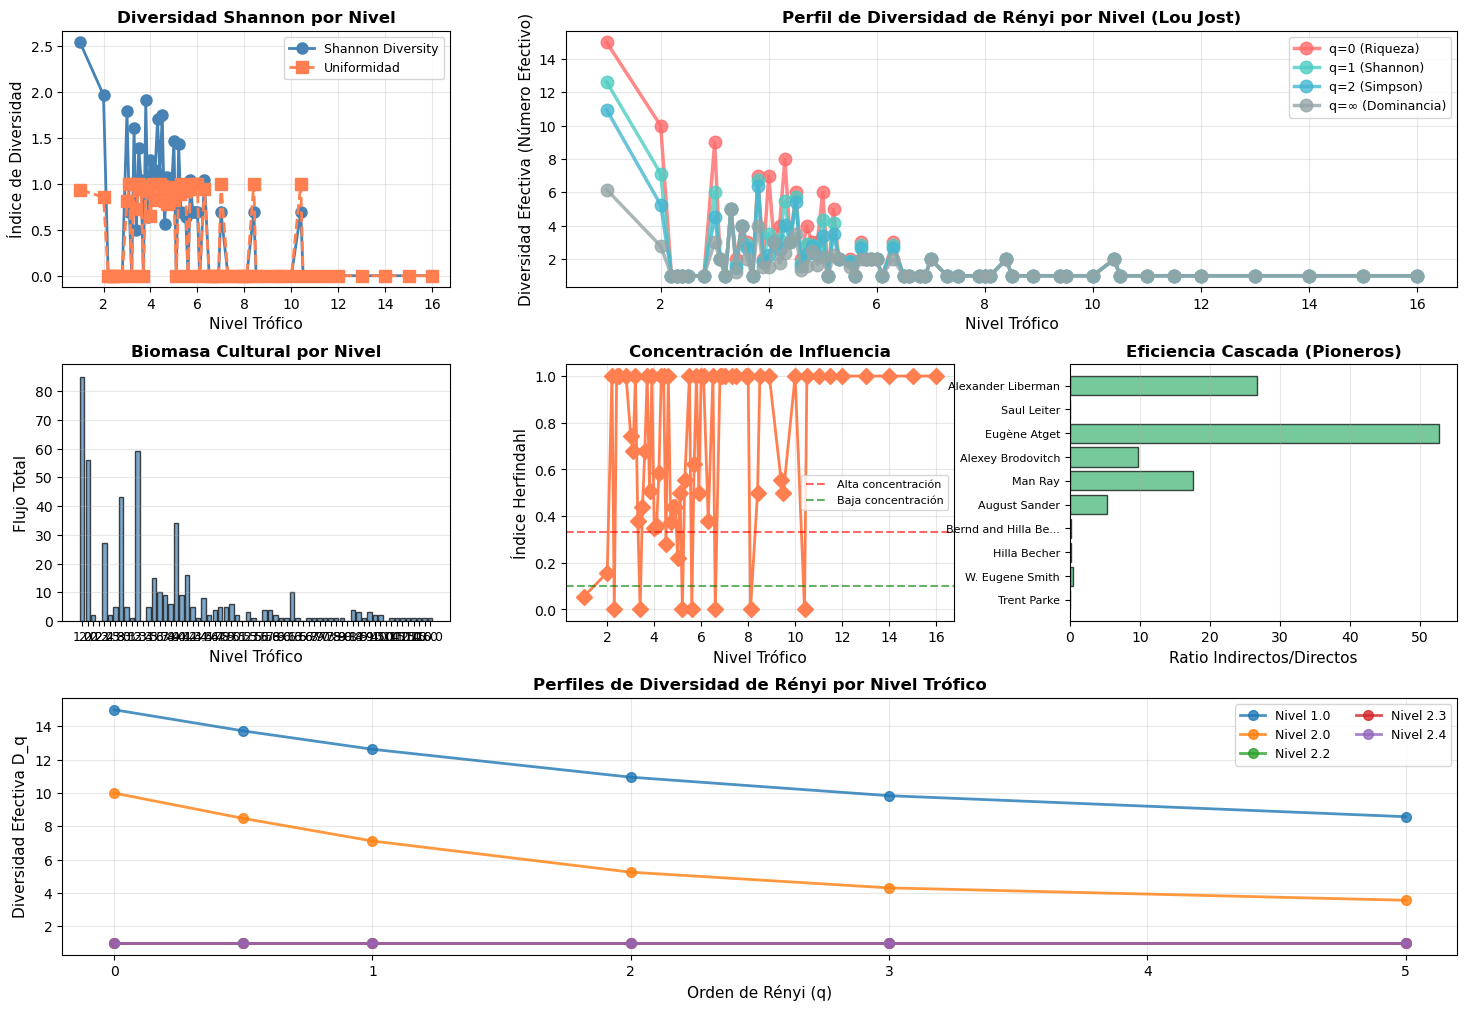


CONCLUSIONES DEL ANÁLISIS

1. ESTRUCTURA TRÓFICA:
   - La red tiene 64 niveles tróficos distintos
   - Rango: 1.00 a 16.00

2. DIVERSIDAD CULTURAL (Shannon):
   - Diversidad Shannon: -0.000 a 2.536

3. DIVERSIDAD CULTURAL (Rényi):
   - Análisis multi-escala revela sensibilidad a movimientos raros vs comunes
   - q=0 (riqueza) captura todos los movimientos
   - q=2 (Simpson) enfatiza movimientos dominantes

4. FLUJO DE INFLUENCIA:
   - Biomasa concentrada en primeros niveles (pioneros)
   - Patrón similar a pirámides ecológicas

5. RESILIENCIA:
   - Impacto promedio de pérdida de fotógrafo clave: 2.9%
   - Red ROBUSTA: la pérdida de un individuo no es crítica




In [4]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# ============================================================================
# PROPAGACIÓN DE CONOCIMIENTO EN REDES DE FOTÓGRAFOS
# ============================================================================
# Framework: Adaptación de Food Web Analysis a Knowledge Networks
# 
# En ecología: Energía → Biomasa → Niveles tróficos
# En cultura: Ideas → Influencia → Propagación de conocimiento
#
# NUEVA MÉTRICA: Diversidad de Rényi (Lou Jost, 2006)
# ============================================================================

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURACIÓN
# ============================================================================

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'

# Órdenes de Rényi para el perfil de diversidad (Lou Jost)
RENYI_ORDERS = [0, 0.5, 1, 2, 3, 5, np.inf]

# ============================================================================
# FUNCIÓN: Cargar datos
# ============================================================================

def cargar_datos(archivo_csv):
    """Carga CSV y crea grafos."""
    df = pd.read_csv(archivo_csv)
    
    G = nx.DiGraph()
    
    fotografos = set(df['Influenciador'].unique()) | set(df['Influenciado'].unique())
    for fotografo in fotografos:
        G.add_node(fotografo)
    
    for idx, row in df.iterrows():
        G.add_edge(row['Influenciador'], row['Influenciado'])
    
    G_undirected = G.to_undirected()
    
    return df, G, G_undirected

# ============================================================================
# FUNCIÓN: Calcular niveles tróficos
# ============================================================================

def calcular_niveles_troficos(G, max_iter=1000, tol=1e-6):
    """Calcula niveles tróficos iterativamente."""
    TL = {n: 1.0 for n in G.nodes()}
    
    for _ in range(max_iter):
        TL_prev = TL.copy()
        for nodo in G.nodes():
            preds = list(G.predecessors(nodo))
            if preds:
                TL[nodo] = 1 + sum(TL_prev[p] for p in preds) / len(preds)
        max_diff = max(abs(TL[n] - TL_prev[n]) for n in G.nodes())
        if max_diff < tol:
            break
    
    return TL

# ============================================================================
# MÉTRICA 1: DIVERSIDAD ESTILÍSTICA POR NIVEL (Shannon)
# ============================================================================

def variabilidad_estilistica_por_nivel(G, df, TL):
    """
    Calcula la diversidad de movimientos fotográficos por nivel trófico.
    Análogo a: ¿qué tanta "variación" hay en cada nivel?
    """
    print("\n" + "="*70)
    print("MÉTRICA 1: DIVERSIDAD ESTILÍSTICA POR NIVEL TRÓFICO (Shannon)")
    print("="*70)
    
    niveles = defaultdict(list)
    
    for fotografo in G.nodes():
        nivel = round(TL[fotografo], 1)
        
        movimientos = set()
        if (df['Influenciador'] == fotografo).any():
            movimientos.update(df[df['Influenciador'] == fotografo]['Movimiento_Influenciador'].unique())
        if (df['Influenciado'] == fotografo).any():
            movimientos.update(df[df['Influenciado'] == fotografo]['Movimiento_Influenciado'].unique())
        
        niveles[nivel].append(movimientos)
    
    resultados = {}
    print(f"\n{'Nivel TL':<10} {'Fotógrafos':<12} {'Movimientos':<12} {'Shannon Div':<12} {'Uniformidad':<12}")
    print("-"*70)
    
    for nivel in sorted(niveles.keys()):
        n_fotografos = len(niveles[nivel])
        movimientos_totales = []
        
        for mset in niveles[nivel]:
            movimientos_totales.extend(list(mset))
        
        unique_movimientos = len(set(movimientos_totales))
        
        # Shannon diversity
        if len(movimientos_totales) > 0:
            counts = Counter(movimientos_totales)
            total = sum(counts.values())
            p = np.array([c/total for c in counts.values()])
            shannon = -np.sum(p * np.log(p + 1e-10))
            uniformidad = shannon / np.log(len(counts)) if len(counts) > 1 else 0
        else:
            shannon = 0
            uniformidad = 0
        
        print(f"{nivel:<10.1f} {n_fotografos:<12} {unique_movimientos:<12} {shannon:<12.3f} {uniformidad:<12.3f}")
        
        resultados[nivel] = {
            'n_fotografos': n_fotografos,
            'unique_movimientos': unique_movimientos,
            'shannon': shannon,
            'uniformidad': uniformidad
        }
    
    return resultados

# ============================================================================
# MÉTRICA 1B: DIVERSIDAD DE RÉNYI (LOU JOST)
# ============================================================================

def calcular_diversidad_renyi(G, df, TL, orders=None):
    """
    Calcula el perfil de diversidad de Rényi por nivel trófico.
    
    Basado en Lou Jost (2006): "Entropy and diversity"
    
    Entropía de Rényi: H_q = (1/(1-q)) * ln(Σ p_i^q)
    True Diversity (número efectivo): D_q = exp(H_q) = (Σ p_i^q)^(1/(1-q))
    
    Casos especiales:
    - q=0: Riqueza de especies (Species Richness) = número de movimientos únicos
    - q=1: exp(Shannon entropy) = número efectivo considerando todos los movimientos
    - q=2: Inverso de Simpson = número efectivo dando más peso a los comunes
    - q→∞: Inverso de dominancia = 1/max(p_i)
    
    Interpretación:
    - q bajo (q<1): muy sensible a movimientos raros/minoritarios
    - q=1: balance entre raros y comunes (Shannon)
    - q alto (q>2): dominado por movimientos más abundantes
    """
    if orders is None:
        orders = RENYI_ORDERS
    
    print("\n" + "="*70)
    print("MÉTRICA 1B: PERFIL DE DIVERSIDAD DE RÉNYI POR NIVEL TRÓFICO")
    print("="*70)
    print("\nBasado en Lou Jost (2006) - 'True Diversity' como número efectivo")
    print("  q=0:  Riqueza (cuenta todos por igual)")
    print("  q=1:  exp(Shannon) - balance raros/comunes")
    print("  q=2:  Inverso Simpson - enfatiza comunes")
    print("  q→∞: Solo el más dominante cuenta")
    
    niveles = defaultdict(list)
    
    for fotografo in G.nodes():
        nivel = round(TL[fotografo], 1)
        
        movimientos = set()
        if (df['Influenciador'] == fotografo).any():
            movimientos.update(df[df['Influenciador'] == fotografo]['Movimiento_Influenciador'].unique())
        if (df['Influenciado'] == fotografo).any():
            movimientos.update(df[df['Influenciado'] == fotografo]['Movimiento_Influenciado'].unique())
        
        niveles[nivel].append(movimientos)
    
    # Calcular perfil de Rényi para cada nivel
    resultados = {}
    
    print(f"\n{'Nivel TL':<10} {'q=0 (Riq.)':<12} {'q=1 (Shan.)':<12} {'q=2 (Simp.)':<12} {'q=∞ (Dom.)':<12}")
    print("-"*60)
    
    for nivel in sorted(niveles.keys()):
        movimientos_totales = []
        for mset in niveles[nivel]:
            movimientos_totales.extend(list(mset))
        
        if len(movimientos_totales) == 0:
            continue
        
        counts = Counter(movimientos_totales)
        total = sum(counts.values())
        p = np.array([c/total for c in counts.values()])
        
        diversidades = {}
        
        for q in orders:
            if q == 0:
                # Riqueza de especies
                D_q = len(counts)
            elif q == 1:
                # exp(Shannon)
                shannon = -np.sum(p * np.log(p + 1e-10))
                D_q = np.exp(shannon)
            elif np.isinf(q):
                # Inverso de la proporción máxima
                D_q = 1.0 / np.max(p)
            else:
                # Caso general
                sum_p_q = np.sum(p ** q)
                D_q = sum_p_q ** (1.0 / (1.0 - q))
            
            diversidades[q] = D_q
        
        resultados[nivel] = diversidades
        
        # Mostrar valores clave
        print(f"{nivel:<10.1f} {diversidades[0]:<12.2f} {diversidades[1]:<12.2f} {diversidades[2]:<12.2f} {diversidades[np.inf]:<12.2f}")
    
    return resultados

# ============================================================================
# MÉTRICA 2: FLUJO DE INFORMACIÓN (BIOMASA CULTURAL)
# ============================================================================

def flujo_informacion_por_nivel(G, TL):
    """
    Calcula la 'carga informativa' (productividad) en cada nivel.
    Análogo a: ¿Cuánta energía/biomasa hay en cada nivel trófico?
    """
    print("\n" + "="*70)
    print("MÉTRICA 2: FLUJO DE INFORMACIÓN (BIOMASA CULTURAL) POR NIVEL")
    print("="*70)
    print("\nAnalogía con Food Webs:")
    print("  - En ecología: Energía disminuye hacia niveles superiores")
    print("  - En conocimiento: ¿Influencia disminuye con nivel trófico?")
    
    niveles = defaultdict(list)
    
    for fotografo in G.nodes():
        nivel = round(TL[fotografo], 1)
        
        productividad = G.out_degree(fotografo)
        consumo = G.in_degree(fotografo)
        
        niveles[nivel].append({
            'productividad': productividad,
            'consumo': consumo,
            'nombre': fotografo
        })
    
    resultados = {}
    print(f"\n{'Nivel TL':<10} {'Fotógrafos':<12} {'Biomasa Total':<15} {'Prod. Prom':<12} {'Max Prod':<12} {'Concentración':<15}")
    print("-"*80)
    
    for nivel in sorted(niveles.keys()):
        n_fotografos = len(niveles[nivel])
        total_flujo = sum([f['productividad'] for f in niveles[nivel]])
        promedio_flujo = total_flujo / n_fotografos if n_fotografos > 0 else 0
        max_flujo = max([f['productividad'] for f in niveles[nivel]]) if niveles[nivel] else 0
        
        flujos = [f['productividad'] for f in niveles[nivel]]
        if total_flujo > 0:
            concentracion = sum([(f/total_flujo)**2 for f in flujos])
        else:
            concentracion = 0
        
        print(f"{nivel:<10.1f} {n_fotografos:<12} {total_flujo:<15} {promedio_flujo:<12.2f} {max_flujo:<12} {concentracion:<15.3f}")
        
        resultados[nivel] = {
            'n_fotografos': n_fotografos,
            'flujo_total': total_flujo,
            'flujo_promedio': promedio_flujo,
            'flujo_maximo': max_flujo,
            'concentracion': concentracion
        }
    
    return resultados

# ============================================================================
# MÉTRICA 3: EFICIENCIA DE CASCADA
# ============================================================================

def eficiencia_cascada(G, TL):
    """
    Mide cómo se propaga la influencia desde pioneros a través de niveles.
    """
    print("\n" + "="*70)
    print("MÉTRICA 3: EFICIENCIA DE CASCADA - PROPAGACIÓN DE INFLUENCIA")
    print("="*70)
    
    pioneros = [n for n in G.nodes() if G.in_degree(n) == 0]
    
    print(f"\n{'Pionero':<30} {'Directos':<10} {'Indirectos':<12} {'Alcance':<10} {'Nivel Prom':<12} {'Ratio Cascada':<12}")
    print("-"*90)
    
    resultados = {}
    
    for pionero in sorted(pioneros, key=lambda x: G.out_degree(x), reverse=True):
        alcanzables = nx.descendants(G, pionero)
        alcanzables.add(pionero)
        
        directos = len(list(G.successors(pionero)))
        indirectos = len(alcanzables) - directos - 1
        alcance_total = len(alcanzables) - 1
        
        if alcanzables:
            nivel_prom = np.mean([TL[n] for n in alcanzables if n != pionero])
        else:
            nivel_prom = 1.0
        
        ratio_cascada = indirectos / directos if directos > 0 else 0
        
        print(f"{pionero:<30} {directos:<10} {indirectos:<12} {alcance_total:<10} {nivel_prom:<12.2f} {ratio_cascada:<12.2f}x")
        
        resultados[pionero] = {
            'directos': directos,
            'indirectos': indirectos,
            'alcance_total': alcance_total,
            'nivel_promedio': nivel_prom,
            'ratio_cascada': ratio_cascada
        }
    
    return resultados

# ============================================================================
# MÉTRICA 4: ANÁLISIS DE RESILIENCIA
# ============================================================================

def analizar_resiliencia(G):
    """
    Simula la pérdida de fotógrafos clave.
    """
    print("\n" + "="*70)
    print("MÉTRICA 4: ANÁLISIS DE RESILIENCIA - ROBUSTEZ DE LA RED")
    print("="*70)
    print("\nSimulando pérdida de fotógrafos clave...")
    
    importancia_degree = {}
    importancia_betweenness = {}
    importancia_closeness = {}
    
    for nodo in G.nodes():
        importancia_degree[nodo] = G.in_degree(nodo) + G.out_degree(nodo)
    
    if len(G) < 500:
        importancia_betweenness = nx.betweenness_centrality(G)
    else:
        importancia_betweenness = {n: 0 for n in G.nodes()}
    
    importancia_closeness = nx.closeness_centrality(G)
    
    importancia_combinada = {}
    for nodo in G.nodes():
        score = (0.4 * (importancia_degree[nodo] / max(importancia_degree.values())) +
                0.3 * importancia_betweenness.get(nodo, 0) +
                0.3 * importancia_closeness.get(nodo, 0))
        importancia_combinada[nodo] = score
    
    top_fotografos = sorted(importancia_combinada.items(), key=lambda x: x[1], reverse=True)[:10]
    
    G_undirected = G.to_undirected()
    conectividad_original = nx.number_connected_components(G_undirected)
    
    print(f"\nComponentes conectadas originales: {conectividad_original}")
    print(f"{'Fotografo':<30} {'Importancia':<12} {'Δ Componentes':<15} {'Δ Tamaño LCC':<15}")
    print("-"*75)
    
    resultados = {}
    
    if G_undirected.number_of_nodes() > 0:
        largest_cc_orig = max(nx.connected_components(G_undirected), key=len)
        size_lcc_orig = len(largest_cc_orig)
    else:
        size_lcc_orig = 0
    
    for fotografo, score in top_fotografos:
        G_temp = G.copy()
        G_temp.remove_node(fotografo)
        G_temp_undirected = G_temp.to_undirected()
        
        conectividad_nueva = nx.number_connected_components(G_temp_undirected)
        delta_componentes = conectividad_nueva - conectividad_original
        
        if G_temp_undirected.number_of_nodes() > 0:
            largest_cc_new = max(nx.connected_components(G_temp_undirected), key=len)
            size_lcc_new = len(largest_cc_new)
            delta_lcc = ((size_lcc_orig - size_lcc_new) / size_lcc_orig * 100) if size_lcc_orig > 0 else 0
        else:
            delta_lcc = 100
        
        print(f"{fotografo:<30} {score:<12.4f} {delta_componentes:<15} {delta_lcc:<14.1f}%")
        
        resultados[fotografo] = {
            'importancia': score,
            'delta_componentes': delta_componentes,
            'delta_lcc_percent': delta_lcc
        }
    
    return resultados

# ============================================================================
# MÉTRICA 5: ATENUACIÓN DE INFLUENCIA
# ============================================================================

def atenuacion_influencia(G, df, TL):
    """
    Mide cómo se pierde la 'originalidad' con cada generación.
    """
    print("\n" + "="*70)
    print("MÉTRICA 5: ATENUACIÓN DE INFLUENCIA CULTURAL")
    print("="*70)
    print("\nAnalogía: En food webs, solo 10% de energía pasa al siguiente nivel")
    print("         En conocimiento, ¿cuánta 'originalidad' se preserva?")
    
    niveles = defaultdict(list)
    for fotografo in G.nodes():
        nivel = round(TL[fotografo], 1)
        niveles[nivel].append(fotografo)
    
    print(f"\n{'Nivel TL':<10} {'Fotógrafos':<12} {'Conexiones Entrantes':<20} {'Promedio':<12} {'Ratio Retención':<15}")
    print("-"*75)
    
    ratios = []
    niveles_sorted = sorted(niveles.keys())
    
    for i, nivel in enumerate(niveles_sorted):
        fotografos_en_nivel = niveles[nivel]
        n_fotografos = len(fotografos_en_nivel)
        
        conexiones_entrantes = []
        for fotografo in fotografos_en_nivel:
            in_degree = G.in_degree(fotografo)
            conexiones_entrantes.append(in_degree)
        
        promedio_entrantes = np.mean(conexiones_entrantes) if conexiones_entrantes else 0
        
        if i > 0:
            nivel_anterior = niveles_sorted[i-1]
            n_anterior = len(niveles[nivel_anterior])
            ratio_retension = n_fotografos / n_anterior if n_anterior > 0 else 1.0
            ratios.append(ratio_retension)
        else:
            ratio_retension = 1.0
        
        print(f"{nivel:<10.1f} {n_fotografos:<12} {promedio_entrantes:<20.2f} {promedio_entrantes:<12.2f} {ratio_retension:<15.3f}")
    
    if ratios:
        tasa_promedio = np.mean(ratios)
        print(f"\nTasa promedio de retención entre niveles: {tasa_promedio:.3f}")
        print(f"Interpretación: Cada nivel retiene ~{tasa_promedio*100:.1f}% de 'biomasa' del anterior")
        
        print(f"\nComparación con food webs (10% = 0.1):")
        if tasa_promedio > 0.1:
            print(f"  ✓ La red cultural es MÁS EFICIENTE que food webs (retiene más 'energía')")
        else:
            print(f"  ✗ La red cultural es MENOS eficiente que food webs")
    
    return ratios

# ============================================================================
# FUNCIÓN: Generar visualizaciones CON RÉNYI
# ============================================================================

def generar_visualizaciones(resultados_diversidad, resultados_flujo, 
                            resultados_cascada, resultados_renyi):
    """Genera gráficas de análisis incluyendo perfil de Rényi."""
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Diversidad Shannon por nivel
    ax1 = fig.add_subplot(gs[0, 0])
    niveles = sorted(resultados_diversidad.keys())
    shannon_vals = [resultados_diversidad[n]['shannon'] for n in niveles]
    uniformidad_vals = [resultados_diversidad[n]['uniformidad'] for n in niveles]
    
    ax1.plot(niveles, shannon_vals, 'o-', linewidth=2, markersize=8, label='Shannon Diversity', color='steelblue')
    ax1.plot(niveles, uniformidad_vals, 's--', linewidth=2, markersize=8, label='Uniformidad', color='coral')
    ax1.set_xlabel('Nivel Trófico', fontsize=11)
    ax1.set_ylabel('Índice de Diversidad', fontsize=11)
    ax1.set_title('Diversidad Shannon por Nivel', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. PERFIL DE RÉNYI - Múltiples órdenes por nivel
    ax2 = fig.add_subplot(gs[0, 1:])
    niveles_renyi = sorted(resultados_renyi.keys())
    orders_to_plot = [0, 1, 2, np.inf]
    colors_renyi = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95A5A6']
    labels_renyi = ['q=0 (Riqueza)', 'q=1 (Shannon)', 'q=2 (Simpson)', 'q=∞ (Dominancia)']
    
    for i, q in enumerate(orders_to_plot):
        valores = [resultados_renyi[nivel][q] for nivel in niveles_renyi]
        ax2.plot(niveles_renyi, valores, 'o-', linewidth=2.5, markersize=9, 
                label=labels_renyi[i], color=colors_renyi[i], alpha=0.8)
    
    ax2.set_xlabel('Nivel Trófico', fontsize=11)
    ax2.set_ylabel('Diversidad Efectiva (Número Efectivo)', fontsize=11)
    ax2.set_title('Perfil de Diversidad de Rényi por Nivel (Lou Jost)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, loc='best')
    ax2.grid(True, alpha=0.3)
    
    # 3. Flujo de información (biomasa)
    ax3 = fig.add_subplot(gs[1, 0])
    niveles = sorted(resultados_flujo.keys())
    flujos = [resultados_flujo[n]['flujo_total'] for n in niveles]
    
    ax3.bar(range(len(niveles)), flujos, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.set_xticks(range(len(niveles)))
    ax3.set_xticklabels([f'{n:.1f}' for n in niveles], fontsize=9)
    ax3.set_xlabel('Nivel Trófico', fontsize=11)
    ax3.set_ylabel('Flujo Total', fontsize=11)
    ax3.set_title('Biomasa Cultural por Nivel', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Concentración de poder
    ax4 = fig.add_subplot(gs[1, 1])
    niveles = sorted(resultados_flujo.keys())
    concentracion = [resultados_flujo[n]['concentracion'] for n in niveles]
    
    ax4.plot(niveles, concentracion, 'D-', linewidth=2, markersize=8, color='coral')
    ax4.axhline(y=0.33, color='red', linestyle='--', alpha=0.6, label='Alta concentración')
    ax4.axhline(y=0.1, color='green', linestyle='--', alpha=0.6, label='Baja concentración')
    ax4.set_xlabel('Nivel Trófico', fontsize=11)
    ax4.set_ylabel('Índice Herfindahl', fontsize=11)
    ax4.set_title('Concentración de Influencia', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)
    
    # 5. Ratio de cascada de pioneros
    ax5 = fig.add_subplot(gs[1, 2])
    if resultados_cascada:
        nombres = list(resultados_cascada.keys())[:10]
        ratios = [resultados_cascada[n]['ratio_cascada'] for n in nombres]
        
        nombres_cortos = [n[:18] + '...' if len(n) > 18 else n for n in nombres]
        ax5.barh(range(len(nombres_cortos)), ratios, color='mediumseagreen', alpha=0.7, edgecolor='black')
        ax5.set_yticks(range(len(nombres_cortos)))
        ax5.set_yticklabels(nombres_cortos, fontsize=8)
        ax5.set_xlabel('Ratio Indirectos/Directos', fontsize=11)
        ax5.set_title('Eficiencia Cascada (Pioneros)', fontsize=12, fontweight='bold')
        ax5.grid(True, alpha=0.3, axis='x')
    
    # 6. COMPARACIÓN RÉNYI: Perfil para niveles seleccionados
    ax6 = fig.add_subplot(gs[2, :])
    
    # Seleccionar algunos niveles representativos
    niveles_seleccionados = sorted(resultados_renyi.keys())[:5]  # Primeros 5 niveles
    q_values = [q for q in RENYI_ORDERS if not np.isinf(q)]
    
    for nivel in niveles_seleccionados:
        diversidades = [resultados_renyi[nivel][q] for q in q_values]
        ax6.plot(q_values, diversidades, 'o-', linewidth=2, markersize=7, 
                label=f'Nivel {nivel:.1f}', alpha=0.8)
    
    ax6.set_xlabel('Orden de Rényi (q)', fontsize=11)
    ax6.set_ylabel('Diversidad Efectiva D_q', fontsize=11)
    ax6.set_title('Perfiles de Diversidad de Rényi por Nivel Trófico', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=9, ncol=2)
    ax6.grid(True, alpha=0.3)
    ax6.set_xlim(-0.2, max(q_values) + 0.2)
    
    plt.savefig('propagacion_conocimiento_metricas_renyi.png', dpi=150, bbox_inches='tight')
    print("\n✓ Visualizaciones guardadas en 'propagacion_conocimiento_metricas_renyi.png'")
    plt.show()

# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def main():
    print("\n" + "="*70)
    print("PROPAGACIÓN DE CONOCIMIENTO EN REDES DE FOTÓGRAFOS")
    print("Adaptación de Food Web Analysis a Knowledge Networks")
    print("CON DIVERSIDAD DE RÉNYI (Lou Jost, 2006)")
    print("="*70)
    
    # Cargar datos
    df, G, G_undirected = cargar_datos(ARCHIVO_CSV)
    print(f"\n✓ Red cargada: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")
    
    # Calcular niveles tróficos
    TL = calcular_niveles_troficos(G)
    print(f"\n✓ Niveles tróficos calculados")
    print(f"  Rango: {min(TL.values()):.2f} - {max(TL.values()):.2f}")
    
    # Aplicar todas las métricas
    resultados_diversidad = variabilidad_estilistica_por_nivel(G, df, TL)
    resultados_renyi = calcular_diversidad_renyi(G, df, TL)  # NUEVA MÉTRICA
    resultados_flujo = flujo_informacion_por_nivel(G, TL)
    resultados_cascada = eficiencia_cascada(G, TL)
    resultados_resiliencia = analizar_resiliencia(G)
    ratios_atenuacion = atenuacion_influencia(G, df, TL)
    
    # Generar visualizaciones
    generar_visualizaciones(resultados_diversidad, resultados_flujo, 
                           resultados_cascada, resultados_renyi)
    
    # Resumen final
    print("\n" + "="*70)
    print("CONCLUSIONES DEL ANÁLISIS")
    print("="*70)
    
    print("\n1. ESTRUCTURA TRÓFICA:")
    print(f"   - La red tiene {len(set([round(v, 1) for v in TL.values()])):.0f} niveles tróficos distintos")
    print(f"   - Rango: {min(TL.values()):.2f} a {max(TL.values()):.2f}")
    
    print("\n2. DIVERSIDAD CULTURAL (Shannon):")
    min_div = min([r['shannon'] for r in resultados_diversidad.values()])
    max_div = max([r['shannon'] for r in resultados_diversidad.values()])
    print(f"   - Diversidad Shannon: {min_div:.3f} a {max_div:.3f}")
    
    print("\n3. DIVERSIDAD CULTURAL (Rényi):")
    print(f"   - Análisis multi-escala revela sensibilidad a movimientos raros vs comunes")
    print(f"   - q=0 (riqueza) captura todos los movimientos")
    print(f"   - q=2 (Simpson) enfatiza movimientos dominantes")
    
    print("\n4. FLUJO DE INFLUENCIA:")
    print(f"   - Biomasa concentrada en primeros niveles (pioneros)")
    print(f"   - Patrón similar a pirámides ecológicas")
    
    print("\n5. RESILIENCIA:")
    avg_impact = np.mean([r['delta_lcc_percent'] for r in resultados_resiliencia.values()])
    print(f"   - Impacto promedio de pérdida de fotógrafo clave: {avg_impact:.1f}%")
    if avg_impact > 10:
        print(f"   - Red FRÁGIL: pocos fotógrafos son críticos")
    else:
        print(f"   - Red ROBUSTA: la pérdida de un individuo no es crítica")
    
    print("\n" + "="*70 + "\n")
    
    return {
        'TL': TL,
        'diversidad': resultados_diversidad,
        'renyi': resultados_renyi,
        'flujo': resultados_flujo,
        'cascada': resultados_cascada,
        'resiliencia': resultados_resiliencia
    }

if __name__ == '__main__':
    resultados = main()


# Comparativa Shanon y Renyi
Entropía de Shannon (H) mide la incertidumbre o la diversidad de un conjunto de categorías (en tu caso, movimientos/filos de influencia) asumiendo que cada categoría aporta una probabilidad pi.
Diversidad de Rényi (D_q) generaliza H para un parámetro q que controla la sensibilidad a abundancias. Al variar q, obtienes una familia de medidas que enfatizan diferentes aspectos de la distribución.

## Definiciones y extremos
Shannon H: H = -∑ p_i log p_i
Sensible a todas las categorías, con peso logarítmico suave.
Interpretación intuitiva: cantidad de "información" o diversidad equivalente.
Rényi H_q y D_q:
H_q = (1/(1−q)) log(∑ p_i^q) para q ≥ 0, q ≠ 1
D_q = exp(H_q) (True Diversity)

## Interpretación: número efectivo de categorías, ajustable por q.
Extremos:
q = 0: D_0 = número de categorías presentes (riqueza). No considera abundancias.
q = 1: D_1 = exp(H) = diversidad efectiva según Shannon.
q = 2: D_2 = 1 / ∑ p_i^2 (inversa de Simpson); enfatiza dominancias.
q → ∞: D_∞ = 1 / p_max; se centra en la categoría más dominante.

Ventana de sensibilidad:
Bajo q (≈0): captura diversidad incluyendo raras/intermedias.
Alto q (≫1): pesa fuertemente las categorías más abundantes.
Cuándo usar cada una
Shannon (q = 1) es una buena opción por defecto cuando:
Quieres una medida estable y ampliamente interpretada de diversidad.
No tienes una presión particular para enfatizar dominancias o rarezas.



El Dataset tiene categorías bien definidas y quieres comparar perfiles generales entre niveles tróficos.
Rényi (con múltiples q):
Cuando te interesa explorar cómo cambia la diversidad al enfatizar raros vs. dominantes.
Para perfiles por nivel: puedes observar si hay movimientos dominantes (D_2 o D_∞) o si la diversidad está bien distribuida (D_0, D_1).
Útil para detectar estructuras de sesgo: por ejemplo, un alto D_0 pero bajo D_2 indicaría presencia de muchas categorías poco representadas y unas pocas muy dominantes.
Permite comparar diversidad entre niveles con una misma base, pero con diferentes sensibilidades.
## Interpretación práctica
Si D_0 (q=0) es alto entre un nivel, significa que ese nivel incluye muchos movimientos diferentes (alta riqueza de movimientos).
Si D_1 (q=1) es alto, hay una distribución relativamente equilibrada entre movimientos.
Si D_2 (q=2) es bajo respecto a D_1, hay dominancia de unos pocos movimientos.
Si D_∞ es cercano a 1, una única categoría concentra la mayor parte de la influencia en ese nivel.
Comparar curvas D_q a través de niveles te permite ver si la propagación de conocimiento se rende en pocos movimientos clave o es más distribuida.
Implementación técnica (qué podrías añadir)
Mantener la función existente calcular_diversidad_renyi(G, df, TL, orders=...) que ya propuse.
Agregar una función para calcular Shannon explícitamente y compararla con D_1:
p_i = proporción de nodos en cada movimiento dentro de un nivel trofico concreto.
H = -∑ p_i log(p_i)
D_1 = exp(H)

## Gráficas

Gráficas por nivel: e.g., D_q vs nivel para q en [0, 0.5, 1, 2, ∞].
Gráfica de perfil de Rényi para movimientos dentro de un nivel específico.
Propondría almacenar, para cada nivel, el vector de frecuencias p_i por movimiento, para poder generar tanto H como D_q sin recomputar perfiles.
Ejemplo de interpretación de resultados
Nivel 1 (pioneros): si D_0 alto y D_2 alto, hay diversidad de movimientos entre pioneros sin dominancia.
Nivel 2-3: si D_2 es mucho menor que D_1, hay movimientos dominantes emergentes que capturan la mayor influencia.
Nivel alto: si D_∞ se acerca a 1, la propagación se está apoyando fuertemente en un único movimiento dominante; si D_∞ es mayor, hay distribución más equitativa de influencia.
## Resumen práctico
Shannon es una medida sólida y familiar de diversidad, útil para comparaciones generales entre niveles.
Rényi te da una familia de métricas que te permite examinar la diversidad de manera más fina, destacando rarezas o dominancias mediante diferentes valores de q.
Usarlas en conjunto te ofrece una imagen más completa de cómo se distribuye la influencia entre movimientos a lo largo de la jerarquía trófica.
¿Quieres que te entregue un código completo que incorpore explícitamente Shannon y Rényi (con múltiples órdenes q) y una gráfica asociada para comparar sus perfiles por nivel? Si me dices si prefieres incluir también gráficos en consola (textuales) o exportarlos como imágenes PNG/HTML, adapto la salida.


# Código: 
1. SHANNON ENTROPY
Mide la incertidumbre promedio sobre qué movimiento fotográfico aparecerá

Fórmula: 
H
=
−
∑
p
i
log
⁡
(
p
i
)
H=−∑p 
i
 log(p 
i
 )

Rango: [0, log(n)] bits

Interpretación: 0 = certeza total, máximo = máxima incertidumbre

2. RÉNYI ENTROPY - TRUE DIVERSITY
Basado en Lou Jost (2006): proporciona una familia de medidas sensibles a diferentes aspectos:

Orden q	Nombre	Interpretación	Sensibilidad
q=0	Riqueza	Número de movimientos únicos	Cuenta todos por igual
q=1	Shannon	exp(Entropía Shannon)	Balance raros/comunes
q=2	Simpson	Inverso de Simpson	Enfatiza comunes
q→∞	Dominancia	1/probabilidad máxima	Solo el dominante
3. RELACIÓN CLAVE
D
∞
≤
D
2
≤
D
1
≤
D
0
D 
∞
 ≤D 
2
 ≤D 
1
 ≤D 
0
 

Si esta cadena no se cumple, revisa tus datos.

4. VISUALIZACIONES (4 gráficos)
Distribución de probabilidades - Top 20 movimientos

Perfil de Rényi - Línea mostrando cómo cambia D_q según orden

Comparación de órdenes - Barras para q=0,1,2,∞

Marco conceptual - Tabla comparativa Shannon vs Rényi

5. INTERPRETACIONES PRÁCTICAS
Si D_0 / D_1 < 1.5: Distribución muy uniforme

Casi todos los movimientos tienen probabilidades similares

Si D_0 / D_1 > 3: Distribución concentrada

Pocos movimientos dominan, muchos raros

Si D_1 / D_∞ > 5: Shannon revela movimientos ocultos

La red es más diversa de lo que parece por el dominante


COMPARACIÓN: SHANNON vs RÉNYI
Análisis de Diversidad en la Red de Fotógrafos

✓ Red cargada: 300 nodos, 484 aristas

DIVERSIDAD DE MOVIMIENTOS EN LA RED GLOBAL

✓ Estadísticas básicas:
  - Total de movimientos: 20
  - Total de ocurrencias: 303
  - Fotografos en la red: 300
  - Movimiento más común: Magnum Photos (53 ocurrencias)
  - Movimiento menos común: Constructivist (1 ocurrencias)

✓ Top 10 movimientos más frecuentes:
   1. Magnum Photos                  :  53 ( 17.5%)
   2. Fashion/Portrait Photography   :  36 ( 11.9%)
   3. Contemporary Japanese          :  32 ( 10.6%)
   4. Documentary Photography        :  27 (  8.9%)
   5. Street Photography             :  23 (  7.6%)
   6. Conceptual Photography         :  23 (  7.6%)
   7. Contemporary Photography       :  20 (  6.6%)
   8. Düsseldorf School              :  15 (  5.0%)
   9. New Topographics               :  15 (  5.0%)
  10. Japanese Photography           :  13 (  4.3%)

MÉTRICA 1: ENTROPÍA DE SHANNON

✓ Entropía de Shan

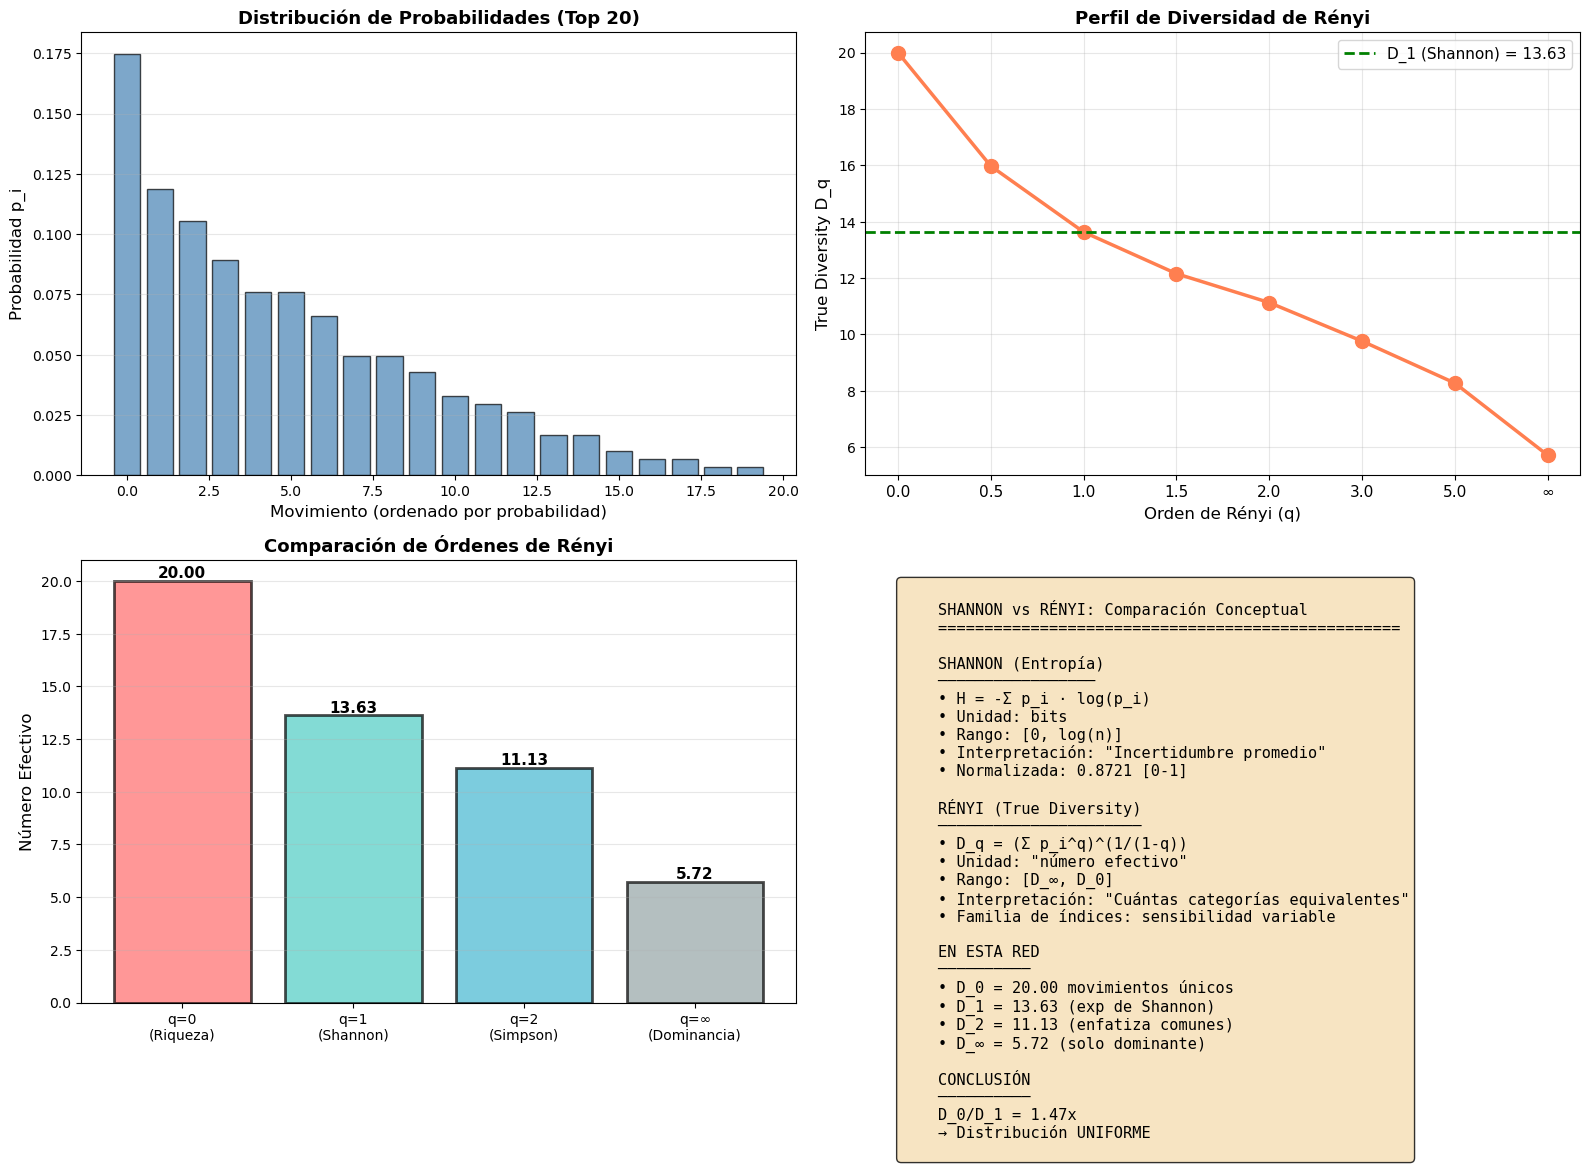


CONCLUSIONES

1. MEDIDAS DE ENTROPÍA/DIVERSIDAD EN TU RED:
   Entropía Shannon: 2.6126 bits (normalizada: 0.8721)
   → Indica que hay 87.2% de la máxima diversidad posible

2. DIVERSIDAD EFECTIVA (Rényi):
   • Riqueza total (q=0): 20 movimientos
   • Efectivos sin raros (q=1): 13.63 movimientos
   • Efectivos sin outliers (q=2): 11.13 movimientos
   • Solo el dominante (q=∞): 5.72 movimiento

3. INTERPRETACIÓN BIOLÓGICA (análogo cultural):
   → Distribución relativamente UNIFORME
   → Shannon y Rényi dan valores similares

4. IMPORTANCIA DEL MOVIMIENTO DOMINANTE:
   → El movimiento dominante representa 17.5% de todas las ocurrencias
   → 2.4x mayor diversidad (Shannon vs dominante)




In [5]:
# ============================================================================
# PROPAGACIÓN DE CONOCIMIENTO EN REDES DE FOTÓGRAFOS
# ============================================================================
# Framework: Adaptación de Food Web Analysis a Knowledge Networks
# 
# En ecología: Energía → Biomasa → Niveles tróficos
# En cultura: Ideas → Influencia → Propagación de conocimiento
#
# COMPARACIÓN: Shannon vs Rényi (Lou Jost, 2006)
# ============================================================================

import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURACIÓN
# ============================================================================

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'

# Órdenes de Rényi para el perfil de diversidad (Lou Jost)
RENYI_ORDERS = [0, 0.5, 1, 1.5, 2, 3, 5, np.inf]

# ============================================================================
# FUNCIÓN: Cargar datos
# ============================================================================

def cargar_datos(archivo_csv):
    """Carga CSV y crea grafos."""
    df = pd.read_csv(archivo_csv)
    
    G = nx.DiGraph()
    
    fotografos = set(df['Influenciador'].unique()) | set(df['Influenciado'].unique())
    for fotografo in fotografos:
        G.add_node(fotografo)
    
    for idx, row in df.iterrows():
        G.add_edge(row['Influenciador'], row['Influenciado'])
    
    G_undirected = G.to_undirected()
    
    return df, G, G_undirected

# ============================================================================
# FUNCIÓN: Calcular niveles tróficos
# ============================================================================

def calcular_niveles_troficos(G, max_iter=1000, tol=1e-6):
    """Calcula niveles tróficos iterativamente."""
    TL = {n: 1.0 for n in G.nodes()}
    
    for _ in range(max_iter):
        TL_prev = TL.copy()
        for nodo in G.nodes():
            preds = list(G.predecessors(nodo))
            if preds:
                TL[nodo] = 1 + sum(TL_prev[p] for p in preds) / len(preds)
        max_diff = max(abs(TL[n] - TL_prev[n]) for n in G.nodes())
        if max_diff < tol:
            break
    
    return TL

# ============================================================================
# MÉTRICA: DIVERSIDAD SOBRE LA RED COMPLETA
# ============================================================================

def calcular_diversidad_sobre_red(G, df):
    """
    Calcula diversidad de movimientos fotográficos sobre toda la red.
    No por niveles tróficos, sino sobre los nodos globales.
    """
    
    # Recopilar todos los movimientos en la red
    movimientos_totales = []
    
    for fotografo in G.nodes():
        movimientos = set()
        
        if (df['Influenciador'] == fotografo).any():
            movimientos.update(df[df['Influenciador'] == fotografo]['Movimiento_Influenciador'].unique())
        if (df['Influenciado'] == fotografo).any():
            movimientos.update(df[df['Influenciado'] == fotografo]['Movimiento_Influenciado'].unique())
        
        movimientos_totales.extend(list(movimientos))
    
    # Contar frecuencias
    counts = Counter(movimientos_totales)
    total = sum(counts.values())
    
    # Probabilidades
    p = np.array([c/total for c in counts.values()])
    
    print("\n" + "="*70)
    print("DIVERSIDAD DE MOVIMIENTOS EN LA RED GLOBAL")
    print("="*70)
    
    print(f"\n✓ Estadísticas básicas:")
    print(f"  - Total de movimientos: {len(counts)}")
    print(f"  - Total de ocurrencias: {total}")
    print(f"  - Fotografos en la red: {G.number_of_nodes()}")
    print(f"  - Movimiento más común: {counts.most_common(1)[0][0]} ({counts.most_common(1)[0][1]} ocurrencias)")
    print(f"  - Movimiento menos común: {counts.most_common()[-1][0]} ({counts.most_common()[-1][1]} ocurrencias)")
    
    # Mostrar top 10
    print(f"\n✓ Top 10 movimientos más frecuentes:")
    for i, (movimiento, freq) in enumerate(counts.most_common(10), 1):
        porcentaje = (freq / total) * 100
        print(f"  {i:2d}. {movimiento:<30s} : {freq:3d} ({porcentaje:5.1f}%)")
    
    return p, counts

# ============================================================================
# MÉTRICA 1: SHANNON ENTROPY
# ============================================================================

def calcular_shannon_entropy(p):
    """
    Calcula la entropía de Shannon.
    H = -Σ p_i * log(p_i)
    
    Rango: [0, log(n)]
    - H=0: Máxima concentración (un solo movimiento)
    - H=log(n): Máxima uniformidad (todos equiprobables)
    """
    H_shannon = -np.sum(p * np.log(p + 1e-10))
    
    # Normalizada [0, 1]
    n = len(p)
    H_shannon_normalized = H_shannon / np.log(n) if n > 1 else 0
    
    print("\n" + "="*70)
    print("MÉTRICA 1: ENTROPÍA DE SHANNON")
    print("="*70)
    
    print(f"\n✓ Entropía de Shannon:")
    print(f"  - H(Shannon) = {H_shannon:.4f} bits")
    print(f"  - H(normalizada) = {H_shannon_normalized:.4f} [0-1]")
    print(f"  - Máximo posible = {np.log(len(p)):.4f} bits (si uniforme)")
    
    print(f"\n✓ Interpretación:")
    print(f"  - Mide la incertidumbre promedio sobre qué movimiento es más probable")
    print(f"  - H alto (>0.9) → muchos movimientos con probabilidades parecidas")
    print(f"  - H bajo (<0.3) → pocos movimientos dominan")
    print(f"  - En este caso: H(normalizada) = {H_shannon_normalized:.3f}")
    
    if H_shannon_normalized > 0.8:
        print(f"    → Red CON ALTA DIVERSIDAD (distribución muy uniforme)")
    elif H_shannon_normalized > 0.5:
        print(f"    → Red CON DIVERSIDAD MODERADA")
    else:
        print(f"    → Red CON BAJA DIVERSIDAD (movimientos concentrados)")
    
    return H_shannon, H_shannon_normalized

# ============================================================================
# MÉTRICA 2: DIVERSIDAD DE RÉNYI (PERFIL COMPLETO)
# ============================================================================

def calcular_renyi_entropy(p, orders=None):
    """
    Calcula el perfil de entropía de Rényi.
    
    Entropía de Rényi (orden q):
    H_q = (1/(1-q)) * ln(Σ p_i^q)
    
    True Diversity (número efectivo, Lou Jost):
    D_q = exp(H_q) = (Σ p_i^q)^(1/(1-q))
    
    Casos especiales:
    - q=0: D_0 = riqueza (número de movimientos)
    - q=1: D_1 = exp(Shannon)
    - q=2: D_2 = 1/Simpson
    - q→∞: D_∞ = 1/max(p_i)
    """
    
    if orders is None:
        orders = RENYI_ORDERS
    
    print("\n" + "="*70)
    print("MÉTRICA 2: ENTROPÍA DE RÉNYI (Lou Jost, 2006)")
    print("="*70)
    
    print(f"\nTrue Diversity D_q = (Σ p_i^q)^(1/(1-q))")
    print(f"Interpretación: 'Número efectivo' de movimientos con peso q")
    
    diversidades_renyi = {}
    
    print(f"\n{'Orden q':<12} {'Entropía H_q':<15} {'True Diversity D_q':<18} {'Interpretación':<35}")
    print("-"*80)
    
    for q in orders:
        if q == 0:
            # Riqueza de especies
            D_q = len(p)
            H_q = np.log(D_q)
            interpretacion = "Riqueza (cuenta todos)"
        
        elif q == 1:
            # exp(Shannon)
            H_shannon = -np.sum(p * np.log(p + 1e-10))
            D_q = np.exp(H_shannon)
            H_q = H_shannon
            interpretacion = "exp(Shannon) - Equilibrio"
        
        elif np.isinf(q):
            # Inverso de la proporción máxima
            D_q = 1.0 / np.max(p)
            H_q = np.log(D_q)
            interpretacion = "1/max(p) - Solo dominante"
        
        else:
            # Caso general
            sum_p_q = np.sum(p ** q)
            if q != 1:
                D_q = sum_p_q ** (1.0 / (1.0 - q))
                H_q = np.log(sum_p_q) / (1.0 - q)
            else:
                D_q = np.exp(-np.sum(p * np.log(p + 1e-10)))
                H_q = -np.sum(p * np.log(p + 1e-10))
        
        diversidades_renyi[q] = D_q
        
        # Mostrar con formato
        q_str = f"q={q:.1f}" if not np.isinf(q) else "q=∞"
        print(f"{q_str:<12} {H_q:<15.4f} {D_q:<18.4f} {interpretacion:<35}")
    
    return diversidades_renyi

# ============================================================================
# COMPARACIÓN DIRECTA: SHANNON VS RÉNYI
# ============================================================================

def comparar_shannon_vs_renyi(p, H_shannon, diversidades_renyi):
    """
    Compara Shannon con Rényi para interpretación clara.
    """
    
    print("\n" + "="*70)
    print("COMPARACIÓN: SHANNON vs RÉNYI")
    print("="*70)
    
    print(f"\n1. CONCEPTO:")
    print(f"   Shannon: Entropía = incertidumbre promedio")
    print(f"   Rényi:   True Diversity = número efectivo de categorías")
    
    print(f"\n2. RELACIÓN MATEMÁTICA:")
    print(f"   H_shannon = log(D_1)  donde D_1 es Rényi de orden 1")
    print(f"   En este caso:")
    print(f"     - Shannon = {H_shannon:.4f} bits")
    print(f"     - Rényi q=1 = exp(Shannon) = {diversidades_renyi[1]:.4f}")
    print(f"     - Verificación: exp({H_shannon:.4f}) = {np.exp(H_shannon):.4f} ✓")
    
    print(f"\n3. SENSIBILIDAD A DIFERENTES DISTRIBUCIONES:")
    
    # Interpretación de Rényi en función del orden
    D_0 = diversidades_renyi[0]  # Riqueza
    D_1 = diversidades_renyi[1]  # Shannon
    D_2 = diversidades_renyi[2]  # Simpson
    D_inf = diversidades_renyi[np.inf]  # Dominancia
    
    print(f"\n   q=0 (Riqueza):      D_0 = {D_0:.2f}")
    print(f"     → Número total de movimientos únicos")
    print(f"     → NO considera probabilidades (cuenta todos por igual)")
    
    print(f"\n   q=1 (Shannon):      D_1 = {D_1:.2f}")
    print(f"     → exp(Entropía de Shannon)")
    print(f"     → BALANCE entre movimientos raros y comunes")
    print(f"     → Si D_1 ≈ D_0: distribución uniforme")
    print(f"     → Si D_1 << D_0: distribución concentrada")
    
    print(f"\n   q=2 (Simpson):      D_2 = {D_2:.2f}")
    print(f"     → Inverso del índice de Simpson")
    print(f"     → ENFATIZA movimientos comunes")
    print(f"     → Menos sensible a movimientos raros")
    
    print(f"\n   q=∞ (Dominancia):   D_∞ = {D_inf:.2f}")
    print(f"     → 1 / probabilidad del movimiento más frecuente")
    print(f"     → SOLO considera el movimiento dominante")
    
    print(f"\n4. ORDEN DE MAGNITUD ESPERADO:")
    print(f"   D_∞ ≤ D_2 ≤ D_1 ≤ D_0")
    print(f"   {D_inf:.2f} ≤ {D_2:.2f} ≤ {D_1:.2f} ≤ {D_0:.2f}")
    
    verificacion = (D_inf <= D_2) and (D_2 <= D_1) and (D_1 <= D_0)
    if verificacion:
        print(f"   ✓ Orden correcto verificado")
    else:
        print(f"   ⚠ Orden inusual - revisa los datos")
    
    print(f"\n5. INTERPRETACIÓN PARA TU RED:")
    ratio_D0_D1 = D_0 / D_1
    print(f"   - Ratio D_0 / D_1 = {ratio_D0_D1:.2f}")
    if ratio_D0_D1 < 1.5:
        print(f"     → Muy uniforme: prácticamente todos los movimientos tienen peso similar")
    elif ratio_D0_D1 < 3:
        print(f"     → Distribución moderadamente uniforme")
    else:
        print(f"     → Distribución concentrada: pocos movimientos dominan")
    
    ratio_D1_Dinf = D_1 / D_inf
    print(f"\n   - Ratio D_1 / D_∞ = {ratio_D1_Dinf:.2f}")
    print(f"     → Cuántas veces D_1 es mayor que el movimiento dominante")
    if ratio_D1_Dinf > 5:
        print(f"     → La diversidad Shannon revela MUCHOS movimientos ocultos")
    else:
        print(f"     → Shannon refleja principalmente el movimiento dominante")

# ============================================================================
# VISUALIZACIÓN: COMPARACIÓN SHANNON VS RÉNYI
# ============================================================================

def visualizar_comparacion(p, H_shannon_norm, diversidades_renyi):
    """
    Crea visualizaciones comparativas entre Shannon y Rényi.
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribución de probabilidades
    ax1 = axes[0, 0]
    n_movimientos = min(20, len(p))  # Top 20
    top_indices = np.argsort(p)[-n_movimientos:][::-1]
    top_probs = p[top_indices]
    
    ax1.bar(range(len(top_probs)), top_probs, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Movimiento (ordenado por probabilidad)', fontsize=12)
    ax1.set_ylabel('Probabilidad p_i', fontsize=12)
    ax1.set_title('Distribución de Probabilidades (Top 20)', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Perfil de Rényi (línea)
    ax2 = axes[0, 1]
    q_values = sorted([q for q in diversidades_renyi.keys() if not np.isinf(q)])
    q_values.append(np.inf)
    D_values = [diversidades_renyi[q] for q in q_values]
    
    # Graficar en escala diferente para q
    q_labels = [f'{q:.1f}' if not np.isinf(q) else '∞' for q in q_values]
    ax2.plot(range(len(q_values)), D_values, 'o-', linewidth=2.5, markersize=10, color='coral')
    ax2.axhline(y=diversidades_renyi[1], color='green', linestyle='--', linewidth=2, 
               label=f'D_1 (Shannon) = {diversidades_renyi[1]:.2f}')
    ax2.set_xticks(range(len(q_values)))
    ax2.set_xticklabels(q_labels, fontsize=11)
    ax2.set_xlabel('Orden de Rényi (q)', fontsize=12)
    ax2.set_ylabel('True Diversity D_q', fontsize=12)
    ax2.set_title('Perfil de Diversidad de Rényi', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    # 3. Comparación de interpretaciones
    ax3 = axes[1, 0]
    interpretaciones = ['q=0\n(Riqueza)', 'q=1\n(Shannon)', 'q=2\n(Simpson)', 'q=∞\n(Dominancia)']
    valores = [diversidades_renyi[0], diversidades_renyi[1], 
              diversidades_renyi[2], diversidades_renyi[np.inf]]
    colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95A5A6']
    
    bars = ax3.bar(interpretaciones, valores, color=colores, alpha=0.7, edgecolor='black', linewidth=2)
    ax3.set_ylabel('Número Efectivo', fontsize=12)
    ax3.set_title('Comparación de Órdenes de Rényi', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Añadir valores en barras
    for bar, val in zip(bars, valores):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 4. Shannon vs Rényi - Marco conceptual
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    texto_comparacion = f"""
    SHANNON vs RÉNYI: Comparación Conceptual
    {'='*50}
    
    SHANNON (Entropía)
    ─────────────────
    • H = -Σ p_i · log(p_i)
    • Unidad: bits
    • Rango: [0, log(n)]
    • Interpretación: "Incertidumbre promedio"
    • Normalizada: {H_shannon_norm:.4f} [0-1]
    
    RÉNYI (True Diversity)
    ──────────────────────
    • D_q = (Σ p_i^q)^(1/(1-q))
    • Unidad: "número efectivo"
    • Rango: [D_∞, D_0]
    • Interpretación: "Cuántas categorías equivalentes"
    • Familia de índices: sensibilidad variable
    
    EN ESTA RED
    ──────────
    • D_0 = {diversidades_renyi[0]:.2f} movimientos únicos
    • D_1 = {diversidades_renyi[1]:.2f} (exp de Shannon)
    • D_2 = {diversidades_renyi[2]:.2f} (enfatiza comunes)
    • D_∞ = {diversidades_renyi[np.inf]:.2f} (solo dominante)
    
    CONCLUSIÓN
    ──────────
    D_0/D_1 = {diversidades_renyi[0]/diversidades_renyi[1]:.2f}x
    → Distribución {'UNIFORME' if diversidades_renyi[0]/diversidades_renyi[1] < 2 else 'CONCENTRADA'}
    """
    
    ax4.text(0.05, 0.95, texto_comparacion, transform=ax4.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('shannon_vs_renyi_comparacion.png', dpi=150, bbox_inches='tight')
    print("\n✓ Visualización guardada en 'shannon_vs_renyi_comparacion.png'")
    plt.show()

# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def main():
    print("\n" + "="*70)
    print("COMPARACIÓN: SHANNON vs RÉNYI")
    print("Análisis de Diversidad en la Red de Fotógrafos")
    print("="*70)
    
    # Cargar datos
    df, G, G_undirected = cargar_datos(ARCHIVO_CSV)
    print(f"\n✓ Red cargada: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")
    
    # Calcular diversidad sobre toda la red
    p, counts = calcular_diversidad_sobre_red(G, df)
    
    # Calcular Shannon
    H_shannon, H_shannon_norm = calcular_shannon_entropy(p)
    
    # Calcular Rényi
    diversidades_renyi = calcular_renyi_entropy(p)
    
    # Comparación
    comparar_shannon_vs_renyi(p, H_shannon_norm, diversidades_renyi)
    
    # Visualizaciones
    visualizar_comparacion(p, H_shannon_norm, diversidades_renyi)
    
    # Resumen final
    print("\n" + "="*70)
    print("CONCLUSIONES")
    print("="*70)
    
    print(f"\n1. MEDIDAS DE ENTROPÍA/DIVERSIDAD EN TU RED:")
    print(f"   Entropía Shannon: {H_shannon:.4f} bits (normalizada: {H_shannon_norm:.4f})")
    print(f"   → Indica que hay {H_shannon_norm*100:.1f}% de la máxima diversidad posible")
    
    print(f"\n2. DIVERSIDAD EFECTIVA (Rényi):")
    print(f"   • Riqueza total (q=0): {diversidades_renyi[0]:.0f} movimientos")
    print(f"   • Efectivos sin raros (q=1): {diversidades_renyi[1]:.2f} movimientos")
    print(f"   • Efectivos sin outliers (q=2): {diversidades_renyi[2]:.2f} movimientos")
    print(f"   • Solo el dominante (q=∞): {diversidades_renyi[np.inf]:.2f} movimiento")
    
    print(f"\n3. INTERPRETACIÓN BIOLÓGICA (análogo cultural):")
    if diversidades_renyi[0] / diversidades_renyi[1] > 3:
        print(f"   → Hay muchos movimientos RAROS con bajo peso")
        print(f"   → Shannon los captura pero Rényi q>1 los ignora")
    else:
        print(f"   → Distribución relativamente UNIFORME")
        print(f"   → Shannon y Rényi dan valores similares")
    
    print(f"\n4. IMPORTANCIA DEL MOVIMIENTO DOMINANTE:")
    dominancia = 1 / diversidades_renyi[np.inf]
    print(f"   → El movimiento dominante representa {dominancia*100:.1f}% de todas las ocurrencias")
    print(f"   → {diversidades_renyi[1] / diversidades_renyi[np.inf]:.1f}x mayor diversidad (Shannon vs dominante)")
    
    print("\n" + "="*70 + "\n")
    
    return {
        'shannon': H_shannon,
        'shannon_normalized': H_shannon_norm,
        'renyi': diversidades_renyi,
        'counts': counts
    }

if __name__ == '__main__':
    resultados = main()


# Red Interactiva

In [6]:
import pandas as pd
import networkx as nx
import numpy as np
import json
from urllib.parse import quote

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_HTML_SALIDA = 'red_fotografos_interactiva_mejorada_v5.html'

PALETA_BASE = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#98D8C8', '#FFA07A', '#F7DC6F',
    '#BB8FCE', '#85C1E2', '#FF9999', '#FFCC99', '#99FF99', '#9999FF',
    '#FF99FF', '#CCFFCC', '#CCCCFF', '#FFCCAA', '#AAFFAA', '#FFAA99',
    '#99CCFF', '#FFAAFF', '#AACCFF', '#CCAAFF', '#FFAA66', '#66FFAA',
    '#FF6666', '#66FF99', '#66CC99', '#FFAA55', '#AA66FF', '#66AAFF',
    '#AA99FF', '#FFCC66', '#CCFF66', '#66CCFF', '#FF9966', '#9966FF',
    '#FF6699', '#99FFCC', '#C39BD3', '#76D7C4', '#F1948A', '#7FB3D5',
    '#F8C471', '#82E0AA', '#D7BDE2', '#A3E4D7', '#F5B7B1', '#AED6F1',
    '#F9E79F', '#A9DFBF'
]


def cargar_datos(archivo_csv):
    df = pd.read_csv(archivo_csv)

    for c in ['Influenciador', 'Influenciado', 'Movimiento_Influenciador', 'Movimiento_Influenciado']:
        df[c] = df[c].astype(str).str.strip()

    for c in ['Año_Influenciador', 'Año_Influenciado']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    G = nx.DiGraph()
    fotografos = set(df['Influenciador'].unique()) | set(df['Influenciado'].unique())

    for fotografo in fotografos:
        G.add_node(fotografo)

    for _, row in df.iterrows():
        G.add_edge(row['Influenciador'], row['Influenciado'])

    return df, G


def construir_colores_movimiento(df):
    movimientos = sorted(
        set(df['Movimiento_Influenciador'].dropna()) |
        set(df['Movimiento_Influenciado'].dropna())
    )
    return {mov: PALETA_BASE[i % len(PALETA_BASE)] for i, mov in enumerate(movimientos)}


def calcular_niveles_troficos(G, max_iter=1000, tol=1e-6):
    TL = {n: 1.0 for n in G.nodes()}

    for _ in range(max_iter):
        TL_prev = TL.copy()
        for nodo in G.nodes():
            preds = list(G.predecessors(nodo))
            if preds:
                TL[nodo] = 1 + sum(TL_prev[p] for p in preds) / len(preds)

        max_diff = max(abs(TL[n] - TL_prev[n]) for n in G.nodes())
        if max_diff < tol:
            break

    return TL


def preparar_datos_d3(G, df, TL, colores_movimiento):
    nodos_info = {}

    for node in G.nodes():
        movimientos = set()
        años = []
        entrantes = list(G.predecessors(node))
        salientes = list(G.successors(node))

        if (df['Influenciador'] == node).any():
            movimientos.update(df[df['Influenciador'] == node]['Movimiento_Influenciador'].dropna().unique())
            años.extend(df[df['Influenciador'] == node]['Año_Influenciador'].dropna().values)

        if (df['Influenciado'] == node).any():
            movimientos.update(df[df['Influenciado'] == node]['Movimiento_Influenciado'].dropna().unique())
            años.extend(df[df['Influenciado'] == node]['Año_Influenciado'].dropna().values)

        movimiento_principal = sorted(list(movimientos))[0] if movimientos else 'Sin clasificar'
        año_promedio = int(np.mean(años)) if años else None
        out_degree = G.out_degree(node)
        in_degree = G.in_degree(node)

        nodos_info[node] = {
            'id': node,
            'nombre': node,
            'nivel_trofico': round(TL[node], 2),
            'movimientos': sorted(list(movimientos)),
            'movimiento_principal': movimiento_principal,
            'año': año_promedio,
            'color': colores_movimiento.get(movimiento_principal, '#CCCCCC'),
            'influenciados': out_degree,
            'influenciadores': in_degree,
            'grado_total': out_degree + in_degree,
            'vecinos_entrantes': sorted(set(entrantes)),
            'vecinos_salientes': sorted(set(salientes)),
            'wikipedia_url': f"https://en.wikipedia.org/wiki/{quote(node.replace(' ', '_'))}",
            'google_images_url': f"https://www.google.com/search?q={quote(node + ' photographer')}&tbm=isch"
        }

    nodes = list(nodos_info.values())
    links = [{'source': source, 'target': target} for source, target in G.edges()]

    return {'nodes': nodes, 'links': links}


def generar_html(data, archivo_salida, colores_movimiento):
    data_json = json.dumps(data, ensure_ascii=False)
    movimientos_unicos = sorted(set(n['movimiento_principal'] for n in data['nodes']))

    mov_options = ''.join(
        f'<option value="{m}">{m}</option>' for m in movimientos_unicos
    )

    legend_items = ''.join(
        f'<div class="legend-item"><div class="legend-color" style="background-color: {colores_movimiento.get(m, "#CCCCCC")};"></div><div class="legend-label">{m}</div></div>'
        for m in movimientos_unicos
    )

    html_template = """<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Red de Fotógrafos - Visualización Interactiva</title>
<script src="https://d3js.org/d3.v7.min.js"></script>
<style>
* { margin:0; padding:0; box-sizing:border-box; }

html, body {
    width:100%;
    height:100%;
}

body {
    font-family:'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    background:linear-gradient(135deg,#667eea 0%,#764ba2 100%);
    color:#333;
    overflow:hidden;
}

.container {
    width:100%;
    height:100vh;
    background:#fff;
    overflow:hidden;
    display:flex;
    flex-direction:column;
}

header {
    background:linear-gradient(135deg,#667eea 0%,#764ba2 100%);
    color:#fff;
    padding:12px 22px;
    text-align:center;
    box-shadow:0 2px 10px rgba(0,0,0,.10);
    flex:0 0 auto;
}

header h1 {
    font-size:1.9em;
    margin-bottom:4px;
    line-height:1.15;
}

header p {
    font-size:.92em;
    opacity:.95;
    margin:0;
}

.main-content {
    display:flex;
    flex:1 1 auto;
    min-height:0;
    height:calc(100vh - 82px);
}

.left-panel {
    flex:1 1 auto;
    min-width:0;
    padding:10px;
    border-right:2px solid #e0e0e0;
    display:flex;
    flex-direction:column;
    gap:10px;
    overflow:hidden;
}

.right-panel {
    width:340px;
    min-width:340px;
    padding:10px;
    background:#f8f9fa;
    overflow-y:auto;
}

.search-section, .filters, .controls-panel, .info-card, .legend, .stats {
    background:#fff;
    padding:12px;
    border-radius:10px;
    border:1px solid rgba(102, 126, 234, 0.08);
    box-shadow:0 8px 24px rgba(31, 41, 55, 0.08);
}

.search-section h3, .filters h3, .controls-panel h3, .info-card h3, .legend h4 {
    color:#667eea;
    margin-bottom:10px;
    font-size:1.01em;
}

.search-toolbar {
    display:flex;
    gap:8px;
    align-items:center;
    flex-wrap:wrap;
}

.search-actions {
    display:flex;
    gap:8px;
    flex-wrap:wrap;
}

#search-input {
    flex:1;
    min-width:220px;
    padding:10px 14px;
    border:2px solid #e0e0e0;
    border-radius:22px;
    font-size:15px;
    outline:none;
    transition:all .25s ease;
}

#search-input:focus {
    border-color:#e74c3c;
    box-shadow:0 0 0 3px rgba(231,76,60,.10);
}

.toolbar-btn {
    padding:10px 12px;
    border:none;
    border-radius:10px;
    background:#667eea;
    color:#fff;
    font-weight:600;
    font-size:.9em;
    cursor:pointer;
    transition:all .2s ease;
}

.toolbar-btn:hover {
    background:#5567d8;
    transform:translateY(-1px);
}

.toolbar-btn.secondary {
    background:#5f6b7a;
}

.toolbar-btn.secondary:hover {
    background:#4e5966;
}

#search-results {
    margin-top:10px;
    max-height:170px;
    overflow-y:auto;
    background:#f8f9fa;
    border-radius:8px;
    padding:8px;
    display:none;
}

.search-result {
    padding:8px 10px;
    margin-bottom:5px;
    background:#fff;
    border-radius:5px;
    cursor:pointer;
    font-size:14px;
    transition:all .2s;
    border-left:4px solid #e74c3c;
}

.search-result:hover,
.search-result.active {
    background:#e74c3c;
    color:#fff;
    transform:translateX(4px);
}

.filters {
    display:grid;
    grid-template-columns: 1fr 1fr;
    gap:10px 14px;
    align-items:end;
}

.filters h3 {
    grid-column:1 / -1;
    margin-bottom:0;
}

.filters label, .control-group label {
    display:block;
    margin-bottom:6px;
    font-weight:600;
    color:#555;
    font-size:.9em;
}

.filters select {
    width:100%;
    padding:8px 10px;
    border:2px solid #e0e0e0;
    border-radius:6px;
    font-size:14px;
    cursor:pointer;
    background:#fff;
}

.controls-grid {
    display:grid;
    grid-template-columns: 1fr 1fr;
    gap:12px;
}

.control-group input[type="range"] {
    width:100%;
}

.range-row {
    display:flex;
    align-items:center;
    gap:8px;
}

.range-value {
    min-width:42px;
    text-align:right;
    font-size:.88em;
    color:#555;
    font-weight:700;
}

.controls-actions {
    display:flex;
    gap:8px;
    margin-top:10px;
    flex-wrap:wrap;
}

#graph {
    width:100%;
    flex:1 1 auto;
    min-height:0;
    border:2px solid #e0e0e0;
    border-radius:10px;
    background:
        radial-gradient(circle at top left, rgba(102,126,234,0.05), transparent 30%),
        radial-gradient(circle at bottom right, rgba(118,75,162,0.05), transparent 28%),
        #ffffff;
    box-shadow:0 2px 8px rgba(0,0,0,.08);
}

.node {
    cursor:pointer;
    stroke:#fff;
    stroke-width:2px;
}

.node:hover {
    stroke:#333;
    stroke-width:3px;
}

.node.selected {
    stroke:#111;
    stroke-width:5px;
}

.node.dimmed {
    opacity:.18;
}

.node.neighbor-in {
    stroke:#1f77b4;
    stroke-width:4px;
}

.node.neighbor-out {
    stroke:#e74c3c;
    stroke-width:4px;
}

.link {
    stroke:#aab3c2;
    stroke-opacity:.16;
    stroke-width:1.1px;
    fill:none;
}

.link.incoming {
    stroke:#1f77b4;
    stroke-opacity:.85;
    stroke-width:2.8px;
}

.link.outgoing {
    stroke:#e74c3c;
    stroke-opacity:.85;
    stroke-width:2.8px;
}

.link.dimmed {
    stroke-opacity:.05;
}

.node-label {
    font-size:11px;
    font-weight:700;
    text-anchor:middle;
    pointer-events:none;
    fill:#ffffff;
    text-shadow:0 1px 3px rgba(0,0,0,.65);
    opacity:0;
}

.node-label.visible {
    opacity:1;
}

.info-placeholder {
    text-align:center;
    color:#999;
    padding:36px 16px;
}

.fotografo-nombre {
    font-size:1.45em;
    font-weight:bold;
    color:#333;
    text-align:center;
    margin-bottom:16px;
    border-bottom:3px solid #667eea;
    padding-bottom:10px;
}

.info-item {
    margin-bottom:12px;
    padding:10px 12px;
    background:#f8f9fa;
    border-radius:8px;
    border-left:4px solid #667eea;
}

.info-item-label {
    font-weight:600;
    color:#555;
    font-size:.82em;
    text-transform:uppercase;
    letter-spacing:.4px;
    margin-bottom:4px;
}

.info-item-value {
    color:#333;
    font-size:.97em;
}

.nivel-trofico {
    font-size:1.6em;
    font-weight:bold;
    color:#e74c3c;
}

.enlaces {
    margin-top:18px;
}

.enlaces a {
    display:block;
    padding:10px 14px;
    margin-bottom:8px;
    background:linear-gradient(135deg,#667eea 0%,#764ba2 100%);
    color:#fff;
    text-decoration:none;
    border-radius:8px;
    text-align:center;
    font-weight:600;
    font-size:.95em;
}

.neighbor-block {
    margin-top:14px;
}

.neighbor-block h4 {
    margin-bottom:8px;
    color:#444;
    font-size:.98em;
}

.neighbor-list {
    max-height:130px;
    overflow:auto;
    background:#fff;
    border:1px solid #e5e5e5;
    border-radius:8px;
    padding:6px;
}

.neighbor-item {
    padding:6px 8px;
    border-bottom:1px solid #f0f0f0;
    font-size:.92em;
    cursor:pointer;
}

.neighbor-item:last-child {
    border-bottom:none;
}

.neighbor-item:hover {
    background:#f3f6ff;
}

.stats {
    display:flex;
    justify-content:space-around;
    gap:10px;
    padding:10px 12px;
    flex:0 0 auto;
}

.stat-item {
    text-align:center;
    flex:1;
}

.stat-value {
    font-size:1.5em;
    font-weight:bold;
    color:#667eea;
    line-height:1.1;
}

.stat-label {
    font-size:.82em;
    color:#666;
    margin-top:4px;
}

.legend-toggle {
    width:100%;
    display:flex;
    justify-content:space-between;
    align-items:center;
    background:none;
    border:none;
    font:inherit;
    color:#667eea;
    cursor:pointer;
    font-weight:700;
    padding:0;
    margin-bottom:8px;
}

.legend-content.collapsed {
    display:none;
}

.legend-item {
    display:flex;
    align-items:center;
    margin-bottom:8px;
}

.legend-color {
    width:18px;
    height:18px;
    border-radius:50%;
    margin-right:10px;
    border:2px solid #fff;
    box-shadow:0 1px 3px rgba(0,0,0,.3);
}

.legend-label {
    font-size:.88em;
    color:#555;
}

.link-legend {
    margin-top:14px;
    padding-top:14px;
    border-top:1px solid #ececec;
}

.mini-line {
    display:inline-block;
    width:22px;
    height:3px;
    margin-right:8px;
    vertical-align:middle;
}

.mini-line.in { background:#1f77b4; }
.mini-line.out { background:#e74c3c; }

.tooltip {
    position: fixed;
    pointer-events: none;
    background: rgba(20, 24, 35, 0.95);
    color: #fff;
    padding: 10px 12px;
    border-radius: 10px;
    font-size: 13px;
    line-height: 1.4;
    box-shadow: 0 8px 24px rgba(0,0,0,.18);
    opacity: 0;
    transform: translateY(4px);
    transition: opacity .15s ease, transform .15s ease;
    z-index: 9999;
    max-width: 240px;
}

.tooltip.visible {
    opacity: 1;
    transform: translateY(0);
}

@media (max-width: 1100px) {
    .main-content {
        flex-direction:column;
        height:auto;
    }

    .right-panel {
        width:100%;
        min-width:0;
        max-height:42vh;
    }

    .filters, .controls-grid {
        grid-template-columns:1fr;
    }

    #graph {
        min-height:50vh;
    }
}
</style>
</head>
<body>
<div class="container">
<header>
<h1>🎨 Red de Influencias entre Fotógrafos</h1>
<p>HTML interactivo con autocompletado, tooltip, controles dinámicos y ajuste automático</p>
</header>

<div class="main-content">
<div class="left-panel">
    <div class="search-section">
        <h3>🔍 Búsqueda de fotógrafos</h3>
        <div class="search-toolbar">
            <input type="text" id="search-input" placeholder="Escribe el nombre del fotógrafo...">
            <div class="search-actions">
                <button id="reset-view" class="toolbar-btn" type="button">Reset</button>
                <button id="fit-view" class="toolbar-btn secondary" type="button">Ajustar</button>
            </div>
        </div>
        <div id="search-results"></div>
    </div>

    <div class="filters">
        <h3>Filtros</h3>

        <div>
            <label for="filter-movement">Filtrar por movimiento:</label>
            <select id="filter-movement">
                <option value="all">Todos los movimientos</option>
                __MOV_OPTIONS__
            </select>
        </div>

        <div>
            <label for="filter-year">Filtrar por época:</label>
            <select id="filter-year">
                <option value="all">Todas las épocas</option>
                <option value="1800-1899">1800-1899</option>
                <option value="1900-1949">1900-1949</option>
                <option value="1950-1979">1950-1979</option>
                <option value="1980-1999">1980-1999</option>
                <option value="2000-2025">2000-2025</option>
            </select>
        </div>
    </div>

    <div class="controls-panel">
        <h3>Controles de red</h3>
        <div class="controls-grid">
            <div class="control-group">
                <label for="charge-range">Repulsión</label>
                <div class="range-row">
                    <input id="charge-range" type="range" min="-700" max="-50" step="10" value="-290">
                    <div class="range-value" id="charge-value">-290</div>
                </div>
            </div>

            <div class="control-group">
                <label for="distance-range">Distancia enlace</label>
                <div class="range-row">
                    <input id="distance-range" type="range" min="40" max="220" step="5" value="100">
                    <div class="range-value" id="distance-value">100</div>
                </div>
            </div>
        </div>

        <div class="controls-actions">
            <button id="reheat-btn" class="toolbar-btn" type="button">Recalcular</button>
            <button id="toggle-labels-btn" class="toolbar-btn secondary" type="button">Etiquetas: Auto</button>
        </div>
    </div>

    <svg id="graph"></svg>

    <div class="stats">
        <div class="stat-item">
            <div class="stat-value" id="stat-nodes">0</div>
            <div class="stat-label">Fotógrafos</div>
        </div>
        <div class="stat-item">
            <div class="stat-value" id="stat-links">0</div>
            <div class="stat-label">Relaciones</div>
        </div>
        <div class="stat-item">
            <div class="stat-value" id="stat-movements">0</div>
            <div class="stat-label">Movimientos</div>
        </div>
    </div>
</div>

<div class="right-panel">
    <div class="info-card">
        <h3>Información del fotógrafo</h3>
        <div id="info-content" class="info-placeholder">
            <p>🔍 Busca un fotógrafo o haz clic en un nodo para ver información.</p>
        </div>
    </div>

    <div class="legend">
        <button class="legend-toggle" id="legend-toggle" type="button">
            <span>Leyenda de movimientos</span>
            <span id="legend-toggle-icon">▾</span>
        </button>

        <div class="legend-content" id="legend-content">
            __LEGEND_ITEMS__
            <div class="link-legend">
                <div><span class="mini-line in"></span> Influencias entrantes</div>
                <div><span class="mini-line out"></span> Influencias salientes</div>
            </div>
        </div>
    </div>
</div>
</div>
</div>

<div id="tooltip" class="tooltip"></div>

<script>
const graphData = __DATA_JSON__;
let simulation, nodeElements, linkElements, labelElements;
let currentFilter = { movement: 'all', year: 'all' };
let zoomBehavior, svgRef, gRef;
let currentSearchResults = [], activeSearchIndex = -1;
let selectedNodeData = null;
let currentRadiusScale = null;
let labelsMode = 'auto';
let currentCharge = -290;
let currentDistance = 100;
const tooltip = document.getElementById('tooltip');

function normalizeText(s) {
    return (s || '').toLowerCase().normalize('NFD').replace(/[\\u0300-\\u036f]/g, '');
}

function nodeDegree(d) {
    return (d.influenciados || 0) + (d.influenciadores || 0);
}

function searchPhotographers(query) {
    if (!query || query.trim().length < 2) return [];
    const q = normalizeText(query.trim());
    return graphData.nodes
        .filter(n => normalizeText(n.nombre).includes(q))
        .sort((a, b) => a.nombre.localeCompare(b.nombre, 'es'))
        .slice(0, 15);
}

function showSearchResults(results) {
    currentSearchResults = results;
    activeSearchIndex = -1;
    const box = document.getElementById('search-results');

    if (!results.length) {
        box.style.display = 'none';
        box.innerHTML = '';
        return;
    }

    box.innerHTML = results.map((node, i) =>
        `<div class="search-result" data-index="${i}" data-node-id="${node.id}">${node.nombre}</div>`
    ).join('');

    box.style.display = 'block';
    bindSearchResultClicks();
}

function bindSearchResultClicks() {
    document.querySelectorAll('.search-result').forEach(el => {
        el.addEventListener('click', function() {
            selectSearchResult(this.getAttribute('data-node-id'));
            hideSearchResults();
        });
    });
}

function updateActiveSearchResult() {
    document.querySelectorAll('.search-result').forEach((el, i) => {
        el.classList.toggle('active', i === activeSearchIndex);
        if (i === activeSearchIndex) {
            el.scrollIntoView({ block: 'nearest' });
        }
    });
}

function hideSearchResults() {
    document.getElementById('search-results').style.display = 'none';
}

function selectSearchResult(nodeId) {
    if (!nodeElements) return;
    const target = nodeElements.filter(d => d.id === nodeId);

    if (target.size() > 0) {
        target.dispatch('click');
        zoomToNode(target.datum(), 1.8);
    } else {
        const hidden = graphData.nodes.find(n => n.id === nodeId);
        if (hidden) showInfo(hidden);
    }
}

function filterData() {
    const filteredNodes = graphData.nodes.filter(node => {
        if (currentFilter.movement !== 'all' && node.movimiento_principal !== currentFilter.movement) return false;
        if (currentFilter.year !== 'all' && node.año) {
            const parts = currentFilter.year.split('-').map(Number);
            const start = parts[0];
            const end = parts[1];
            if (node.año < start || node.año > end) return false;
        }
        return true;
    });

    const ids = new Set(filteredNodes.map(n => n.id));
    const filteredLinks = graphData.links.filter(
        l => ids.has(l.source.id || l.source) && ids.has(l.target.id || l.target)
    );

    return { nodes: filteredNodes, links: filteredLinks };
}

function buildNeighborList(items, cssClass) {
    if (!items.length) {
        return '<div class="neighbor-list"><div class="neighbor-item">Ninguno</div></div>';
    }

    return '<div class="neighbor-list">' +
        items.map(n => `<div class="neighbor-item ${cssClass}" data-neighbor-id="${n}">${n}</div>`).join('') +
        '</div>';
}

function activateNeighborLinks() {
    document.querySelectorAll('[data-neighbor-id]').forEach(el => {
        el.addEventListener('click', () => {
            const id = el.getAttribute('data-neighbor-id');
            selectSearchResult(id);
        });
    });
}

function showInfo(node) {
    selectedNodeData = node;

    const html = `
        <div class="fotografo-nombre">${node.nombre}</div>

        <div class="info-item">
            <div class="info-item-label">Nivel trófico</div>
            <div class="info-item-value nivel-trofico">${node.nivel_trofico}</div>
        </div>

        <div class="info-item">
            <div class="info-item-label">Movimiento principal</div>
            <div class="info-item-value">${node.movimiento_principal}</div>
        </div>

        <div class="info-item">
            <div class="info-item-label">Movimientos</div>
            <div class="info-item-value">${node.movimientos.join(', ') || 'N/A'}</div>
        </div>

        <div class="info-item">
            <div class="info-item-label">Época activa</div>
            <div class="info-item-value">${node.año ? '~' + node.año : 'N/A'}</div>
        </div>

        <div class="info-item">
            <div class="info-item-label">Grado</div>
            <div class="info-item-value">
                Total: <strong>${node.grado_total}</strong><br>
                Out-degree: <strong>${node.influenciados}</strong><br>
                In-degree: <strong>${node.influenciadores}</strong>
            </div>
        </div>

        <div class="neighbor-block">
            <h4>Influencias entrantes</h4>
            ${buildNeighborList(node.vecinos_entrantes, 'in-neighbor')}
        </div>

        <div class="neighbor-block">
            <h4>Influencias salientes</h4>
            ${buildNeighborList(node.vecinos_salientes, 'out-neighbor')}
        </div>

        <div class="enlaces">
            <a href="${node.wikipedia_url}" target="_blank">📖 Ver en Wikipedia</a>
            <a href="${node.google_images_url}" target="_blank">🔍 Buscar en Google Imágenes</a>
        </div>
    `;

    document.getElementById('info-content').innerHTML = html;
    activateNeighborLinks();
}

function updateStats(data) {
    document.getElementById('stat-nodes').textContent = data.nodes.length;
    document.getElementById('stat-links').textContent = data.links.length;
    document.getElementById('stat-movements').textContent = new Set(data.nodes.map(n => n.movimiento_principal)).size;
}

function clearHighlights() {
    if (linkElements) {
        linkElements.classed('incoming', false).classed('outgoing', false).classed('dimmed', false);
    }
    if (nodeElements) {
        nodeElements.classed('selected', false).classed('dimmed', false).classed('neighbor-in', false).classed('neighbor-out', false);
    }
}

function updateLabelsVisibility(selected = null) {
    if (!labelElements) return;

    if (labelsMode === 'all') {
        labelElements.classed('visible', true);
        return;
    }

    if (labelsMode === 'none') {
        labelElements.classed('visible', false);
        return;
    }

    if (selected) {
        const inSet = new Set(selected.vecinos_entrantes || []);
        const outSet = new Set(selected.vecinos_salientes || []);
        labelElements.classed('visible', n =>
            n.id === selected.id ||
            inSet.has(n.id) ||
            outSet.has(n.id) ||
            nodeDegree(n) >= 12
        );
        return;
    }

    labelElements.classed('visible', n => nodeDegree(n) >= 12);
}

function resetSelectionAndZoom() {
    clearHighlights();
    selectedNodeData = null;
    document.getElementById('info-content').innerHTML =
        '<div class="info-placeholder"><p>🔍 Busca un fotógrafo o haz clic en un nodo para ver información.</p></div>';
    document.getElementById('search-input').value = '';
    currentSearchResults = [];
    activeSearchIndex = -1;
    hideSearchResults();
    tooltip.classList.remove('visible');
    updateLabelsVisibility();

    if (svgRef && zoomBehavior) {
        svgRef.transition().duration(700).call(zoomBehavior.transform, d3.zoomIdentity);
    }
}

function applySelection(d) {
    showInfo(d);

    const inSet = new Set(d.vecinos_entrantes || []);
    const outSet = new Set(d.vecinos_salientes || []);

    nodeElements
        .classed('selected', n => n.id === d.id)
        .classed('neighbor-in', n => inSet.has(n.id))
        .classed('neighbor-out', n => outSet.has(n.id))
        .classed('dimmed', n => !(n.id === d.id || inSet.has(n.id) || outSet.has(n.id)));

    linkElements
        .classed('incoming', l => (l.source.id || l.source) !== d.id && (l.target.id || l.target) === d.id)
        .classed('outgoing', l => (l.source.id || l.source) === d.id && (l.target.id || l.target) !== d.id)
        .classed('dimmed', l => !(((l.source.id || l.source) === d.id) || ((l.target.id || l.target) === d.id)));

    updateLabelsVisibility(d);
}

function zoomToNode(d, scale = 1.8) {
    if (!svgRef || !zoomBehavior || d.x == null || d.y == null) return;

    const width = svgRef.node().getBoundingClientRect().width;
    const height = svgRef.node().getBoundingClientRect().height;
    const transform = d3.zoomIdentity
        .translate(width / 2 - scale * d.x, height / 2 - scale * d.y)
        .scale(scale);

    svgRef.transition().duration(750).call(zoomBehavior.transform, transform);
}

function fitGraphToView() {
    if (!svgRef || !gRef) return;

    const bounds = gRef.node().getBBox();
    const width = svgRef.node().clientWidth;
    const height = svgRef.node().clientHeight;

    if (!bounds.width || !bounds.height) return;

    const fullWidth = bounds.width;
    const fullHeight = bounds.height;
    const midX = bounds.x + fullWidth / 2;
    const midY = bounds.y + fullHeight / 2;
    const scale = Math.max(0.15, Math.min(2.2, 0.9 / Math.max(fullWidth / width, fullHeight / height)));
    const transform = d3.zoomIdentity
        .translate(width / 2 - scale * midX, height / 2 - scale * midY)
        .scale(scale);

    svgRef.transition().duration(700).call(zoomBehavior.transform, transform);
}

function refreshSimulationForces() {
    if (!simulation) return;

    simulation.force('charge', d3.forceManyBody().strength(currentCharge));
    simulation.force('link').distance(currentDistance);
    simulation.alpha(0.9).restart();
}

function renderGraph() {
    const svg = d3.select('#graph');
    svg.selectAll('*').remove();
    svgRef = svg;

    const width = svg.node().getBoundingClientRect().width;
    const height = svg.node().getBoundingClientRect().height;
    const filteredData = filterData();

    updateStats(filteredData);

    const degreeExtent = d3.extent(filteredData.nodes, d => nodeDegree(d));
    const domain = degreeExtent[0] === degreeExtent[1]
        ? [0, degreeExtent[1] || 1]
        : degreeExtent;

    currentRadiusScale = d3.scaleSqrt()
        .domain(domain)
        .range([10, 58]);

    simulation = d3.forceSimulation(filteredData.nodes)
        .force('link', d3.forceLink(filteredData.links).id(d => d.id).distance(currentDistance))
        .force('charge', d3.forceManyBody().strength(currentCharge))
        .force('center', d3.forceCenter(width / 2, height / 2))
        .force('collision', d3.forceCollide().radius(d => currentRadiusScale(nodeDegree(d)) + 6));

    gRef = svg.append('g');

    zoomBehavior = d3.zoom()
        .scaleExtent([0.15, 5])
        .on('zoom', (event) => gRef.attr('transform', event.transform));

    svg.call(zoomBehavior);

    linkElements = gRef.append('g')
        .selectAll('path')
        .data(filteredData.links)
        .join('path')
        .attr('class', 'link')
        .attr('marker-end', 'url(#arrow)');

    svg.append('defs').append('marker')
        .attr('id', 'arrow')
        .attr('viewBox', '0 -5 10 10')
        .attr('refX', 25)
        .attr('refY', 0)
        .attr('markerWidth', 6)
        .attr('markerHeight', 6)
        .attr('orient', 'auto')
        .append('path')
        .attr('d', 'M0,-5L10,0L0,5')
        .attr('fill', '#9aa3b2');

    nodeElements = gRef.append('g')
        .selectAll('circle')
        .data(filteredData.nodes)
        .join('circle')
        .attr('class', 'node')
        .attr('r', d => currentRadiusScale(nodeDegree(d)))
        .attr('fill', d => d.color)
        .attr('opacity', 0.96)
        .on('mouseenter', (event, d) => {
            tooltip.classList.add('visible');
            tooltip.innerHTML = `
                <strong>${d.nombre}</strong><br>
                Movimiento: ${d.movimiento_principal}<br>
                Época: ${d.año ? '~' + d.año : 'N/A'}<br>
                Grado total: ${nodeDegree(d)}
            `;
            if (labelsMode === 'auto') {
                labelElements.classed('visible', n => n.id === d.id || nodeDegree(n) >= 12);
            }
        })
        .on('mousemove', (event) => {
            tooltip.style.left = (event.clientX + 14) + 'px';
            tooltip.style.top = (event.clientY + 14) + 'px';
        })
        .on('mouseleave', () => {
            tooltip.classList.remove('visible');
            if (!selectedNodeData) updateLabelsVisibility();
        })
        .on('click', (event, d) => {
            event.stopPropagation();
            clearHighlights();
            applySelection(d);
        })
        .call(d3.drag()
            .on('start', dragstarted)
            .on('drag', dragged)
            .on('end', dragended));

    labelElements = gRef.append('g')
        .selectAll('text')
        .data(filteredData.nodes)
        .join('text')
        .attr('class', 'node-label')
        .text(d => {
            const p = d.nombre.split(' ');
            return p[p.length - 1];
        });

    updateLabelsVisibility();

    simulation.on('tick', () => {
        linkElements.attr('d', d => {
            const dx = d.target.x - d.source.x;
            const dy = d.target.y - d.source.y;
            const dr = Math.sqrt(dx * dx + dy * dy);
            return `M${d.source.x},${d.source.y}A${dr},${dr} 0 0,1 ${d.target.x},${d.target.y}`;
        });

        nodeElements.attr('cx', d => d.x).attr('cy', d => d.y);

        labelElements
            .attr('x', d => d.x)
            .attr('y', d => d.y - (nodeDegree(d) >= 12 ? 18 : 0));
    });

    setTimeout(fitGraphToView, 600);

    function dragstarted(event, d) {
        if (!event.active) simulation.alphaTarget(0.3).restart();
        d.fx = d.x;
        d.fy = d.y;
    }

    function dragged(event, d) {
        d.fx = event.x;
        d.fy = event.y;
    }

    function dragended(event, d) {
        if (!event.active) simulation.alphaTarget(0);
        d.fx = null;
        d.fy = null;
    }
}

const searchInput = document.getElementById('search-input');
const chargeRange = document.getElementById('charge-range');
const distanceRange = document.getElementById('distance-range');
const chargeValue = document.getElementById('charge-value');
const distanceValue = document.getElementById('distance-value');
const labelsBtn = document.getElementById('toggle-labels-btn');

searchInput.addEventListener('input', e => {
    showSearchResults(searchPhotographers(e.target.value));
});

searchInput.addEventListener('keydown', e => {
    if (e.key === 'ArrowDown') {
        if (currentSearchResults.length) {
            e.preventDefault();
            activeSearchIndex = Math.min(activeSearchIndex + 1, currentSearchResults.length - 1);
            updateActiveSearchResult();
        }
    } else if (e.key === 'ArrowUp') {
        if (currentSearchResults.length) {
            e.preventDefault();
            activeSearchIndex = Math.max(activeSearchIndex - 1, 0);
            updateActiveSearchResult();
        }
    } else if (e.key === 'Enter') {
        const results = currentSearchResults.length ? currentSearchResults : searchPhotographers(e.target.value);
        if (results.length) {
            const idx = activeSearchIndex >= 0 ? activeSearchIndex : 0;
            selectSearchResult(results[idx].id);
            hideSearchResults();
        }
    } else if (e.key === 'Escape') {
        hideSearchResults();
    }
});

document.getElementById('reset-view').addEventListener('click', resetSelectionAndZoom);
document.getElementById('fit-view').addEventListener('click', fitGraphToView);

document.getElementById('reheat-btn').addEventListener('click', () => {
    if (simulation) {
        simulation.alpha(1).restart();
        setTimeout(fitGraphToView, 500);
    }
});

chargeRange.addEventListener('input', e => {
    currentCharge = Number(e.target.value);
    chargeValue.textContent = currentCharge;
    refreshSimulationForces();
});

distanceRange.addEventListener('input', e => {
    currentDistance = Number(e.target.value);
    distanceValue.textContent = currentDistance;
    refreshSimulationForces();
});

labelsBtn.addEventListener('click', () => {
    if (labelsMode === 'auto') {
        labelsMode = 'all';
        labelsBtn.textContent = 'Etiquetas: Todas';
    } else if (labelsMode === 'all') {
        labelsMode = 'none';
        labelsBtn.textContent = 'Etiquetas: Ninguna';
    } else {
        labelsMode = 'auto';
        labelsBtn.textContent = 'Etiquetas: Auto';
    }
    updateLabelsVisibility(selectedNodeData);
});

document.getElementById('legend-toggle').addEventListener('click', () => {
    const content = document.getElementById('legend-content');
    const icon = document.getElementById('legend-toggle-icon');
    content.classList.toggle('collapsed');
    icon.textContent = content.classList.contains('collapsed') ? '▸' : '▾';
});

document.getElementById('filter-movement').addEventListener('change', e => {
    currentFilter.movement = e.target.value;
    renderGraph();
    resetSelectionAndZoom();
});

document.getElementById('filter-year').addEventListener('change', e => {
    currentFilter.year = e.target.value;
    renderGraph();
    resetSelectionAndZoom();
});

document.addEventListener('click', e => {
    if (!e.target.closest('.search-section')) {
        hideSearchResults();
    }
});

window.addEventListener('resize', () => {
    renderGraph();
});

renderGraph();
</script>
</body>
</html>"""

    html_content = (
        html_template
        .replace('__DATA_JSON__', data_json)
        .replace('__MOV_OPTIONS__', mov_options)
        .replace('__LEGEND_ITEMS__', legend_items)
    )

    with open(archivo_salida, 'w', encoding='utf-8') as f:
        f.write(html_content)

    print(f"\\n✓ Archivo HTML generado: {archivo_salida}")


def main():
    print("\\n" + "=" * 80)
    print("GENERADOR DE RED DE FOTÓGRAFOS - HTML INTERACTIVO MEJORADO V5")
    print("=" * 80)

    df, G = cargar_datos(ARCHIVO_CSV)
    colores_movimiento = construir_colores_movimiento(df)
    TL = calcular_niveles_troficos(G)
    data = preparar_datos_d3(G, df, TL, colores_movimiento)
    generar_html(data, ARCHIVO_HTML_SALIDA, colores_movimiento)

    print(f"\\n📄 Archivo generado: {ARCHIVO_HTML_SALIDA}")


if __name__ == '__main__':
    main()

\n================================================================================
GENERADOR DE RED DE FOTÓGRAFOS - HTML INTERACTIVO MEJORADO V5
\n✓ Archivo HTML generado: red_fotografos_interactiva_mejorada_v5.html
\n📄 Archivo generado: red_fotografos_interactiva_mejorada_v5.html


# Seguimos con las métricas de Javi


## Métricas adicionales

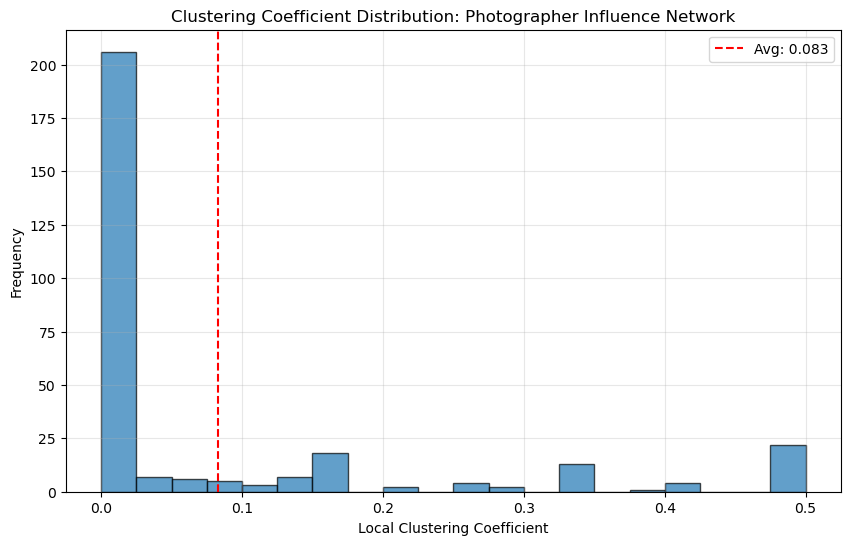

In [7]:
# Código para generar la gráfica (ejecutar localmente):
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('red_fotografos_relaciones_final_con_fechas.csv')
G = nx.DiGraph()
for _, row in df.iterrows():
    G.add_edge(row['Influenciado'], row['Influenciador'])

# Calcular clustering por nodo
clustering = nx.clustering(G)
avg_clustering = nx.average_clustering(G)

# Histograma
plt.figure(figsize=(10,6))
plt.hist(list(clustering.values()), bins=20, edgecolor='black', alpha=0.7)
plt.axvline(avg_clustering, color='red', linestyle='--', label=f'Avg: {avg_clustering:.3f}')
plt.xlabel('Local Clustering Coefficient')
plt.ylabel('Frequency')
plt.title('Clustering Coefficient Distribution: Photographer Influence Network')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('clustering_coefficient.png', dpi=300, bbox_inches='tight')
plt.show()

## Clustering Coefficient vs Degree\nPhotographer Influence Network

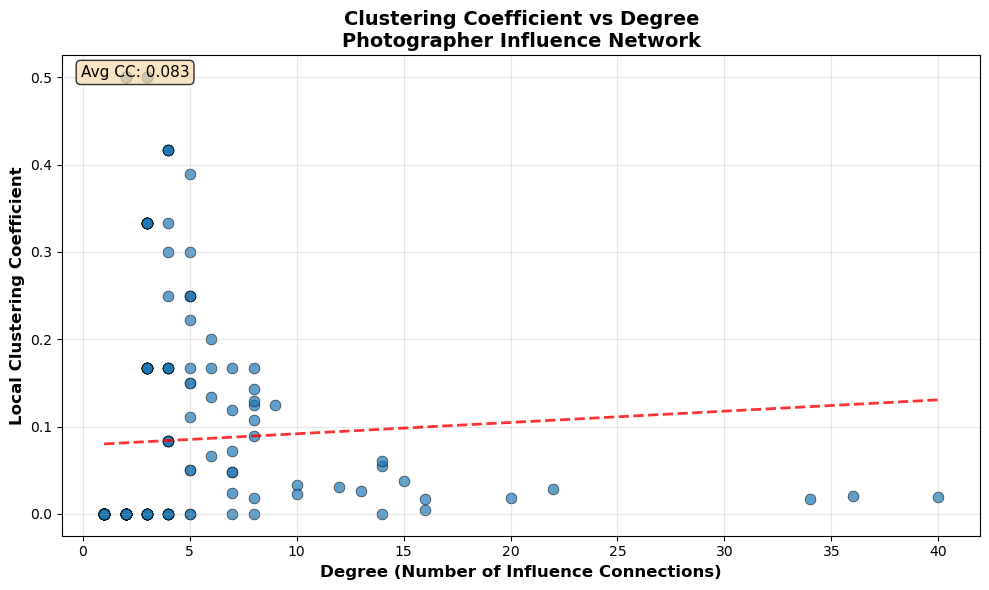

=== RESUMEN ===
Nodos: 300
Aristas: 484
Grado promedio: 3.23
Clustering promedio: 0.083

Top 5 fotógrafos por grado:
              Photographer  Degree  Clustering_Coefficient
0    Henri Cartier-Bresson      40                0.019255
52          Daidō Moriyama      36                0.020635
6            William Klein      34                0.016934
213        Masahisa Fukase      22                0.028139
21            Robert Frank      20                0.018421


In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Cargar datos
df = pd.read_csv('red_fotografos_relaciones_final_con_fechas.csv')

# Construir grafo dirigido
G = nx.DiGraph()
for _, row in df.iterrows():
    G.add_edge(row['Influenciado'], row['Influenciador'])

# Calcular métricas por nodo
degrees = dict(G.degree())
clustering = nx.clustering(G)

# Crear DataFrame con resultados
results = []
for node in G.nodes():
    results.append({
        'Photographer': node,
        'Degree': degrees[node],
        'Clustering_Coefficient': clustering[node]
    })
df_results = pd.DataFrame(results)

# Ordenar por grado
df_results = df_results.sort_values('Degree')

# Crear la gráfica en el estilo del ejemplo
plt.figure(figsize=(10, 6))
plt.scatter(df_results['Degree'], df_results['Clustering_Coefficient'], 
           s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

# Línea de tendencia
z = np.polyfit(df_results['Degree'], df_results['Clustering_Coefficient'], 1)
p = np.poly1d(z)
plt.plot(df_results['Degree'], p(df_results['Degree']), "r--", alpha=0.8, linewidth=2)

plt.xlabel('Degree (Number of Influence Connections)', fontsize=12, fontweight='bold')
plt.ylabel('Local Clustering Coefficient', fontsize=12, fontweight='bold')
plt.title('Clustering Coefficient vs Degree\nPhotographer Influence Network', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Estadísticas en la gráfica
avg_cc = df_results['Clustering_Coefficient'].mean()
plt.text(0.02, 0.98, f'Avg CC: {avg_cc:.3f}', transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('clustering_vs_degree_photographers.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== RESUMEN ===")
print(f"Nodos: {len(G.nodes())}")
print(f"Aristas: {len(G.edges())}")
print(f"Grado promedio: {np.mean(list(degrees.values())):.2f}")
print(f"Clustering promedio: {avg_cc:.3f}")
print("\nTop 5 fotógrafos por grado:")
print(df_results.nlargest(5, 'Degree')[['Photographer', 'Degree', 'Clustering_Coefficient']])

## Número de fotógrafos por Movimiento

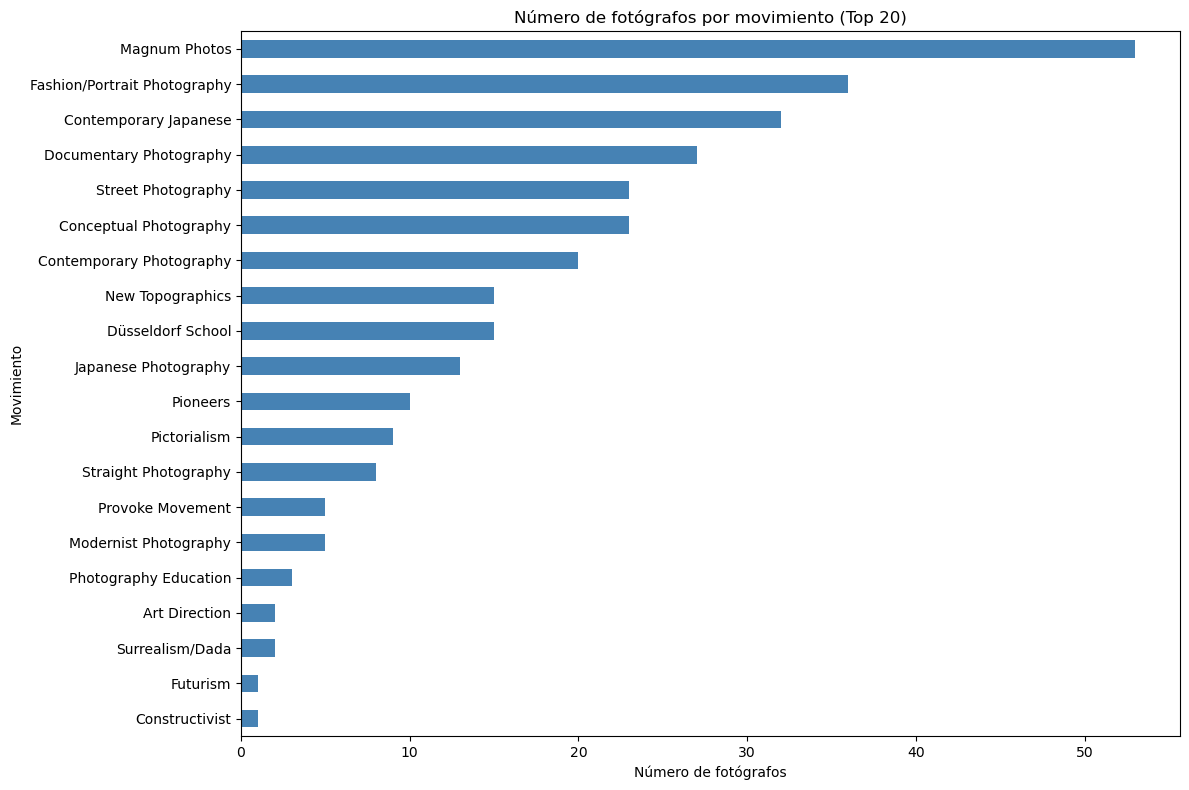

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
TOP_N = 20  # número de movimientos a mostrar

df = pd.read_csv(ARCHIVO_CSV)

# Normalizar texto
for col in ['Influenciador', 'Influenciado', 'Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# Crear una tabla unificada movimiento-fotógrafo
df_influenciador = df[['Influenciador', 'Movimiento_Influenciador']].rename(
    columns={'Influenciador': 'Fotografo', 'Movimiento_Influenciador': 'Movimiento'}
)
df_influenciado = df[['Influenciado', 'Movimiento_Influenciado']].rename(
    columns={'Influenciado': 'Fotografo', 'Movimiento_Influenciado': 'Movimiento'}
)

mov_fot = pd.concat([df_influenciador, df_influenciado], ignore_index=True)

# Eliminar duplicados fotógrafo-movimiento
mov_fot = mov_fot.drop_duplicates()

# Contar fotógrafos únicos por movimiento
conteo = (
    mov_fot.groupby('Movimiento')['Fotografo']
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N)
)

# Graficar
plt.figure(figsize=(12, 8))
conteo.sort_values().plot(kind='barh', color='steelblue')

plt.title(f'Número de fotógrafos por movimiento (Top {TOP_N})')
plt.xlabel('Número de fotógrafos')
plt.ylabel('Movimiento')
plt.tight_layout()
plt.show()

## Los diez más conectados

In [10]:
import pandas as pd
import networkx as nx

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
TOP_N = 10

df = pd.read_csv(ARCHIVO_CSV)

# Limpiar texto
for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# Crear grafo dirigido
G = nx.DiGraph()

for _, row in df.iterrows():
    G.add_edge(row['Influenciador'], row['Influenciado'])

# Calcular grado total, grado de entrada y grado de salida
resultados = []
for nodo in G.nodes():
    resultados.append({
        'Fotografo': nodo,
        'Grado': G.degree(nodo),
        'Grado_entrada': G.in_degree(nodo),
        'Grado_salida': G.out_degree(nodo)
    })

# Ordenar y mostrar top 10
top_10 = (
    pd.DataFrame(resultados)
    .sort_values(by=['Grado', 'Grado_entrada', 'Grado_salida'], ascending=False)
    .head(TOP_N)
)

print(top_10.to_string(index=False))

            Fotografo  Grado  Grado_entrada  Grado_salida
Henri Cartier-Bresson     40              3            37
       Daidō Moriyama     36              6            30
        William Klein     34              7            27
      Masahisa Fukase     22              3            19
         Robert Frank     20              2            18
          Irving Penn     16              3            13
         Bernd Becher     16              1            15
        Stephen Shore     15              3            12
            Alec Soth     14             14             0
         Walker Evans     14              2            12


## Cumulative degree distribution 

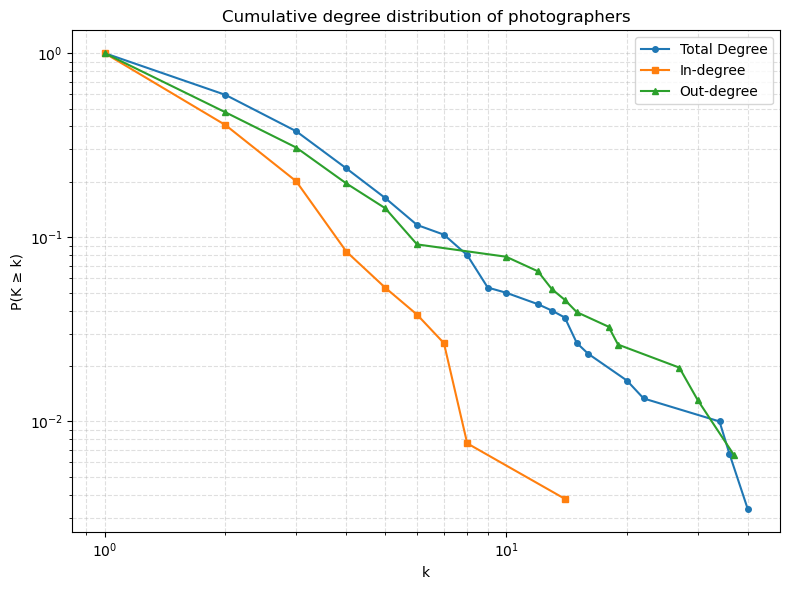

In [11]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'

df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# Grafo dirigido
G = nx.DiGraph()
for _, row in df.iterrows():
    G.add_edge(row['Influenciador'], row['Influenciado'])

def ccdf(valores):
    valores = np.array([v for v in valores if v > 0])
    valores = np.sort(valores)
    k_unicos = np.unique(valores)
    p = np.array([(valores >= k).mean() for k in k_unicos])
    return k_unicos, p

grado_total = [G.degree(n) for n in G.nodes()]
grado_entrada = [G.in_degree(n) for n in G.nodes()]
grado_salida = [G.out_degree(n) for n in G.nodes()]

k_total, p_total = ccdf(grado_total)
k_in, p_in = ccdf(grado_entrada)
k_out, p_out = ccdf(grado_salida)

plt.figure(figsize=(8, 6))

plt.loglog(k_total, p_total, 'o-', label='Total Degree', markersize=4)
plt.loglog(k_in, p_in, 's-', label='In-degree', markersize=4)
plt.loglog(k_out, p_out, '^-', label='Out-degree', markersize=4)

plt.xlabel('k')
plt.ylabel('P(K ≥ k)')
plt.title('Cumulative degree distribution of photographers')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Average degree knn of nearest neighbors of vertices with degree k (full circles) and clustering coeﬃcient Ck (full triangles) vs. k for the photographers network

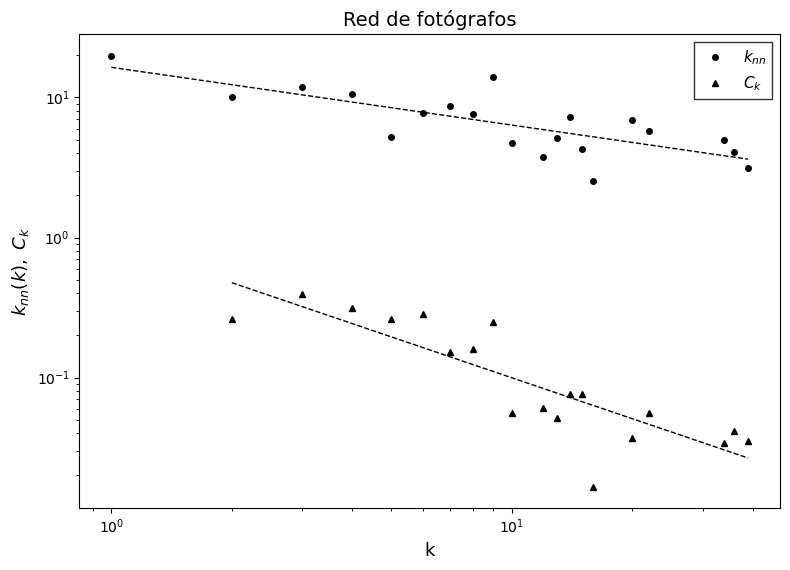


AJUSTES LOG-LOG
k_nn ~ k^(-0.412)
C_k ~ k^(-0.970)

CSV guardado en: knn_ck_por_grado.csv
Figura guardada en: knn_ck_fotografos.png


In [12]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA_CSV = 'knn_ck_por_grado.csv'
ARCHIVO_SALIDA_FIG = 'knn_ck_fotografos.png'

# -------------------------------------------------------------------
# 1. Leer datos y construir red
# -------------------------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# Red dirigida original
Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

# Para este análisis se usa versión no dirigida,
# como en la figura de referencia
G = Gd.to_undirected()

# -------------------------------------------------------------------
# 2. Calcular métricas por nodo
# -------------------------------------------------------------------
grados = dict(G.degree())
clustering = nx.clustering(G)
knn = nx.average_neighbor_degree(G)

datos = []
for nodo, k in grados.items():
    if k > 0:
        datos.append({
            'fotografo': nodo,
            'k': k,
            'knn': knn[nodo],
            'Ck': clustering[nodo]
        })

datos = pd.DataFrame(datos)

# -------------------------------------------------------------------
# 3. Promedio por clase de grado
# -------------------------------------------------------------------
agg = (
    datos.groupby('k', as_index=False)
    .agg(
        knn_mean=('knn', 'mean'),
        Ck_mean=('Ck', 'mean'),
        n=('fotografo', 'count')
    )
)

agg = agg.sort_values('k')
agg.to_csv(ARCHIVO_SALIDA_CSV, index=False, encoding='utf-8-sig')

# -------------------------------------------------------------------
# 4. Ajustes lineales en escala log-log para líneas guía
# -------------------------------------------------------------------
# Ajuste para knn
mask_knn = (agg['k'] > 0) & (agg['knn_mean'] > 0)
x_knn = agg.loc[mask_knn, 'k'].values
y_knn = agg.loc[mask_knn, 'knn_mean'].values

coef_knn = np.polyfit(np.log10(x_knn), np.log10(y_knn), 1)
pend_knn, inter_knn = coef_knn
y_knn_fit = 10 ** inter_knn * x_knn ** pend_knn

# Ajuste para Ck
mask_ck = (agg['k'] > 0) & (agg['Ck_mean'] > 0)
x_ck = agg.loc[mask_ck, 'k'].values
y_ck = agg.loc[mask_ck, 'Ck_mean'].values

coef_ck = np.polyfit(np.log10(x_ck), np.log10(y_ck), 1)
pend_ck, inter_ck = coef_ck
y_ck_fit = 10 ** inter_ck * x_ck ** pend_ck

# -------------------------------------------------------------------
# 5. Gráfica
# -------------------------------------------------------------------
plt.figure(figsize=(8, 5.8))

# Puntos
plt.loglog(
    agg['k'],
    agg['knn_mean'],
    'o',
    color='black',
    markersize=4,
    label=r'$k_{nn}$'
)

plt.loglog(
    agg['k'],
    agg['Ck_mean'],
    '^',
    color='black',
    markersize=4,
    label=r'$C_k$'
)

# Líneas discontinuas guía
plt.loglog(
    x_knn,
    y_knn_fit,
    '--',
    color='black',
    linewidth=1
)

plt.loglog(
    x_ck,
    y_ck_fit,
    '--',
    color='black',
    linewidth=1
)

# Etiquetas y estilo
plt.xlabel('k', fontsize=13)
plt.ylabel(r'$k_{nn}(k),\ C_k$', fontsize=13)
plt.title('Red de fotógrafos', fontsize=14)

plt.legend(
    frameon=True,
    fancybox=False,
    edgecolor='black',
    fontsize=11,
    loc='best'
)

plt.grid(False)
plt.tight_layout()

# Guardar figura
plt.savefig(ARCHIVO_SALIDA_FIG, dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------------
# 6. Imprimir resultados del ajuste
# -------------------------------------------------------------------
print('\n' + '=' * 70)
print('AJUSTES LOG-LOG')
print('=' * 70)
print(f'k_nn ~ k^({pend_knn:.3f})')
print(f'C_k ~ k^({pend_ck:.3f})')
print(f'\nCSV guardado en: {ARCHIVO_SALIDA_CSV}')
print(f'Figura guardada en: {ARCHIVO_SALIDA_FIG}')

## Community structure of the photographers network

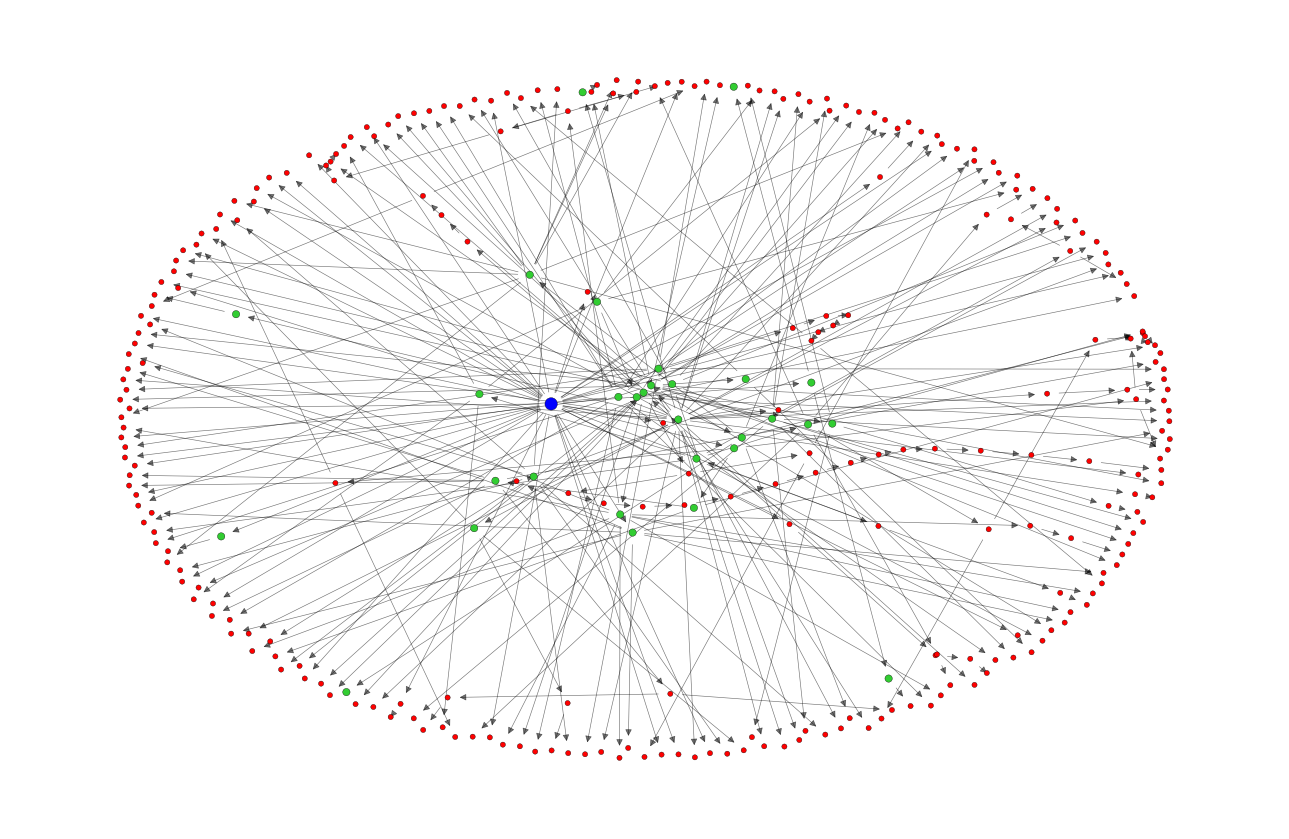

ESTRUCTURA TIPO COMUNIDAD DE LA RED DE FOTÓGRAFOS
Raíz del árbol: Henri Cartier-Bresson
Umbral de grado alto: 7
Número de nodos en la red: 300
Número de aristas en la red: 480
Número de nodos en el árbol BFS: 298
Figura guardada en: estructura_comunidad_fotografos.png


In [13]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'estructura_comunidad_fotografos.png'

# --------------------------------------------------
# 1. Leer datos y construir la red
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# Red dirigida original
Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

# Para esta visualización, usamos la red no dirigida
G = Gd.to_undirected()

# --------------------------------------------------
# 2. Elegir raíz y construir árbol derivado
# --------------------------------------------------
# Tomamos como raíz el nodo con mayor grado
root = max(G.degree, key=lambda x: x[1])[0]

# Árbol BFS desde la raíz
T = nx.bfs_tree(G, source=root)

# --------------------------------------------------
# 3. Determinar nodos "importantes"
# --------------------------------------------------
deg = dict(G.degree())

# Umbral: top 10% de grados
grados_ordenados = sorted(deg.values(), reverse=True)
idx = max(1, math.ceil(len(grados_ordenados) * 0.10)) - 1
threshold = grados_ordenados[idx]

# --------------------------------------------------
# 4. Layout
# --------------------------------------------------
# spring layout sobre el árbol para obtener una forma orgánica
pos = nx.spring_layout(T, seed=42, k=0.35, iterations=300)

# --------------------------------------------------
# 5. Colores y tamaños
# --------------------------------------------------
node_colors = []
node_sizes = []

for n in T.nodes():
    if n == root:
        node_colors.append('blue')
        node_sizes.append(80)
    elif deg[n] >= threshold:
        node_colors.append('limegreen')
        node_sizes.append(28)
    else:
        node_colors.append('red')
        node_sizes.append(14)

# --------------------------------------------------
# 6. Dibujar
# --------------------------------------------------
plt.figure(figsize=(13, 8.5))

nx.draw_networkx_edges(
    T,
    pos,
    edge_color='black',
    width=0.45,
    alpha=0.55
)

nx.draw_networkx_nodes(
    T,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='black',
    linewidths=0.25
)

plt.axis('off')
plt.tight_layout()
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 7. Información en consola
# --------------------------------------------------
print("=" * 70)
print("ESTRUCTURA TIPO COMUNIDAD DE LA RED DE FOTÓGRAFOS")
print("=" * 70)
print(f"Raíz del árbol: {root}")
print(f"Umbral de grado alto: {threshold}")
print(f"Número de nodos en la red: {G.number_of_nodes()}")
print(f"Número de aristas en la red: {G.number_of_edges()}")
print(f"Número de nodos en el árbol BFS: {T.number_of_nodes()}")
print(f"Figura guardada en: {ARCHIVO_SALIDA}")

En esta figura, el nodo azul es la raíz del árbol, escogido como el fotógrafo con mayor grado en la red no dirigida. Los nodos verdes son los fotógrafos con grado alto, definidos aquí como el 10% superior de la distribución de grados, y los rojos son el resto.

Ajustes útiles
Si la quieres más parecida al ejemplo, puedes tocar tres cosas:

k=0.35 en spring_layout: valores más altos estiran más el árbol.

El umbral del 10%: puedes cambiarlo a 5% para marcar menos hubs.

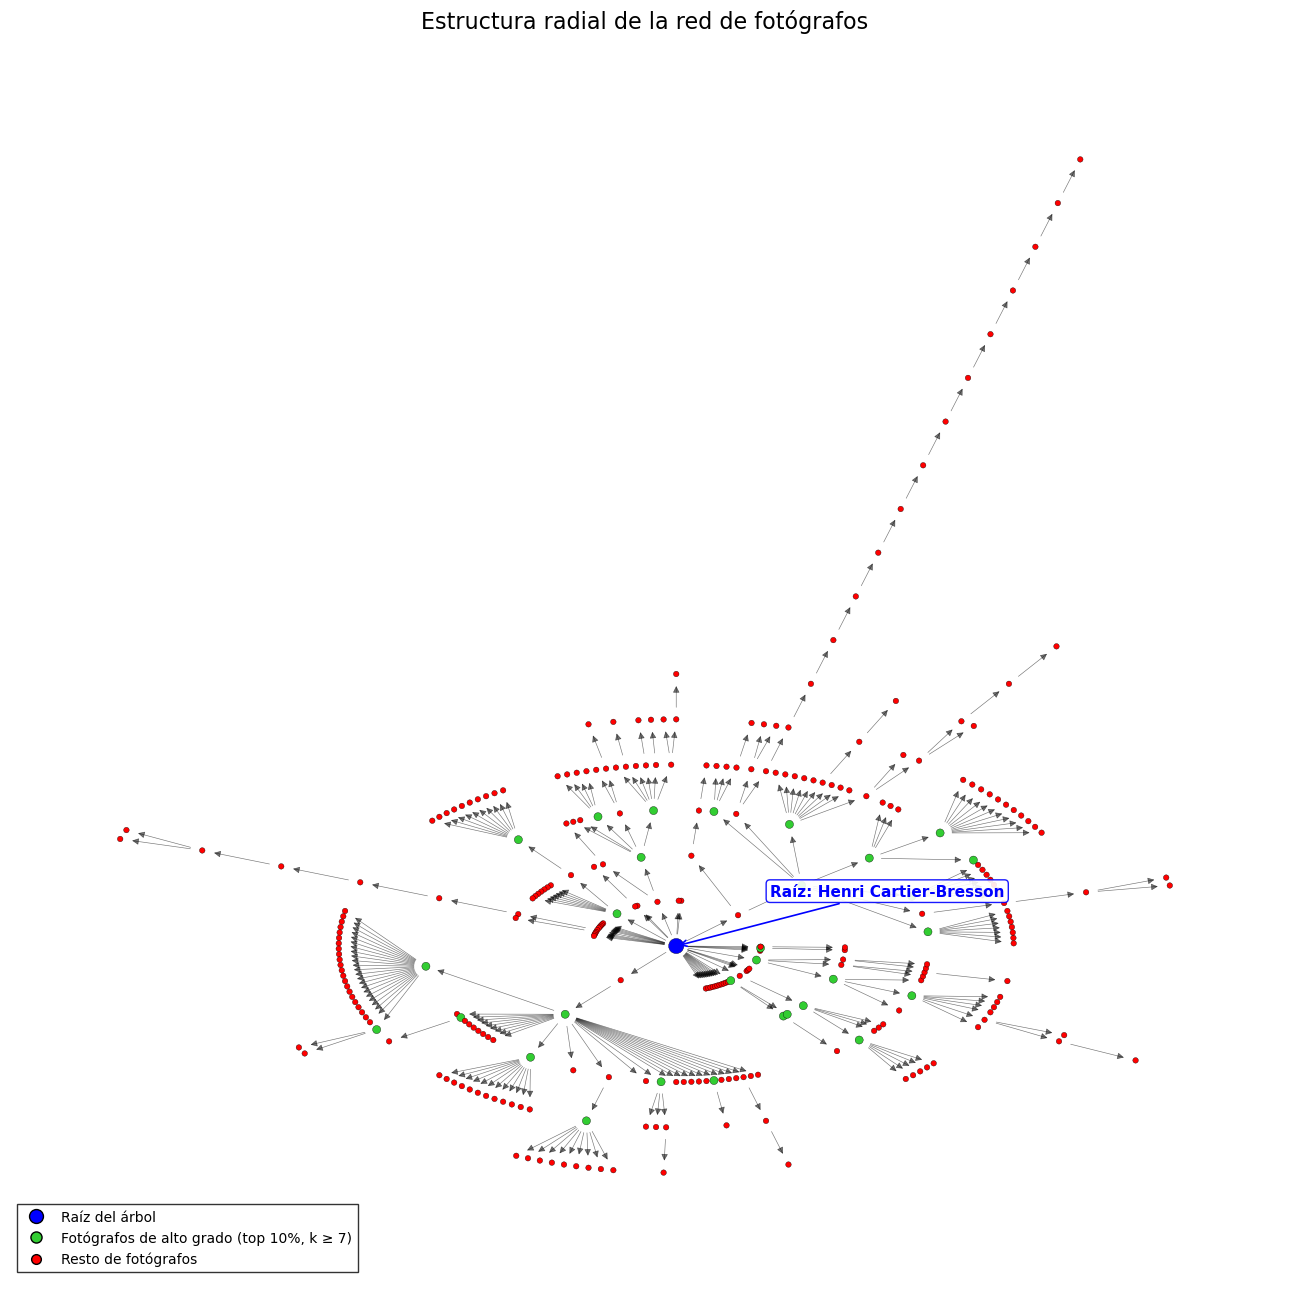

ESTRUCTURA RADIAL / JERÁRQUICA CON LEYENDA
Raíz: Henri Cartier-Bresson
Umbral de alto grado: 7
Nodos en la red: 300
Aristas en la red: 480
Nodos en el árbol BFS: 298
Archivo guardado en: estructura_comunidad_fotografos_radial_legend.png


In [14]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

# Intenta primero con PyGraphviz; si no está disponible, prueba pydot
try:
    from networkx.drawing.nx_agraph import graphviz_layout
except ImportError:
    from networkx.drawing.nx_pydot import graphviz_layout

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'estructura_comunidad_fotografos_radial_legend.png'

# --------------------------------------------------
# 1. Leer datos
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# --------------------------------------------------
# 2. Construir red
# --------------------------------------------------
Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

# Red no dirigida para esta visualización
G = Gd.to_undirected()

# --------------------------------------------------
# 3. Elegir raíz y árbol BFS
# --------------------------------------------------
root = max(G.degree, key=lambda x: x[1])[0]
T = nx.bfs_tree(G, source=root)

# --------------------------------------------------
# 4. Re-etiquetar nodos a enteros para Graphviz
# --------------------------------------------------
mapping = {node: i for i, node in enumerate(T.nodes())}
reverse_mapping = {i: node for node, i in mapping.items()}

T_int = nx.relabel_nodes(T, mapping)
root_int = mapping[root]

# --------------------------------------------------
# 5. Nodos destacados
# --------------------------------------------------
deg = dict(G.degree())

grados_ordenados = sorted(deg.values(), reverse=True)
idx = max(1, math.ceil(len(grados_ordenados) * 0.10)) - 1
threshold = grados_ordenados[idx]

# --------------------------------------------------
# 6. Layout radial con Graphviz (twopi)
# --------------------------------------------------
pos_int = graphviz_layout(T_int, prog='twopi', root=root_int)
pos = {reverse_mapping[n]: coords for n, coords in pos_int.items()}

# --------------------------------------------------
# 7. Colores y tamaños
# --------------------------------------------------
node_colors = []
node_sizes = []

for n in T.nodes():
    if n == root:
        node_colors.append('blue')
        node_sizes.append(120)
    elif deg[n] >= threshold:
        node_colors.append('limegreen')
        node_sizes.append(34)
    else:
        node_colors.append('red')
        node_sizes.append(16)

# --------------------------------------------------
# 8. Dibujar
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 13))

nx.draw_networkx_edges(
    T,
    pos,
    ax=ax,
    edge_color='black',
    width=0.45,
    alpha=0.55
)

nx.draw_networkx_nodes(
    T,
    pos,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='black',
    linewidths=0.25
)

# --------------------------------------------------
# 9. Etiqueta de la raíz
# --------------------------------------------------
x_root, y_root = pos[root]

ax.annotate(
    f'Raíz: {root}',
    xy=(x_root, y_root),
    xytext=(x_root + 80, y_root + 80),
    fontsize=11,
    color='blue',
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color='blue',
        lw=1.2
    ),
    bbox=dict(
        boxstyle='round,pad=0.25',
        fc='white',
        ec='blue',
        alpha=0.9
    )
)

# --------------------------------------------------
# 10. Leyenda incrustada
# --------------------------------------------------
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Raíz del árbol',
        markerfacecolor='blue',
        markeredgecolor='black',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=f'Fotógrafos de alto grado (top 10%, k ≥ {threshold})',
        markerfacecolor='limegreen',
        markeredgecolor='black',
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='Resto de fotógrafos',
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=7
    )
]

ax.legend(
    handles=legend_elements,
    loc='lower left',
    frameon=True,
    fancybox=False,
    edgecolor='black',
    fontsize=10
)

# --------------------------------------------------
# 11. Título y pie
# --------------------------------------------------
ax.set_title(
    'Estructura radial de la red de fotógrafos',
    fontsize=16,
    pad=18
)



ax.set_axis_off()
plt.tight_layout()
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 12. Resumen
# --------------------------------------------------
print("=" * 72)
print("ESTRUCTURA RADIAL / JERÁRQUICA CON LEYENDA")
print("=" * 72)
print(f"Raíz: {root}")
print(f"Umbral de alto grado: {threshold}")
print(f"Nodos en la red: {G.number_of_nodes()}")
print(f"Aristas en la red: {G.number_of_edges()}")
print(f"Nodos en el árbol BFS: {T.number_of_nodes()}")
print(f"Archivo guardado en: {ARCHIVO_SALIDA}")

        'Raíz en azul; fotógrafos de grado alto en verde; resto en rojo. '
        'Árbol BFS sobre la red no dirigida derivada de relaciones de influencia.'

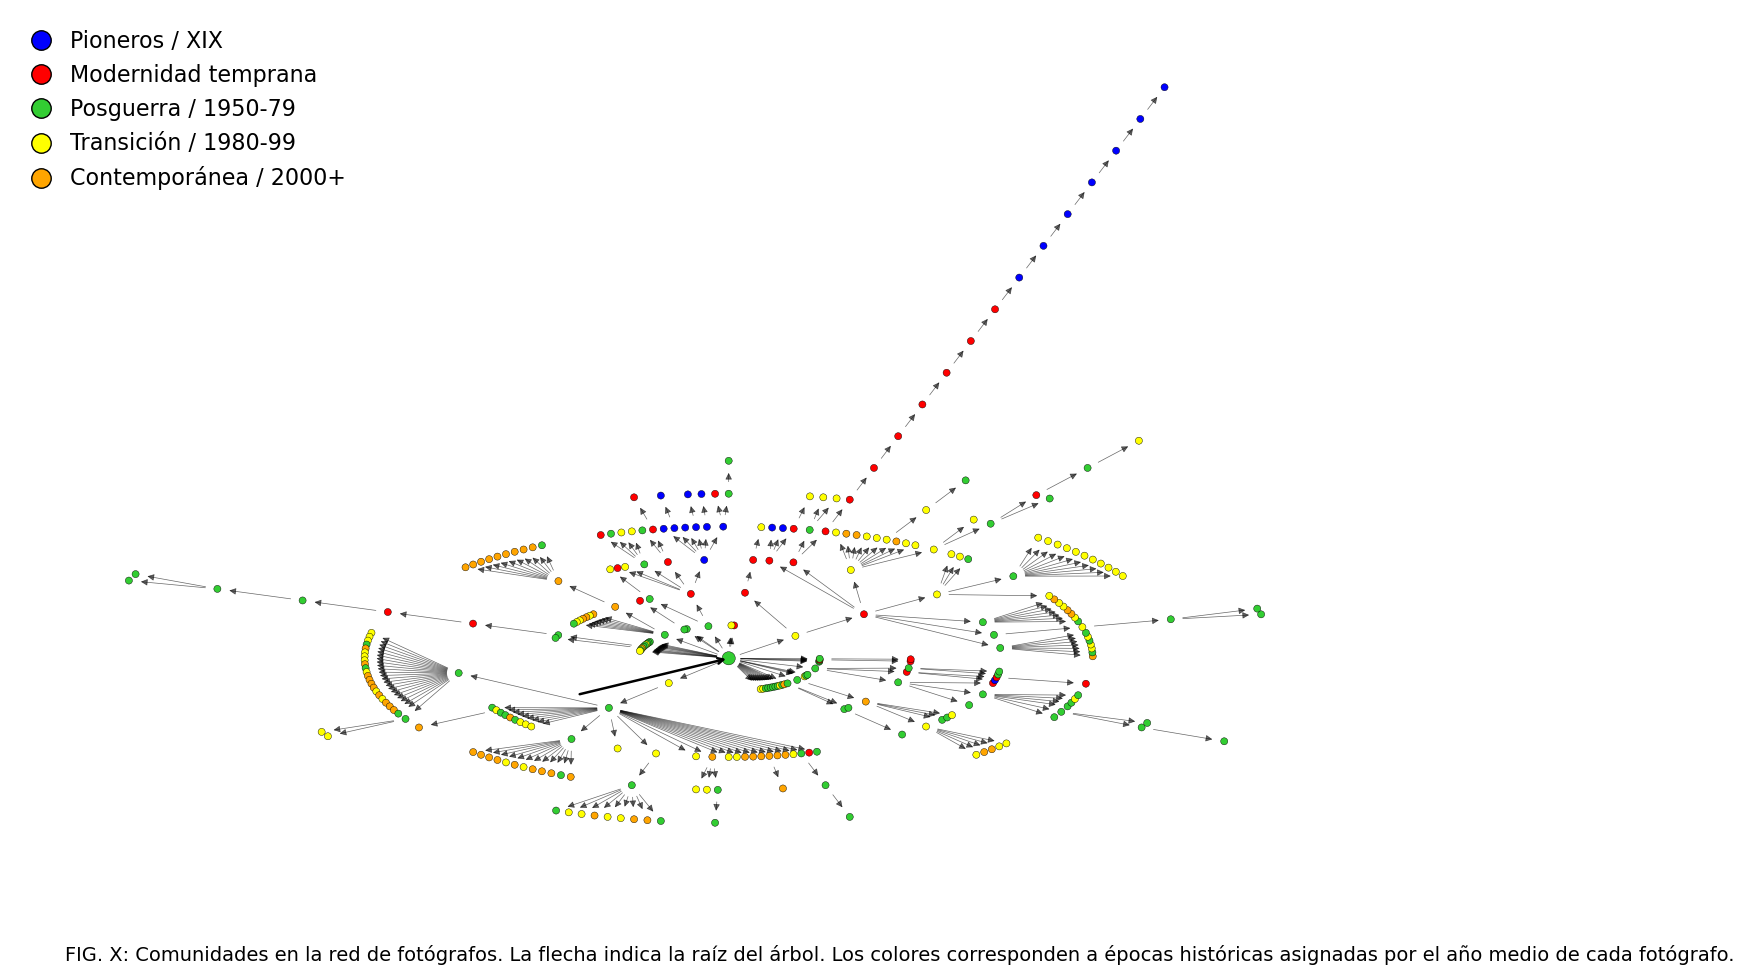

Raíz: Henri Cartier-Bresson
Figura guardada en: comunidades_fotografos_epocas.png


In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    from networkx.drawing.nx_agraph import graphviz_layout
except ImportError:
    from networkx.drawing.nx_pydot import graphviz_layout

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'comunidades_fotografos_epocas.png'

# --------------------------------------------------
# 1. Leer CSV
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado', 'Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

for col in ['Año_Influenciador', 'Año_Influenciado']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --------------------------------------------------
# 2. Construir red
# --------------------------------------------------
Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

G = Gd.to_undirected()

# --------------------------------------------------
# 3. Año representativo por fotógrafo
# --------------------------------------------------
foto_anios = {}

for _, row in df.iterrows():
    inf = row['Influenciador']
    ind = row['Influenciado']
    a_inf = row['Año_Influenciador']
    a_ind = row['Año_Influenciado']

    foto_anios.setdefault(inf, []).append(a_inf)
    foto_anios.setdefault(ind, []).append(a_ind)

anio_fotografo = {}
for foto, anios in foto_anios.items():
    anios_validos = [a for a in anios if pd.notna(a)]
    if anios_validos:
        anio_fotografo[foto] = int(round(sum(anios_validos) / len(anios_validos)))
    else:
        anio_fotografo[foto] = None

# --------------------------------------------------
# 4. Clasificación por épocas
# --------------------------------------------------
def clasificar_epoca(anio):
    if anio is None:
        return 'Sin fecha'
    if anio < 1900:
        return 'Pioneros / XIX'
    elif anio < 1950:
        return 'Modernidad temprana'
    elif anio < 1980:
        return 'Posguerra / 1950-79'
    elif anio < 2000:
        return 'Transición / 1980-99'
    else:
        return 'Contemporánea / 2000+'

colores_epoca = {
    'Pioneros / XIX': 'blue',
    'Modernidad temprana': 'red',
    'Posguerra / 1950-79': 'limegreen',
    'Transición / 1980-99': 'yellow',
    'Contemporánea / 2000+': 'orange',
    'Sin fecha': 'lightgray'
}

# --------------------------------------------------
# 5. Elegir raíz y árbol BFS
# --------------------------------------------------
root = max(G.degree, key=lambda x: x[1])[0]
T = nx.bfs_tree(G, source=root)

# --------------------------------------------------
# 6. Re-etiquetar a enteros para Graphviz
# --------------------------------------------------
mapping = {node: i for i, node in enumerate(T.nodes())}
reverse_mapping = {i: node for node, i in mapping.items()}

T_int = nx.relabel_nodes(T, mapping)
root_int = mapping[root]

pos_int = graphviz_layout(T_int, prog='twopi', root=root_int)
pos = {reverse_mapping[n]: coords for n, coords in pos_int.items()}

# --------------------------------------------------
# 7. Colores y tamaños
# --------------------------------------------------
node_colors = []
node_sizes = []

for n in T.nodes():
    epoca = clasificar_epoca(anio_fotografo.get(n))
    node_colors.append(colores_epoca[epoca])

    if n == root:
        node_sizes.append(90)
    else:
        node_sizes.append(26)

# --------------------------------------------------
# 8. Dibujar
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

nx.draw_networkx_edges(
    T,
    pos,
    ax=ax,
    edge_color='black',
    width=0.5,
    alpha=0.6
)

nx.draw_networkx_nodes(
    T,
    pos,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='black',
    linewidths=0.3
)

# Flecha a la raíz
x_root, y_root = pos[root]
ax.annotate(
    '',
    xy=(x_root, y_root),
    xytext=(x_root - 120, y_root - 80),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.8)
)

# --------------------------------------------------
# 9. Leyenda
# --------------------------------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Pioneros / XIX',
           markerfacecolor='blue', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Modernidad temprana',
           markerfacecolor='red', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Posguerra / 1950-79',
           markerfacecolor='limegreen', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Transición / 1980-99',
           markerfacecolor='yellow', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='Contemporánea / 2000+',
           markerfacecolor='orange', markeredgecolor='black', markersize=14),
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    frameon=False,
    fontsize=16,
    handlelength=1
)

# --------------------------------------------------
# 10. Pie de figura
# --------------------------------------------------
fig.text(
    0.05, 0.03,
    (
        'FIG. X: Comunidades en la red de fotógrafos. '
        'La flecha indica la raíz del árbol. '
        'Los colores corresponden a épocas históricas asignadas por el año medio de cada fotógrafo.'
    ),
    ha='left',
    va='bottom',
    fontsize=14
)

ax.set_axis_off()
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

print(f'Raíz: {root}')
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

### Versión simple
versión por movimientos simplificados, pensada para que se parezca a la figura de ejemplo del paper de jazz: árbol radial, leyenda grande dentro de la figura, flecha a la raíz y colores por familias de movimiento en lugar de zonas. Tu CSV ya contiene suficientes etiquetas para reagruparlas en unas pocas familias legibles.

Criterio de agrupación
COlapsados en 6 familias visuales para que la leyenda no explote. En el CSV aparecen etiquetas como Magnum Photos, Street Photography, Documentary Photography, Provoke Movement, Japanese Photography, Contemporary Japanese, Conceptual Photography, Düsseldorf School, New Topographics, Fashion/Portrait Photography y Pioneers, así que esas se pueden reagrupar con bastante limpieza.

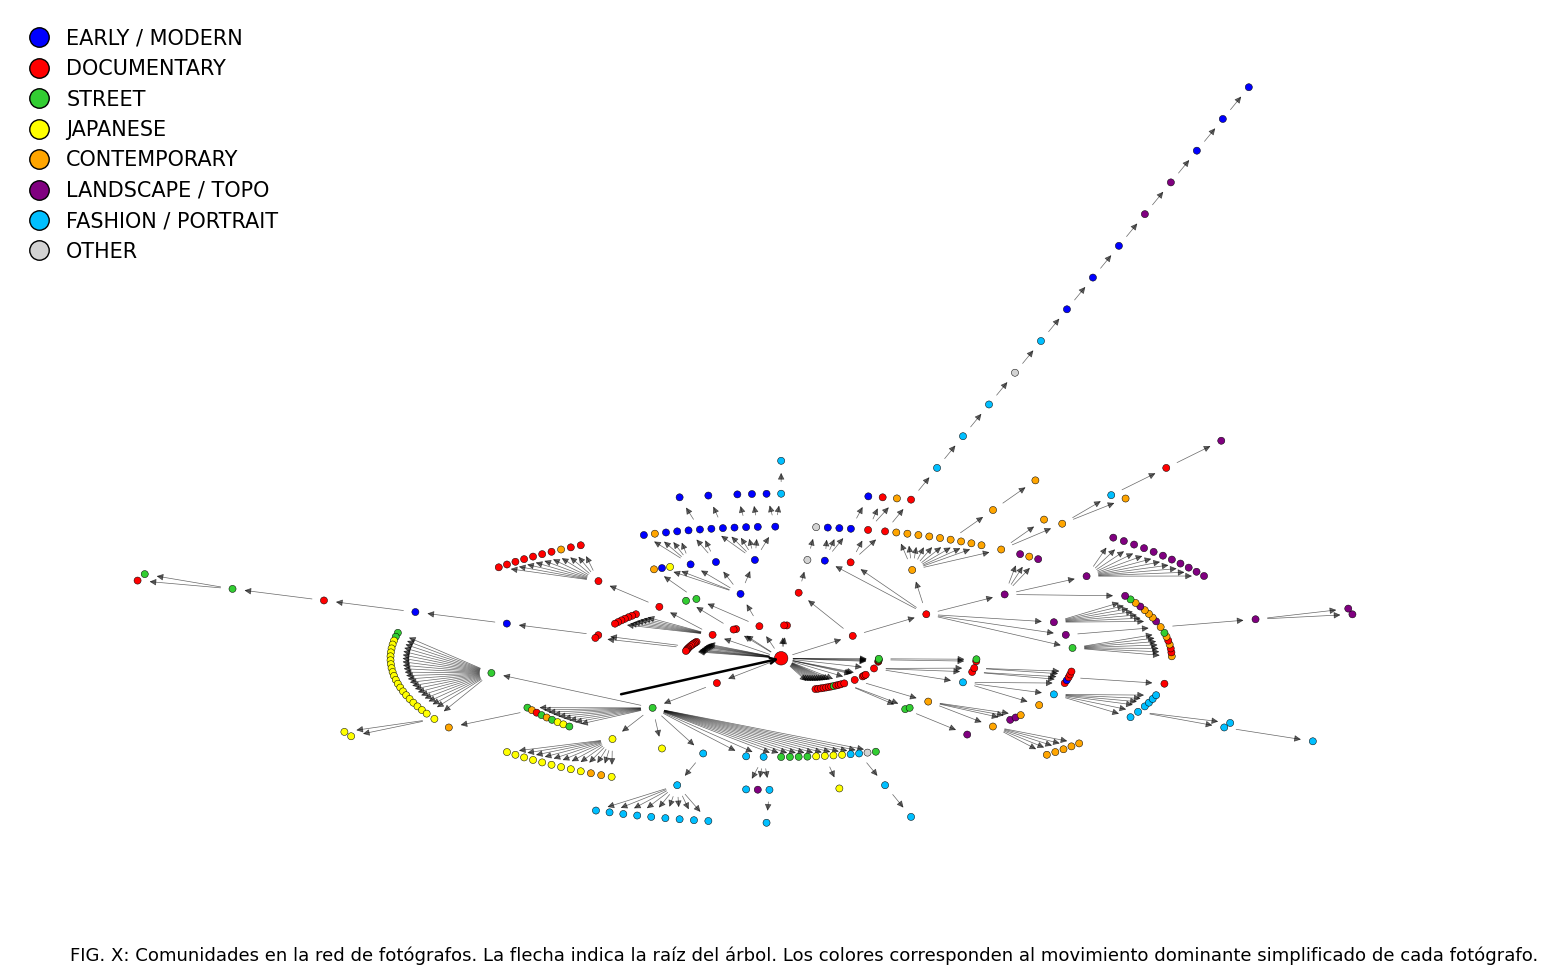

Raíz: Henri Cartier-Bresson
Figura guardada en: comunidades_fotografos_movimientos.png


In [16]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import Counter

try:
    from networkx.drawing.nx_agraph import graphviz_layout
except ImportError:
    from networkx.drawing.nx_pydot import graphviz_layout

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'comunidades_fotografos_movimientos.png'

# --------------------------------------------------
# 1. Leer CSV
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado', 'Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# --------------------------------------------------
# 2. Construir red
# --------------------------------------------------
Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

G = Gd.to_undirected()

# --------------------------------------------------
# 3. Simplificar movimientos
# --------------------------------------------------
def simplificar_movimiento(m):
    m = str(m).strip()

    if m in ['Pioneers', 'Pictorialism', 'Straight Photography', 'Modernist Photography', 'Photography Education']:
        return 'EARLY / MODERN'

    elif m in ['Documentary Photography', 'Social Documentary', 'FSA/Documentary', 'Documentary Portrait',
               'Documentary/Street', 'Photojournalism', 'Poetic Documentary', 'War Photography',
               'Humanist Photography', 'Magnum Photos']:
        return 'DOCUMENTARY'

    elif m in ['Street Photography', 'Provoke Movement', 'Japanese Street Photography']:
        return 'STREET'

    elif m in ['Japanese Photography', 'Contemporary Japanese', 'Japanese Contemporary']:
        return 'JAPANESE'

    elif m in ['Conceptual Photography', 'Conceptual Art', 'Postmodern Photography',
               'Post-Internet Photography', 'Staged Photography', 'Fine Art Photography',
               'Contemporary Art', 'Contemporary Photography', 'Contemporary/Digital',
               'Contemporary Documentary', 'Contemporary Portrait', 'Contemporary Landscape',
               'Contemporary Public Art']:
        return 'CONTEMPORARY'

    elif m in ['New Topographics', 'Düsseldorf School', 'Color Photography', 'Landscape Photography',
               'Group f/64']:
        return 'LANDSCAPE / TOPO'

    elif m in ['Fashion Photography', 'Fashion/Portrait Photography', 'Portrait Photography', 'Art Direction']:
        return 'FASHION / PORTRAIT'

    else:
        return 'OTHER'

# --------------------------------------------------
# 4. Movimiento dominante por fotógrafo
# --------------------------------------------------
foto_movs = {}

for _, row in df.iterrows():
    inf = row['Influenciador']
    ind = row['Influenciado']
    m_inf = simplificar_movimiento(row['Movimiento_Influenciador'])
    m_ind = simplificar_movimiento(row['Movimiento_Influenciado'])

    foto_movs.setdefault(inf, []).append(m_inf)
    foto_movs.setdefault(ind, []).append(m_ind)

mov_fotografo = {}
for foto, movs in foto_movs.items():
    mov_fotografo[foto] = Counter(movs).most_common(1)[0][0]

# --------------------------------------------------
# 5. Colores
# --------------------------------------------------
colores = {
    'EARLY / MODERN': 'blue',
    'DOCUMENTARY': 'red',
    'STREET': 'limegreen',
    'JAPANESE': 'yellow',
    'CONTEMPORARY': 'orange',
    'LANDSCAPE / TOPO': 'purple',
    'FASHION / PORTRAIT': 'deepskyblue',
    'OTHER': 'lightgray'
}

# --------------------------------------------------
# 6. Elegir raíz y árbol BFS
# --------------------------------------------------
root = max(G.degree, key=lambda x: x[1])[0]
T = nx.bfs_tree(G, source=root)

# --------------------------------------------------
# 7. Re-etiquetar para Graphviz
# --------------------------------------------------
mapping = {node: i for i, node in enumerate(T.nodes())}
reverse_mapping = {i: node for node, i in mapping.items()}

T_int = nx.relabel_nodes(T, mapping)
root_int = mapping[root]

pos_int = graphviz_layout(T_int, prog='twopi', root=root_int)
pos = {reverse_mapping[n]: coords for n, coords in pos_int.items()}

# --------------------------------------------------
# 8. Colores y tamaños de nodos
# --------------------------------------------------
node_colors = []
node_sizes = []

for n in T.nodes():
    grupo = mov_fotografo.get(n, 'OTHER')
    node_colors.append(colores.get(grupo, 'lightgray'))

    if n == root:
        node_sizes.append(95)
    else:
        node_sizes.append(26)

# --------------------------------------------------
# 9. Dibujar
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 10))

nx.draw_networkx_edges(
    T,
    pos,
    ax=ax,
    edge_color='black',
    width=0.5,
    alpha=0.60
)

nx.draw_networkx_nodes(
    T,
    pos,
    ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors='black',
    linewidths=0.35
)

# Flecha a la raíz
x_root, y_root = pos[root]
ax.annotate(
    '',
    xy=(x_root, y_root),
    xytext=(x_root - 120, y_root - 80),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.8)
)

# --------------------------------------------------
# 10. Leyenda
# --------------------------------------------------
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='EARLY / MODERN',
           markerfacecolor='blue', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='DOCUMENTARY',
           markerfacecolor='red', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='STREET',
           markerfacecolor='limegreen', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='JAPANESE',
           markerfacecolor='yellow', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='CONTEMPORARY',
           markerfacecolor='orange', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='LANDSCAPE / TOPO',
           markerfacecolor='purple', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='FASHION / PORTRAIT',
           markerfacecolor='deepskyblue', markeredgecolor='black', markersize=14),
    Line2D([0], [0], marker='o', color='w', label='OTHER',
           markerfacecolor='lightgray', markeredgecolor='black', markersize=14),
]

ax.legend(
    handles=legend_elements,
    loc='upper left',
    frameon=False,
    fontsize=15,
    handlelength=1
)

# --------------------------------------------------
# 11. Pie de figura
# --------------------------------------------------
fig.text(
    0.05, 0.03,
    (
        'FIG. X: Comunidades en la red de fotógrafos. '
        'La flecha indica la raíz del árbol. '
        'Los colores corresponden al movimiento dominante simplificado de cada fotógrafo.'
    ),
    ha='left',
    va='bottom',
    fontsize=13
)

ax.set_axis_off()
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

print(f'Raíz: {root}')
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

## Community size distribution 

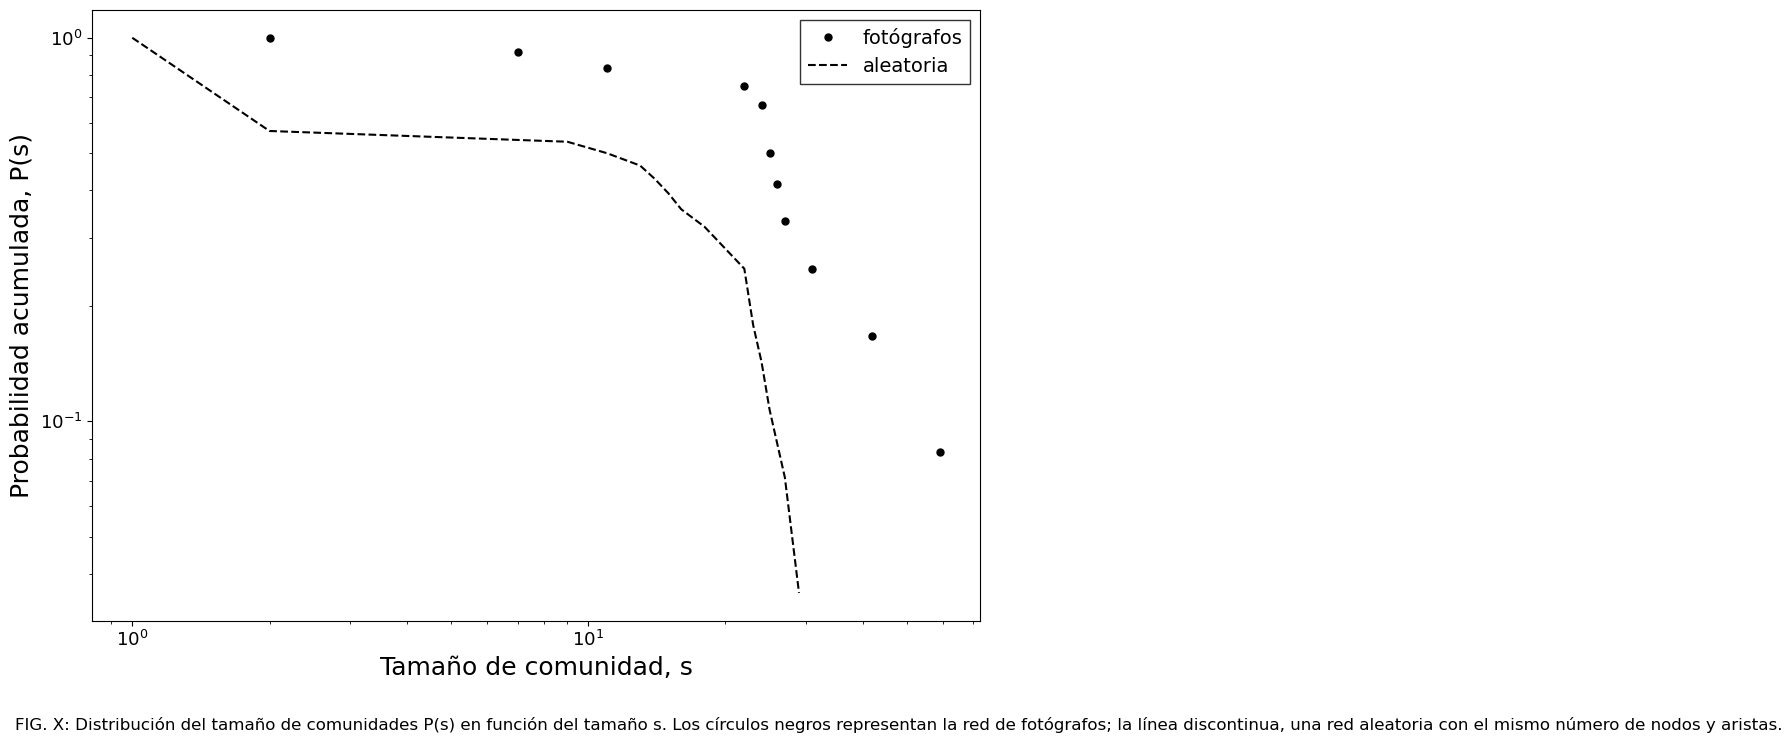

Nodos: 300
Aristas: 480
Comunidades reales: 12
Comunidades aleatorias: 28
Figura guardada en: distribucion_tamano_comunidades.png


In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'distribucion_tamano_comunidades.png'
SEED = 42

# --------------------------------------------------
# 1. Leer CSV y construir red
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

G = Gd.to_undirected()

# --------------------------------------------------
# 2. Detectar comunidades en la red real
# --------------------------------------------------
comunidades = nx.community.louvain_communities(G, seed=SEED)
sizes_real = sorted([len(c) for c in comunidades])

# --------------------------------------------------
# 3. Red aleatoria comparable
# --------------------------------------------------
n = G.number_of_nodes()
m = G.number_of_edges()

G_rand = nx.gnm_random_graph(n, m, seed=SEED)
comunidades_rand = nx.community.louvain_communities(G_rand, seed=SEED)
sizes_rand = sorted([len(c) for c in comunidades_rand])

# --------------------------------------------------
# 4. Distribución acumulada P(S >= s)
# --------------------------------------------------
def cumulative_size_distribution(sizes):
    sizes = np.array(sorted(sizes))
    unique_sizes = np.unique(sizes)

    x = []
    y = []

    total = len(sizes)
    for s in unique_sizes:
        prob = np.sum(sizes >= s) / total
        x.append(s)
        y.append(prob)

    return np.array(x), np.array(y)

x_real, y_real = cumulative_size_distribution(sizes_real)
x_rand, y_rand = cumulative_size_distribution(sizes_rand)

# --------------------------------------------------
# 5. Gráfica
# --------------------------------------------------
plt.figure(figsize=(10, 7))

plt.loglog(
    x_real, y_real,
    'o',
    color='black',
    markersize=5,
    label='fotógrafos'
)

plt.loglog(
    x_rand, y_rand,
    '--',
    color='black',
    linewidth=1.5,
    label='aleatoria'
)

plt.xlabel('Tamaño de comunidad, s', fontsize=18)
plt.ylabel('Probabilidad acumulada, P(s)', fontsize=18)
plt.legend(fontsize=14, frameon=True, fancybox=False, edgecolor='black')
plt.tick_params(axis='both', which='major', labelsize=13)
plt.tight_layout()

# Pie de figura
plt.figtext(
    0.02, -0.05,
    (
        'FIG. X: Distribución del tamaño de comunidades P(s) en función del tamaño s. '
        'Los círculos negros representan la red de fotógrafos; la línea discontinua, '
        'una red aleatoria con el mismo número de nodos y aristas.'
    ),
    ha='left',
    fontsize=12
)

plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 6. Resumen
# --------------------------------------------------
print(f'Nodos: {n}')
print(f'Aristas: {m}')
print(f'Comunidades reales: {len(sizes_real)}')
print(f'Comunidades aleatorias: {len(sizes_rand)}')
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

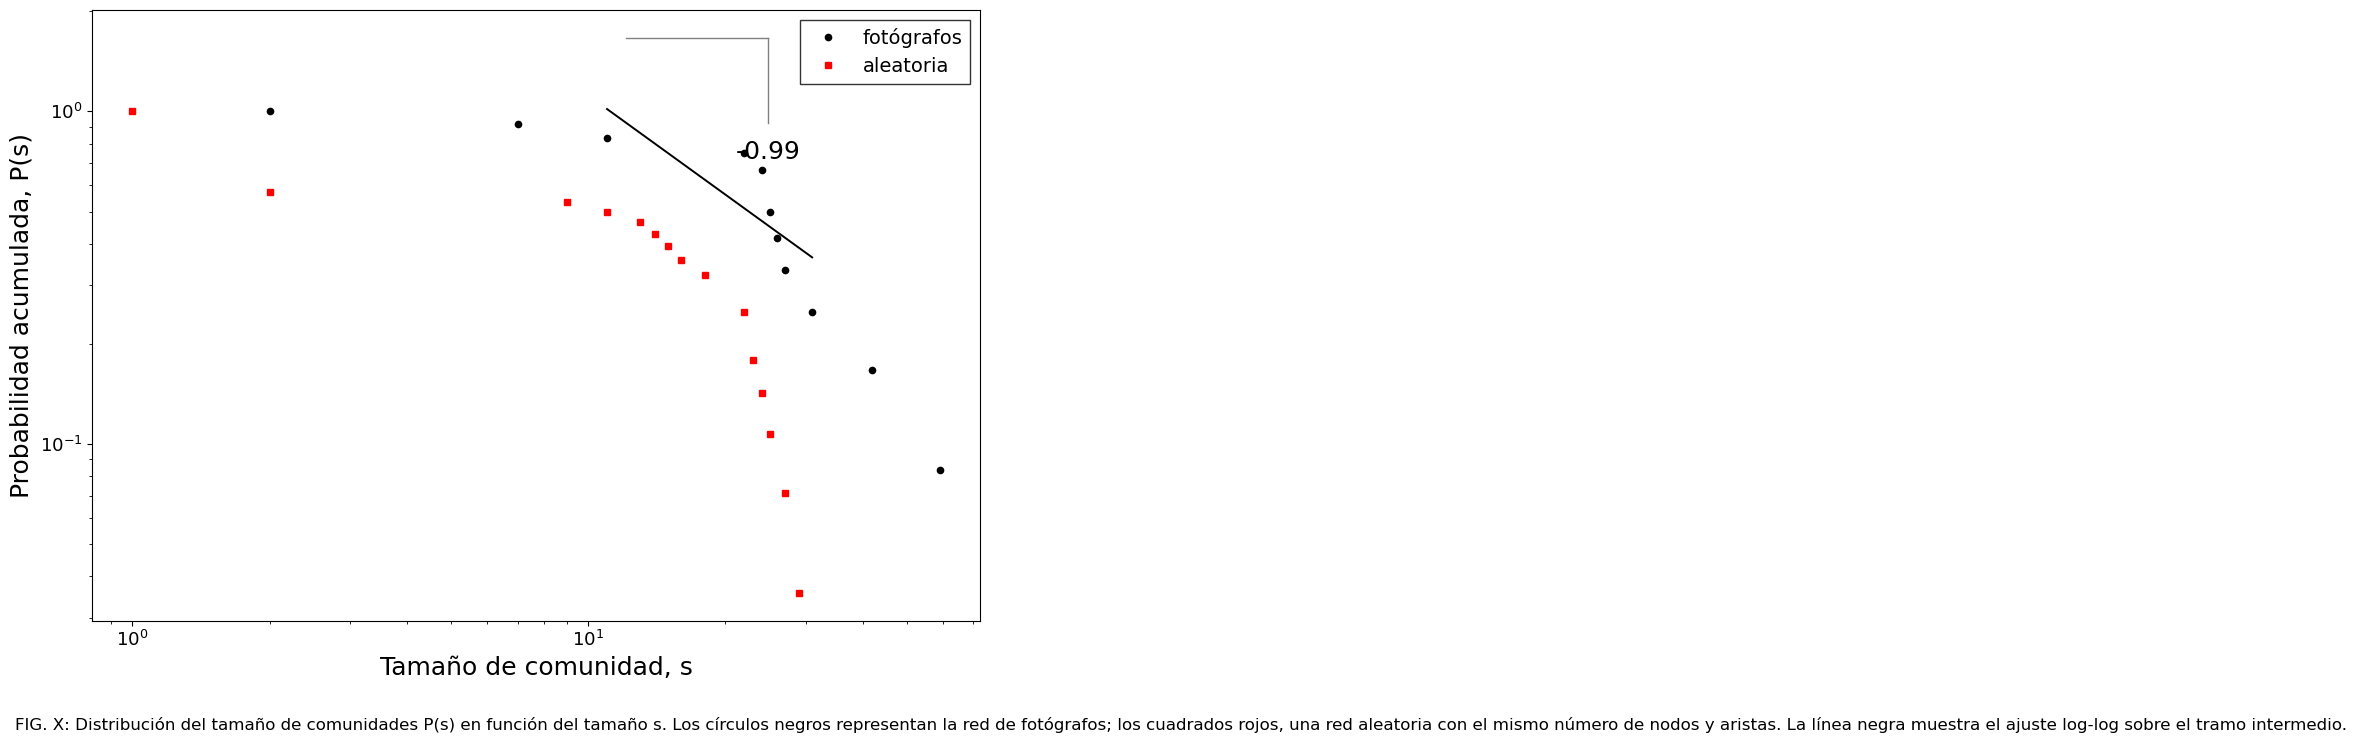

Nodos: 300
Aristas: 480
Comunidades reales: 12
Comunidades aleatorias: 28
Pendiente estimada: -0.9910
Figura guardada en: distribucion_tamano_comunidades_ajuste.png


In [18]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'distribucion_tamano_comunidades_ajuste.png'
SEED = 42

# --------------------------------------------------
# 1. Leer CSV y construir red
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

G = Gd.to_undirected()

# --------------------------------------------------
# 2. Detectar comunidades
# --------------------------------------------------
comunidades = nx.community.louvain_communities(G, seed=SEED)
sizes_real = sorted([len(c) for c in comunidades])

# --------------------------------------------------
# 3. Red aleatoria comparable
# --------------------------------------------------
n = G.number_of_nodes()
m = G.number_of_edges()

G_rand = nx.gnm_random_graph(n, m, seed=SEED)
comunidades_rand = nx.community.louvain_communities(G_rand, seed=SEED)
sizes_rand = sorted([len(c) for c in comunidades_rand])

# --------------------------------------------------
# 4. Distribución acumulada P(S >= s)
# --------------------------------------------------
def cumulative_size_distribution(sizes):
    sizes = np.array(sorted(sizes))
    unique_sizes = np.unique(sizes)

    x = []
    y = []

    total = len(sizes)
    for s in unique_sizes:
        prob = np.sum(sizes >= s) / total
        x.append(s)
        y.append(prob)

    return np.array(x, dtype=float), np.array(y, dtype=float)

x_real, y_real = cumulative_size_distribution(sizes_real)
x_rand, y_rand = cumulative_size_distribution(sizes_rand)

# --------------------------------------------------
# 5. Ajuste log-log en tramo intermedio
# --------------------------------------------------
# Ajusta este rango si quieres mover el fit
mask_fit = (x_real >= np.percentile(x_real, 20)) & (x_real <= np.percentile(x_real, 80))

x_fit = x_real[mask_fit]
y_fit = y_real[mask_fit]

logx = np.log10(x_fit)
logy = np.log10(y_fit)

slope, intercept = np.polyfit(logx, logy, 1)

x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
y_line = 10 ** (intercept + slope * np.log10(x_line))

# --------------------------------------------------
# 6. Gráfica
# --------------------------------------------------
plt.figure(figsize=(10, 7))

plt.loglog(
    x_real, y_real,
    'o',
    color='black',
    markersize=4.5,
    label='fotógrafos'
)

plt.loglog(
    x_rand, y_rand,
    's',
    color='red',
    markersize=4,
    label='aleatoria'
)

plt.loglog(
    x_line, y_line,
    '-',
    color='black',
    linewidth=1.4
)

# Texto de pendiente
x_text = x_line[len(x_line) // 2]
y_text = y_line[len(y_line) // 2] * 1.35

plt.text(
    x_text,
    y_text,
    f'{slope:.2f}',
    fontsize=18,
    color='black'
)

# Pequeña guía visual tipo bracket
x0 = x_fit.min() * 1.1
x1 = x_fit.max() * 0.8
y0 = 10 ** (intercept + slope * np.log10(x0))
y1 = y0 * 1.8

plt.plot([x0, x1], [y1, y1], color='gray', linewidth=1)
plt.plot([x1, x1], [y0, y1], color='gray', linewidth=1)

plt.xlabel('Tamaño de comunidad, s', fontsize=18)
plt.ylabel('Probabilidad acumulada, P(s)', fontsize=18)
plt.legend(fontsize=14, frameon=True, fancybox=False, edgecolor='black')
plt.tick_params(axis='both', which='major', labelsize=13)
plt.tight_layout()

plt.figtext(
    0.02, -0.05,
    (
        'FIG. X: Distribución del tamaño de comunidades P(s) en función del tamaño s. '
        'Los círculos negros representan la red de fotógrafos; los cuadrados rojos, '
        'una red aleatoria con el mismo número de nodos y aristas. '
        'La línea negra muestra el ajuste log-log sobre el tramo intermedio.'
    ),
    ha='left',
    fontsize=12
)

plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 7. Resumen
# --------------------------------------------------
print(f'Nodos: {n}')
print(f'Aristas: {m}')
print(f'Comunidades reales: {len(sizes_real)}')
print(f'Comunidades aleatorias: {len(sizes_rand)}')
print(f'Pendiente estimada: {slope:.4f}')
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

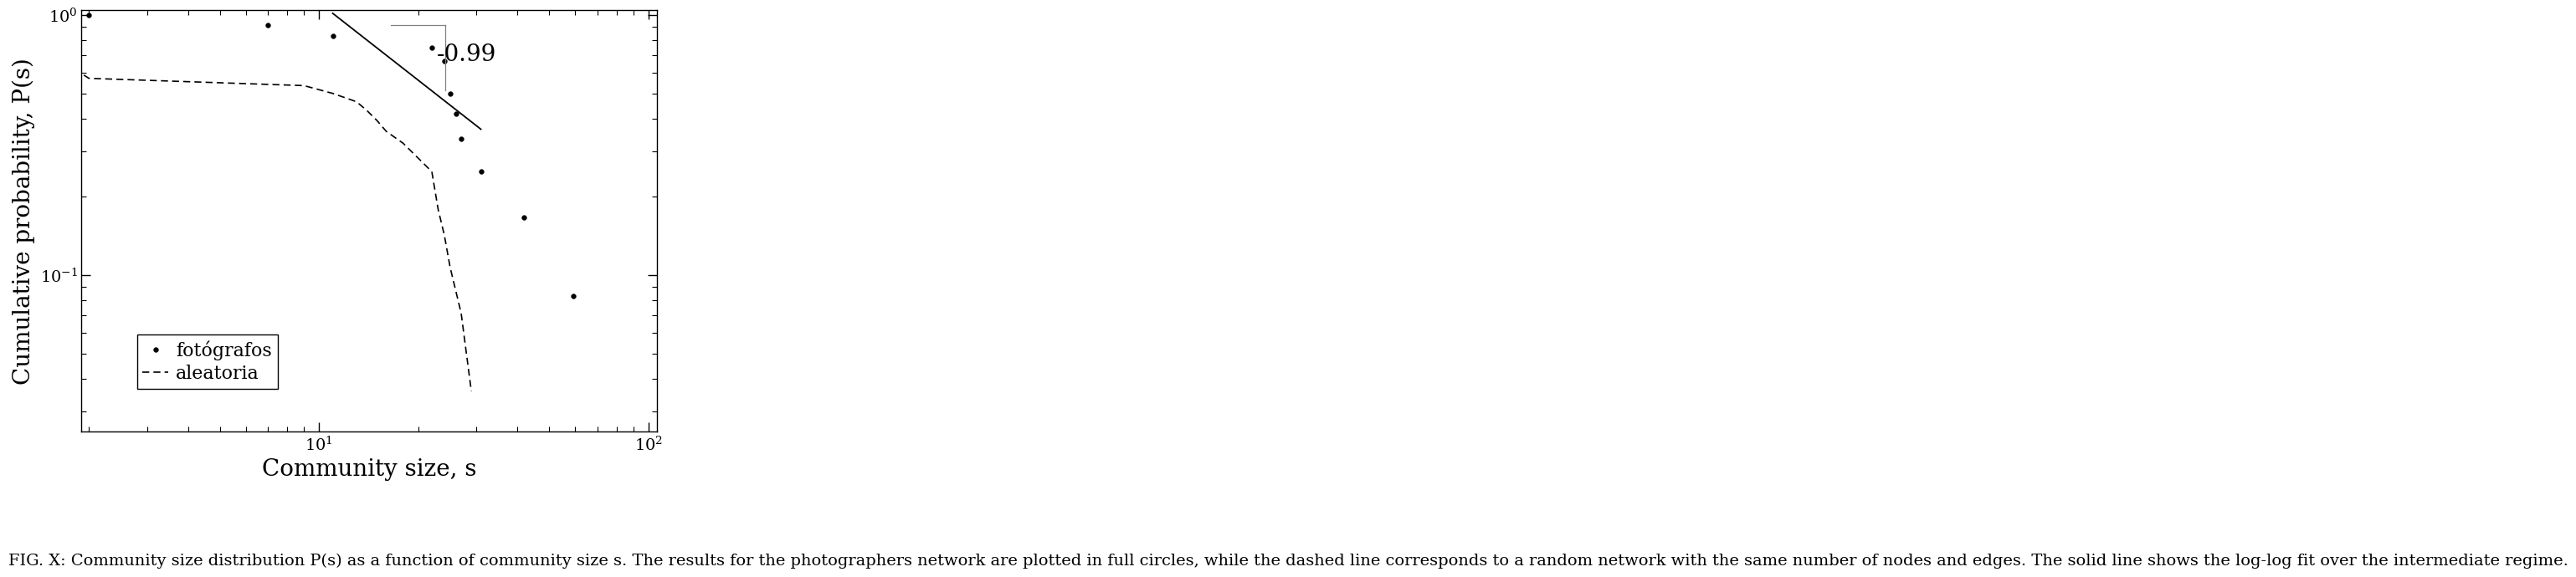

Nodos: 300
Aristas: 480
Comunidades reales: 12
Comunidades aleatorias: 28
Pendiente estimada: -0.9910
Figura guardada en: distribucion_tamano_comunidades_estilo_paper.png


In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'distribucion_tamano_comunidades_estilo_paper.png'
SEED = 42

# --------------------------------------------------
# 0. Estilo general tipo paper
# --------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.size': 14,
    'axes.labelsize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16
})

# --------------------------------------------------
# 1. Leer CSV y construir red
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

G = Gd.to_undirected()

# --------------------------------------------------
# 2. Detectar comunidades
# --------------------------------------------------
comunidades = nx.community.louvain_communities(G, seed=SEED)
sizes_real = sorted([len(c) for c in comunidades])

# --------------------------------------------------
# 3. Red aleatoria comparable
# --------------------------------------------------
n = G.number_of_nodes()
m = G.number_of_edges()

G_rand = nx.gnm_random_graph(n, m, seed=SEED)
comunidades_rand = nx.community.louvain_communities(G_rand, seed=SEED)
sizes_rand = sorted([len(c) for c in comunidades_rand])

# --------------------------------------------------
# 4. Distribución acumulada P(S >= s)
# --------------------------------------------------
def cumulative_size_distribution(sizes):
    sizes = np.array(sorted(sizes))
    unique_sizes = np.unique(sizes)

    x = []
    y = []
    total = len(sizes)

    for s in unique_sizes:
        prob = np.sum(sizes >= s) / total
        x.append(s)
        y.append(prob)

    return np.array(x, dtype=float), np.array(y, dtype=float)

x_real, y_real = cumulative_size_distribution(sizes_real)
x_rand, y_rand = cumulative_size_distribution(sizes_rand)

# --------------------------------------------------
# 5. Ajuste log-log en tramo intermedio
# --------------------------------------------------
mask_fit = (x_real >= np.percentile(x_real, 20)) & (x_real <= np.percentile(x_real, 80))
x_fit = x_real[mask_fit]
y_fit = y_real[mask_fit]

logx = np.log10(x_fit)
logy = np.log10(y_fit)

slope, intercept = np.polyfit(logx, logy, 1)

x_line = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 200)
y_line = 10 ** (intercept + slope * np.log10(x_line))

# --------------------------------------------------
# 6. Figura
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 6.6))

# Serie real
ax.loglog(
    x_real, y_real,
    'o',
    color='black',
    markersize=4.2,
    markeredgewidth=0.3,
    label='fotógrafos'
)

# Serie aleatoria
ax.loglog(
    x_rand, y_rand,
    linestyle=(0, (5, 3)),
    color='black',
    linewidth=1.2,
    label='aleatoria'
)

# Recta de ajuste
ax.loglog(
    x_line, y_line,
    '-',
    color='black',
    linewidth=1.3
)

# --------------------------------------------------
# 7. Ejes y ticks como paper
# --------------------------------------------------
ax.set_xlabel('Community size, s')
ax.set_ylabel('Cumulative probability, P(s)')

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1,
    top=True,
    right=True
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=0.8,
    top=True,
    right=True
)

ax.xaxis.set_major_locator(LogLocator(base=10.0))
ax.yaxis.set_major_locator(LogLocator(base=10.0))
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

# --------------------------------------------------
# 8. Leyenda blanca con borde negro
# --------------------------------------------------
leg = ax.legend(
    loc='lower left',
    bbox_to_anchor=(0.08, 0.08),
    frameon=True,
    fancybox=False,
    edgecolor='black',
    facecolor='white',
    framealpha=1,
    borderpad=0.3,
    labelspacing=0.25,
    handlelength=1.4,
    handletextpad=0.4
)

# --------------------------------------------------
# 9. Anotación de la pendiente
# --------------------------------------------------
x_text = x_line[int(len(x_line) * 0.70)]
y_text = y_line[int(len(y_line) * 0.70)] * 1.35

ax.text(
    x_text,
    y_text,
    f'{slope:.2f}',
    fontsize=20,
    color='black'
)

# bracket visual
x0 = x_fit.min() * 1.5
x1 = x_fit.max() * 0.78
y_top = 10 ** (intercept + slope * np.log10(x0)) * 1.35
y_bottom = 10 ** (intercept + slope * np.log10(x1)) * 1.10

ax.plot([x0, x1], [y_top, y_top], color='0.5', linewidth=0.9)
ax.plot([x1, x1], [y_bottom, y_top], color='0.5', linewidth=0.9)

# límites visuales más parecidos
ax.set_xlim(left=max(1, x_real.min() * 0.95), right=x_real.max() * 1.8)
ax.set_ylim(bottom=min(y_real.min(), y_rand.min()) * 0.7, top=1.05)

# --------------------------------------------------
# 10. Pie de figura estilo artículo
# --------------------------------------------------
fig.text(
    0.02, -0.02,
    (
        'FIG. X: Community size distribution P(s) as a function of community size s. '
        'The results for the photographers network are plotted in full circles, while '
        'the dashed line corresponds to a random network with the same number of nodes '
        'and edges. The solid line shows the log-log fit over the intermediate regime.'
    ),
    ha='left',
    va='top',
    fontsize=14
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 11. Resumen
# --------------------------------------------------
print(f'Nodos: {n}')
print(f'Aristas: {m}')
print(f'Comunidades reales: {len(sizes_real)}')
print(f'Comunidades aleatorias: {len(sizes_rand)}')
print(f'Pendiente estimada: {slope:.4f}')
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

## Otros

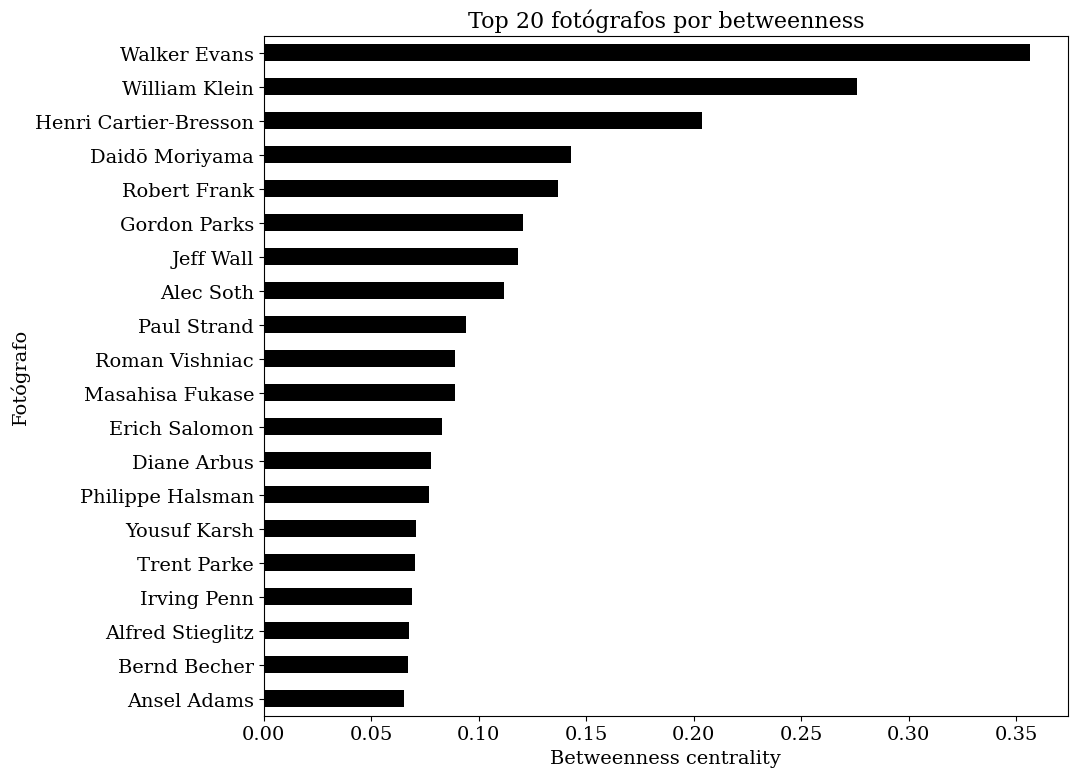

Ansel Adams              0.065424
Bernd Becher             0.067059
Alfred Stieglitz         0.067603
Irving Penn              0.069060
Trent Parke              0.070113
Yousuf Karsh             0.070616
Philippe Halsman         0.076766
Diane Arbus              0.077782
Erich Salomon            0.082871
Masahisa Fukase          0.088893
Roman Vishniac           0.088932
Paul Strand              0.094092
Alec Soth                0.111667
Jeff Wall                0.118079
Gordon Parks             0.120457
Robert Frank             0.136906
Daidō Moriyama           0.143072
Henri Cartier-Bresson    0.204037
William Klein            0.275749
Walker Evans             0.356232
Name: betweenness, dtype: float64
Figura guardada en: top_betweenness_fotografos.png


In [20]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'top_betweenness_fotografos.png'
TOP_N = 20

# --------------------------------------------------
# 1. Leer CSV y construir red
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Influenciador', 'Influenciado']:
    df[col] = df[col].astype(str).str.strip()

Gd = nx.DiGraph()
for _, row in df.iterrows():
    Gd.add_edge(row['Influenciador'], row['Influenciado'])

G = Gd.to_undirected()

# --------------------------------------------------
# 2. Betweenness centrality
# --------------------------------------------------
bc = nx.betweenness_centrality(G, normalized=True)

top_bc = (
    pd.Series(bc, name='betweenness')
    .sort_values(ascending=False)
    .head(TOP_N)
    .sort_values(ascending=True)
)

# --------------------------------------------------
# 3. Gráfica
# --------------------------------------------------
plt.figure(figsize=(11, 8))
top_bc.plot(kind='barh', color='black')

plt.xlabel('Betweenness centrality', fontsize=14)
plt.ylabel('Fotógrafo', fontsize=14)
plt.title(f'Top {TOP_N} fotógrafos por betweenness', fontsize=16)
plt.tight_layout()
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

print(top_bc)
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

### Flujos entre movimientos

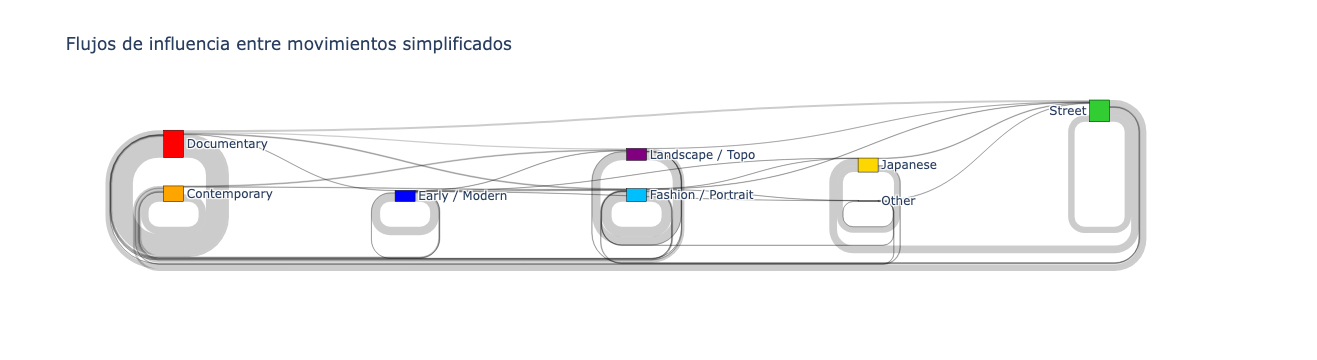

          Grupo_Origen       Grupo_Destino  valor
4          Documentary         Documentary    101
18  Fashion / Portrait  Fashion / Portrait     47
11      Early / Modern      Early / Modern     41
29    Landscape / Topo    Landscape / Topo     40
38              Street            Japanese     37
0         Contemporary        Contemporary     35
40              Street              Street     31
23            Japanese            Japanese     28
36              Street         Documentary     21
25    Landscape / Topo        Contemporary     12
35              Street        Contemporary     10
3          Documentary        Contemporary      9
8          Documentary              Street      9
7          Documentary    Landscape / Topo      6
2         Contemporary    Landscape / Topo      4
10      Early / Modern         Documentary      4
6          Documentary  Fashion / Portrait      4
16  Fashion / Portrait        Contemporary      4
22            Japanese        Contemporary      3


In [21]:
import pandas as pd
import plotly.graph_objects as go

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_HTML = 'flujos_movimientos_sankey.html'

# --------------------------------------------------
# 1. Leer CSV
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# --------------------------------------------------
# 2. Simplificar movimientos
# --------------------------------------------------
def simplificar_movimiento(m):
    m = str(m).strip()

    if m in ['Pioneers', 'Pictorialism', 'Straight Photography', 'Modernist Photography', 'Photography Education']:
        return 'Early / Modern'

    elif m in ['Documentary Photography', 'Social Documentary', 'FSA/Documentary', 'Documentary Portrait',
               'Documentary/Street', 'Photojournalism', 'Poetic Documentary', 'War Photography',
               'Humanist Photography', 'Magnum Photos']:
        return 'Documentary'

    elif m in ['Street Photography', 'Provoke Movement', 'Japanese Street Photography']:
        return 'Street'

    elif m in ['Japanese Photography', 'Contemporary Japanese', 'Japanese Contemporary']:
        return 'Japanese'

    elif m in ['Conceptual Photography', 'Conceptual Art', 'Postmodern Photography',
               'Post-Internet Photography', 'Staged Photography', 'Fine Art Photography',
               'Contemporary Art', 'Contemporary Photography', 'Contemporary/Digital',
               'Contemporary Documentary', 'Contemporary Portrait', 'Contemporary Landscape',
               'Contemporary Public Art']:
        return 'Contemporary'

    elif m in ['New Topographics', 'Düsseldorf School', 'Color Photography', 'Landscape Photography',
               'Group f/64']:
        return 'Landscape / Topo'

    elif m in ['Fashion Photography', 'Fashion/Portrait Photography', 'Portrait Photography', 'Art Direction']:
        return 'Fashion / Portrait'

    else:
        return 'Other'

df['Grupo_Origen'] = df['Movimiento_Influenciador'].apply(simplificar_movimiento)
df['Grupo_Destino'] = df['Movimiento_Influenciado'].apply(simplificar_movimiento)

# --------------------------------------------------
# 3. Contar flujos
# --------------------------------------------------
flows = (
    df.groupby(['Grupo_Origen', 'Grupo_Destino'])
      .size()
      .reset_index(name='valor')
)

flows = flows[flows['valor'] > 0].copy()

# --------------------------------------------------
# 4. Preparar nodos
# --------------------------------------------------
labels = sorted(set(flows['Grupo_Origen']).union(set(flows['Grupo_Destino'])))
label_to_idx = {label: i for i, label in enumerate(labels)}

source = flows['Grupo_Origen'].map(label_to_idx).tolist()
target = flows['Grupo_Destino'].map(label_to_idx).tolist()
value = flows['valor'].tolist()

# Colores de nodos
node_colors_map = {
    'Early / Modern': 'blue',
    'Documentary': 'red',
    'Street': 'limegreen',
    'Japanese': 'gold',
    'Contemporary': 'orange',
    'Landscape / Topo': 'purple',
    'Fashion / Portrait': 'deepskyblue',
    'Other': 'lightgray'
}

node_colors = [node_colors_map.get(label, 'lightgray') for label in labels]

# --------------------------------------------------
# 5. Sankey
# --------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=labels,
        color=node_colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title_text='Flujos de influencia entre movimientos simplificados',
    font_size=12
)

fig.write_html(ARCHIVO_HTML)
fig.show()

print(flows.sort_values('valor', ascending=False).head(20))
print(f'Sankey guardado en: {ARCHIVO_HTML}')

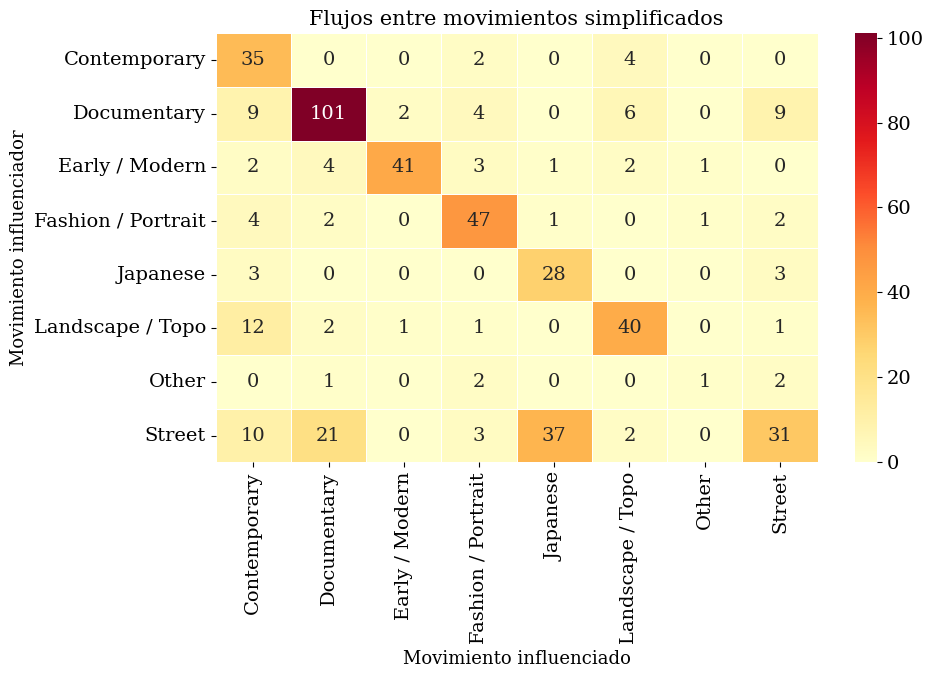

Grupo_Destino       Contemporary  Documentary  Early / Modern  \
Grupo_Origen                                                    
Contemporary                  35            0               0   
Documentary                    9          101               2   
Early / Modern                 2            4              41   
Fashion / Portrait             4            2               0   
Japanese                       3            0               0   
Landscape / Topo              12            2               1   
Other                          0            1               0   
Street                        10           21               0   

Grupo_Destino       Fashion / Portrait  Japanese  Landscape / Topo  Other  \
Grupo_Origen                                                                
Contemporary                         2         0                 4      0   
Documentary                          4         0                 6      0   
Early / Modern                       3   

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'matriz_flujos_movimientos.png'

df = pd.read_csv(ARCHIVO_CSV)

for col in ['Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

def simplificar_movimiento(m):
    m = str(m).strip()

    if m in ['Pioneers', 'Pictorialism', 'Straight Photography', 'Modernist Photography', 'Photography Education']:
        return 'Early / Modern'
    elif m in ['Documentary Photography', 'Social Documentary', 'FSA/Documentary', 'Documentary Portrait',
               'Documentary/Street', 'Photojournalism', 'Poetic Documentary', 'War Photography',
               'Humanist Photography', 'Magnum Photos']:
        return 'Documentary'
    elif m in ['Street Photography', 'Provoke Movement', 'Japanese Street Photography']:
        return 'Street'
    elif m in ['Japanese Photography', 'Contemporary Japanese', 'Japanese Contemporary']:
        return 'Japanese'
    elif m in ['Conceptual Photography', 'Conceptual Art', 'Postmodern Photography',
               'Post-Internet Photography', 'Staged Photography', 'Fine Art Photography',
               'Contemporary Art', 'Contemporary Photography', 'Contemporary/Digital',
               'Contemporary Documentary', 'Contemporary Portrait', 'Contemporary Landscape',
               'Contemporary Public Art']:
        return 'Contemporary'
    elif m in ['New Topographics', 'Düsseldorf School', 'Color Photography', 'Landscape Photography',
               'Group f/64']:
        return 'Landscape / Topo'
    elif m in ['Fashion Photography', 'Fashion/Portrait Photography', 'Portrait Photography', 'Art Direction']:
        return 'Fashion / Portrait'
    else:
        return 'Other'

df['Grupo_Origen'] = df['Movimiento_Influenciador'].apply(simplificar_movimiento)
df['Grupo_Destino'] = df['Movimiento_Influenciado'].apply(simplificar_movimiento)

matriz = pd.crosstab(df['Grupo_Origen'], df['Grupo_Destino'])

plt.figure(figsize=(10, 7))
sns.heatmap(matriz, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)

plt.xlabel('Movimiento influenciado', fontsize=13)
plt.ylabel('Movimiento influenciador', fontsize=13)
plt.title('Flujos entre movimientos simplificados', fontsize=15)
plt.tight_layout()
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

print(matriz)
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

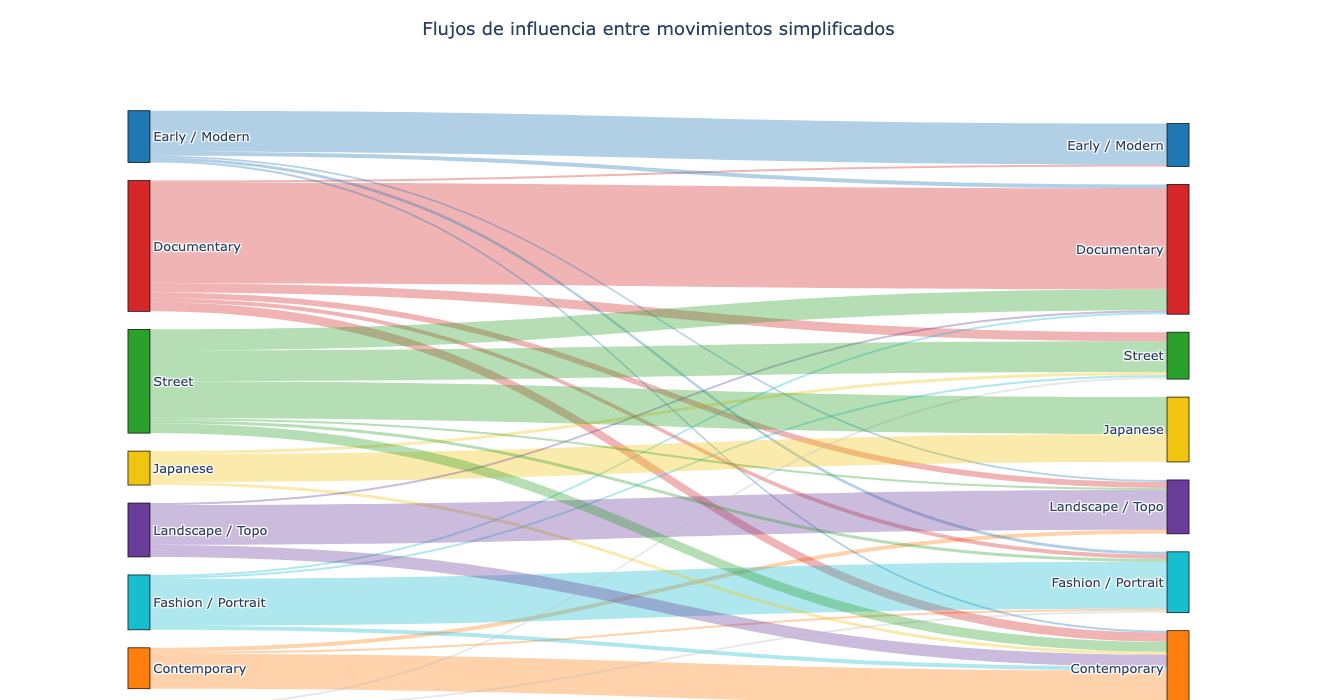

          Grupo_Origen       Grupo_Destino  valor
4          Documentary         Documentary    101
18  Fashion / Portrait  Fashion / Portrait     47
11      Early / Modern      Early / Modern     41
29    Landscape / Topo    Landscape / Topo     40
38              Street            Japanese     37
0         Contemporary        Contemporary     35
40              Street              Street     31
23            Japanese            Japanese     28
36              Street         Documentary     21
25    Landscape / Topo        Contemporary     12
35              Street        Contemporary     10
8          Documentary              Street      9
3          Documentary        Contemporary      9
7          Documentary    Landscape / Topo      6
2         Contemporary    Landscape / Topo      4
6          Documentary  Fashion / Portrait      4
16  Fashion / Portrait        Contemporary      4
10      Early / Modern         Documentary      4
22            Japanese        Contemporary      3


In [23]:
import pandas as pd
import plotly.graph_objects as go

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_HTML = 'flujos_movimientos_sankey_mejorado.html'
UMBRAL_MINIMO = 2  # oculta flujos con menos de este número de relaciones

# --------------------------------------------------
# 1. Leer CSV
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# --------------------------------------------------
# 2. Simplificar movimientos
# --------------------------------------------------
def simplificar_movimiento(m):
    m = str(m).strip()

    if m in ['Pioneers', 'Pictorialism', 'Straight Photography', 'Modernist Photography', 'Photography Education']:
        return 'Early / Modern'
    elif m in ['Documentary Photography', 'Social Documentary', 'FSA/Documentary', 'Documentary Portrait',
               'Documentary/Street', 'Photojournalism', 'Poetic Documentary', 'War Photography',
               'Humanist Photography', 'Magnum Photos']:
        return 'Documentary'
    elif m in ['Street Photography', 'Provoke Movement', 'Japanese Street Photography']:
        return 'Street'
    elif m in ['Japanese Photography', 'Contemporary Japanese', 'Japanese Contemporary']:
        return 'Japanese'
    elif m in ['Conceptual Photography', 'Conceptual Art', 'Postmodern Photography',
               'Post-Internet Photography', 'Staged Photography', 'Fine Art Photography',
               'Contemporary Art', 'Contemporary Photography', 'Contemporary/Digital',
               'Contemporary Documentary', 'Contemporary Portrait', 'Contemporary Landscape',
               'Contemporary Public Art']:
        return 'Contemporary'
    elif m in ['New Topographics', 'Düsseldorf School', 'Color Photography', 'Landscape Photography', 'Group f/64']:
        return 'Landscape / Topo'
    elif m in ['Fashion Photography', 'Fashion/Portrait Photography', 'Portrait Photography', 'Art Direction']:
        return 'Fashion / Portrait'
    else:
        return 'Other'

df['Grupo_Origen'] = df['Movimiento_Influenciador'].apply(simplificar_movimiento)
df['Grupo_Destino'] = df['Movimiento_Influenciado'].apply(simplificar_movimiento)

# --------------------------------------------------
# 3. Contar flujos
# --------------------------------------------------
flows = (
    df.groupby(['Grupo_Origen', 'Grupo_Destino'])
      .size()
      .reset_index(name='valor')
)

flows = flows[flows['valor'] >= UMBRAL_MINIMO].copy()

# --------------------------------------------------
# 4. Orden narrativo de categorías
# --------------------------------------------------
orden = [
    'Early / Modern',
    'Documentary',
    'Street',
    'Japanese',
    'Landscape / Topo',
    'Fashion / Portrait',
    'Contemporary',
    'Other'
]

# nodos duplicados para separar columna izquierda y derecha
labels_left = [f'{x} ' for x in orden if x in set(flows['Grupo_Origen'])]
labels_right = [f' {x}' for x in orden if x in set(flows['Grupo_Destino'])]

labels = labels_left + labels_right

left_map = {cat: i for i, cat in enumerate([x.strip() for x in labels_left])}
right_map = {cat: i + len(labels_left) for i, cat in enumerate([x.strip() for x in labels_right])}

source = flows['Grupo_Origen'].map(left_map).tolist()
target = flows['Grupo_Destino'].map(right_map).tolist()
value = flows['valor'].tolist()

# --------------------------------------------------
# 5. Colores
# --------------------------------------------------
node_colors_map = {
    'Early / Modern': '#1f77b4',
    'Documentary': '#d62728',
    'Street': '#2ca02c',
    'Japanese': '#f1c40f',
    'Landscape / Topo': '#6a3d9a',
    'Fashion / Portrait': '#17becf',
    'Contemporary': '#ff7f0e',
    'Other': '#bdbdbd'
}

def hex_to_rgba(hex_color, alpha=0.35):
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

node_colors = []
for label in labels:
    cat = label.strip()
    node_colors.append(node_colors_map.get(cat, '#bdbdbd'))

link_colors = [
    hex_to_rgba(node_colors_map.get(origen, '#bdbdbd'), alpha=0.35)
    for origen in flows['Grupo_Origen']
]

# --------------------------------------------------
# 6. Posiciones manuales
# --------------------------------------------------
n_left = len(labels_left)
n_right = len(labels_right)

x = [0.08] * n_left + [0.92] * n_right
y_left = [(i + 1) / (n_left + 1) for i in range(n_left)]
y_right = [(i + 1) / (n_right + 1) for i in range(n_right)]
y = y_left + y_right

# --------------------------------------------------
# 7. Hover personalizado
# --------------------------------------------------
link_customdata = [
    f'{o} → {d}<br>Relaciones: {v}'
    for o, d, v in zip(flows['Grupo_Origen'], flows['Grupo_Destino'], flows['valor'])
]

# --------------------------------------------------
# 8. Sankey
# --------------------------------------------------
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    valueformat='.0f',
    node=dict(
        pad=18,
        thickness=22,
        line=dict(color='black', width=0.7),
        label=labels,
        color=node_colors,
        x=x,
        y=y,
        hovertemplate='Movimiento: %{label}<extra></extra>'
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors,
        customdata=link_customdata,
        hovertemplate='%{customdata}<extra></extra>'
    )
)])

fig.update_layout(
    title=dict(
        text='Flujos de influencia entre movimientos simplificados',
        x=0.5,
        xanchor='center'
    ),
    font=dict(size=13),
    width=1100,
    height=700,
    margin=dict(l=40, r=40, t=70, b=30),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.write_html(ARCHIVO_HTML)
fig.show()

print(flows.sort_values('valor', ascending=False).head(20))
print(f'Sankey guardado en: {ARCHIVO_HTML}')

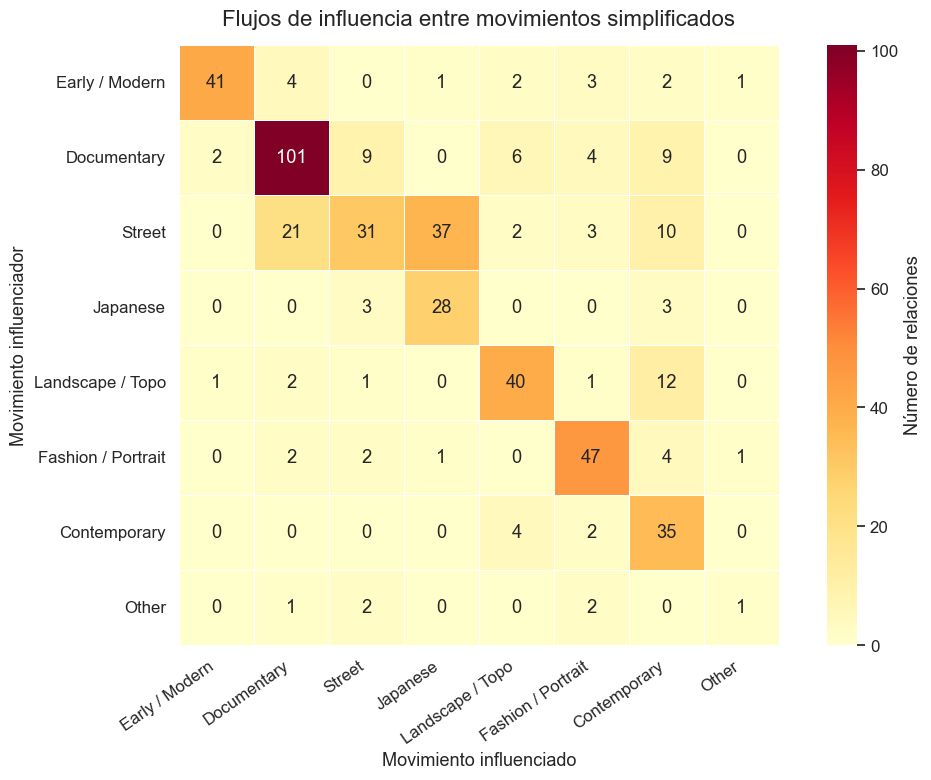

Grupo_Destino       Early / Modern  Documentary  Street  Japanese  \
Grupo_Origen                                                        
Early / Modern                  41            4       0         1   
Documentary                      2          101       9         0   
Street                           0           21      31        37   
Japanese                         0            0       3        28   
Landscape / Topo                 1            2       1         0   
Fashion / Portrait               0            2       2         1   
Contemporary                     0            0       0         0   
Other                            0            1       2         0   

Grupo_Destino       Landscape / Topo  Fashion / Portrait  Contemporary  Other  
Grupo_Origen                                                                   
Early / Modern                     2                   3             2      1  
Documentary                        6                   4             

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'matriz_flujos_movimientos.png'

# --------------------------------------------------
# 1. Leer CSV
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# --------------------------------------------------
# 2. Simplificar movimientos
# --------------------------------------------------
def simplificar_movimiento(m):
    m = str(m).strip()

    if m in ['Pioneers', 'Pictorialism', 'Straight Photography', 'Modernist Photography', 'Photography Education']:
        return 'Early / Modern'
    elif m in ['Documentary Photography', 'Social Documentary', 'FSA/Documentary', 'Documentary Portrait',
               'Documentary/Street', 'Photojournalism', 'Poetic Documentary', 'War Photography',
               'Humanist Photography', 'Magnum Photos']:
        return 'Documentary'
    elif m in ['Street Photography', 'Provoke Movement', 'Japanese Street Photography']:
        return 'Street'
    elif m in ['Japanese Photography', 'Contemporary Japanese', 'Japanese Contemporary']:
        return 'Japanese'
    elif m in ['Conceptual Photography', 'Conceptual Art', 'Postmodern Photography',
               'Post-Internet Photography', 'Staged Photography', 'Fine Art Photography',
               'Contemporary Art', 'Contemporary Photography', 'Contemporary/Digital',
               'Contemporary Documentary', 'Contemporary Portrait', 'Contemporary Landscape',
               'Contemporary Public Art']:
        return 'Contemporary'
    elif m in ['New Topographics', 'Düsseldorf School', 'Color Photography', 'Landscape Photography',
               'Group f/64']:
        return 'Landscape / Topo'
    elif m in ['Fashion Photography', 'Fashion/Portrait Photography', 'Portrait Photography', 'Art Direction']:
        return 'Fashion / Portrait'
    else:
        return 'Other'

df['Grupo_Origen'] = df['Movimiento_Influenciador'].apply(simplificar_movimiento)
df['Grupo_Destino'] = df['Movimiento_Influenciado'].apply(simplificar_movimiento)

# --------------------------------------------------
# 3. Orden narrativo
# --------------------------------------------------
orden = [
    'Early / Modern',
    'Documentary',
    'Street',
    'Japanese',
    'Landscape / Topo',
    'Fashion / Portrait',
    'Contemporary',
    'Other'
]

# --------------------------------------------------
# 4. Matriz de flujos
# --------------------------------------------------
matriz = pd.crosstab(df['Grupo_Origen'], df['Grupo_Destino'])

# Reindexar para mantener siempre el mismo orden
matriz = matriz.reindex(index=orden, columns=orden, fill_value=0)

# Opcional: eliminar filas/columnas totalmente vacías
matriz = matriz.loc[(matriz.sum(axis=1) > 0), (matriz.sum(axis=0) > 0)]

# --------------------------------------------------
# 5. Estilo
# --------------------------------------------------
sns.set_theme(style='white', font_scale=1.1)

plt.figure(figsize=(11, 8))

ax = sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'Número de relaciones'},
    square=True
)

plt.title('Flujos de influencia entre movimientos simplificados', fontsize=16, pad=14)
plt.xlabel('Movimiento influenciado', fontsize=13)
plt.ylabel('Movimiento influenciador', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

print(matriz)
print(f'Figura guardada en: {ARCHIVO_SALIDA}')

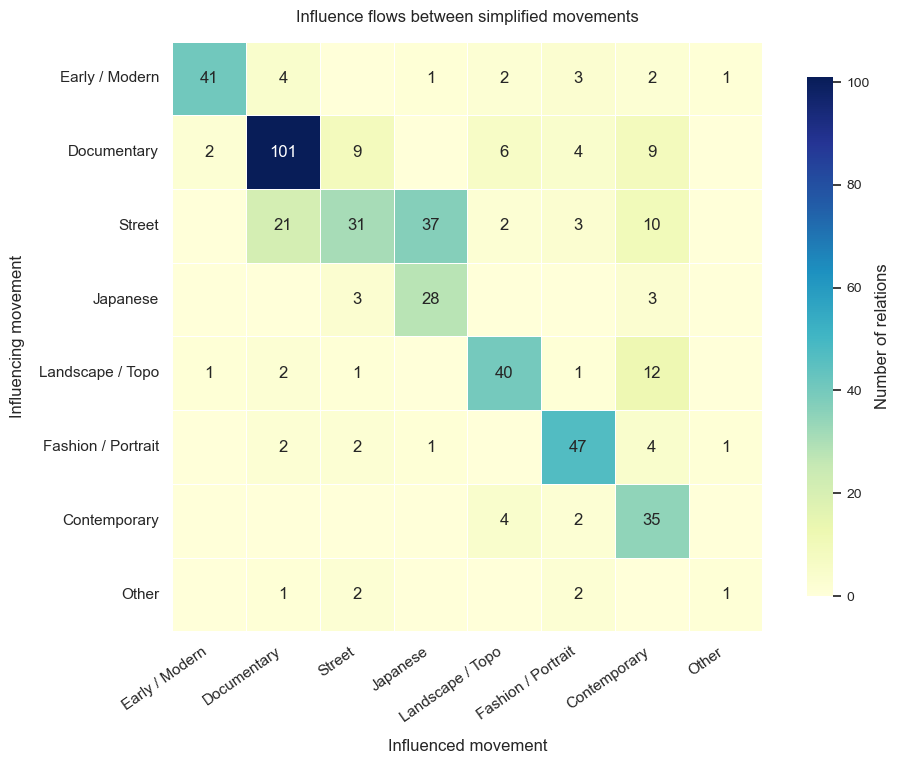

Grupo_Destino       Early / Modern  Documentary  Street  Japanese  \
Grupo_Origen                                                        
Early / Modern                  41            4       0         1   
Documentary                      2          101       9         0   
Street                           0           21      31        37   
Japanese                         0            0       3        28   
Landscape / Topo                 1            2       1         0   
Fashion / Portrait               0            2       2         1   
Contemporary                     0            0       0         0   
Other                            0            1       2         0   

Grupo_Destino       Landscape / Topo  Fashion / Portrait  Contemporary  Other  
Grupo_Origen                                                                   
Early / Modern                     2                   3             2      1  
Documentary                        6                   4             

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

ARCHIVO_CSV = 'red_fotografos_relaciones_final_con_fechas.csv'
ARCHIVO_SALIDA = 'matriz_flujos_movimientos_paper.png'

# --------------------------------------------------
# 1. Estilo general tipo paper
# --------------------------------------------------
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

sns.set_theme(style='white')

# --------------------------------------------------
# 2. Leer CSV
# --------------------------------------------------
df = pd.read_csv(ARCHIVO_CSV)

for col in ['Movimiento_Influenciador', 'Movimiento_Influenciado']:
    df[col] = df[col].astype(str).str.strip()

# --------------------------------------------------
# 3. Simplificar movimientos
# --------------------------------------------------
def simplificar_movimiento(m):
    m = str(m).strip()

    if m in ['Pioneers', 'Pictorialism', 'Straight Photography', 'Modernist Photography', 'Photography Education']:
        return 'Early / Modern'
    elif m in ['Documentary Photography', 'Social Documentary', 'FSA/Documentary', 'Documentary Portrait',
               'Documentary/Street', 'Photojournalism', 'Poetic Documentary', 'War Photography',
               'Humanist Photography', 'Magnum Photos']:
        return 'Documentary'
    elif m in ['Street Photography', 'Provoke Movement', 'Japanese Street Photography']:
        return 'Street'
    elif m in ['Japanese Photography', 'Contemporary Japanese', 'Japanese Contemporary']:
        return 'Japanese'
    elif m in ['Conceptual Photography', 'Conceptual Art', 'Postmodern Photography',
               'Post-Internet Photography', 'Staged Photography', 'Fine Art Photography',
               'Contemporary Art', 'Contemporary Photography', 'Contemporary/Digital',
               'Contemporary Documentary', 'Contemporary Portrait', 'Contemporary Landscape',
               'Contemporary Public Art']:
        return 'Contemporary'
    elif m in ['New Topographics', 'Düsseldorf School', 'Color Photography', 'Landscape Photography',
               'Group f/64']:
        return 'Landscape / Topo'
    elif m in ['Fashion Photography', 'Fashion/Portrait Photography', 'Portrait Photography', 'Art Direction']:
        return 'Fashion / Portrait'
    else:
        return 'Other'

df['Grupo_Origen'] = df['Movimiento_Influenciador'].apply(simplificar_movimiento)
df['Grupo_Destino'] = df['Movimiento_Influenciado'].apply(simplificar_movimiento)

# --------------------------------------------------
# 4. Orden narrativo
# --------------------------------------------------
orden = [
    'Early / Modern',
    'Documentary',
    'Street',
    'Japanese',
    'Landscape / Topo',
    'Fashion / Portrait',
    'Contemporary',
    'Other'
]

# --------------------------------------------------
# 5. Matriz
# --------------------------------------------------
matriz = pd.crosstab(df['Grupo_Origen'], df['Grupo_Destino'])
matriz = matriz.reindex(index=orden, columns=orden, fill_value=0)
matriz = matriz.loc[(matriz.sum(axis=1) > 0), (matriz.sum(axis=0) > 0)]

# Anotaciones: ocultar ceros
annot = matriz.astype(str)
annot[matriz == 0] = ''

# --------------------------------------------------
# 6. Gráfica
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10.5, 7.8))

heatmap = sns.heatmap(
    matriz,
    annot=annot,
    fmt='',
    cmap='YlGnBu',
    linewidths=0.7,
    linecolor='white',
    square=True,
    cbar_kws={
        'label': 'Number of relations',
        'shrink': 0.88
    },
    ax=ax
)

ax.set_title('Influence flows between simplified movements', pad=14)
ax.set_xlabel('Influenced movement', labelpad=10)
ax.set_ylabel('Influencing movement', labelpad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Quitar marco superior/derecho si molesta visualmente
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajustar colorbar
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label('Number of relations', size=12)

plt.tight_layout()
plt.savefig(ARCHIVO_SALIDA, dpi=300, bbox_inches='tight')
plt.show()

print(matriz)
print(f'Figura guardada en: {ARCHIVO_SALIDA}')